# Notebook 01 — Exploración de Datos (EDA)

Proyecto: **Reconocimiento Acústico de Vehículos de Emergencia**.


## 00. Introducción y objetivos

Esta notebook describe cómo son las señales de AudioSet-EV v2, LSSiren, sireNNet y A3Siren-Recordings. No entrena modelos, no calcula métricas de clasificación, no aumenta datos y no elige un dataset principal.

Los CSV de las notebooks 00 y 00.1 no se leen. El inventario, las cabeceras, los hashes y las etiquetas se regeneran desde `/kaggle/input`. Los resultados quedan en `/kaggle/working/dataset_eda/`.


## 01. Configuración y reproducibilidad

Semilla 42. Los parámetros espectrales quedan fijos: FFT de 2048, salto de 512, ventana Hann, 64 bandas Mel, 13 MFCC, fmin 20 Hz, fmax igual al Nyquist de cada archivo y roll-off al 85 %. El estéreo se promedia solo en memoria.


In [1]:
# === CELL PY LIB ===
from __future__ import annotations

# Notebook 01. No lee CSV de las auditorías anteriores.
# No modifica /kaggle/input y no entrena modelos.

import ast
import hashlib
import json
import math
import os
import re
from collections import Counter
from datetime import datetime, timezone
from pathlib import Path

os.environ.setdefault("NUMBA_CACHE_DIR", "/tmp/numba-cache")
Path(os.environ["NUMBA_CACHE_DIR"]).mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import soundfile as sf

import librosa
import librosa.display
from scipy.signal import hilbert
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(iterable, **kwargs):
        return iterable

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)


SEED = 42
np.random.seed(SEED)

INPUT_ROOT = Path("/kaggle/input")
OUTPUT_ROOT = Path("/kaggle/working/dataset_eda")

N_FFT = 2048
HOP_LENGTH = 512
WIN_LENGTH = 2048
WINDOW = "hann"
N_MELS = 64
N_MFCC = 13
FMIN = 20.0
ROLLOFF_PERCENT = 0.85
CLIP_AMPLITUDE = 0.999
SILENCE_AMPLITUDE = 10 ** (-50 / 20)
CHUNK_SIZE = 100_000
HASH_CHUNK = 1024 * 1024
AUDIO_EXTENSIONS = {".wav", ".flac", ".mp3", ".ogg", ".m4a"}
RARE_SR_MAX_COUNT = 20

SAMPLE_TARGETS = {
    "audioset_positive": 200,
    "audioset_negative": 200,
    "lssiren_ambulance": 200,
    "lssiren_road": 200,
    "sirennet_per_class": 150,
}

DATASET_ORDER = ["audioset_ev", "lssiren", "sirennet", "a3siren"]
DISPLAY = {
    "audioset_ev": "AudioSet-EV v2",
    "lssiren": "LSSiren",
    "sirennet": "sireNNet",
    "a3siren": "A3Siren-Recordings",
}
CANONICAL = {
    "audioset_ev": Path("/kaggle/input/datasets/jeancdevx/audioset-ev"),
    "lssiren": Path("/kaggle/input/datasets/jeancdevx/lssiren/lssiren"),
    "sirennet": Path("/kaggle/input/datasets/jeancdevx/sirennet/sireNNet"),
    "a3siren": Path("/kaggle/input/datasets/jeancdevx/a3s-rec"),
}
SIREN_FOLDERS = ("ambulance", "firetruck", "police", "traffic")
POLARITY = ("Positive_files", "Negative_files")
LSSIREN_FOLDERS = ("Emergency Vehicle Sirens", "Road Noises")
FEATURE_COLUMNS = [
    "duration", "rms_mean", "zcr_mean", "dominant_frequency", "spectral_centroid_mean",
    "spectral_bandwidth_mean", "spectral_rolloff_mean", "spectral_flux_mean", "spectral_flatness_mean",
] + [f"mfcc_{i}_mean" for i in range(1, 14)]

STATE: dict = {}


def configure(input_root: Path | None = None, output_root: Path | None = None, sample_targets: dict | None = None) -> None:
    """Fija rutas de esta corrida. No consulta CSV de las notebooks 00 ni 00.1."""
    global INPUT_ROOT, OUTPUT_ROOT, SAMPLE_TARGETS
    INPUT_ROOT = Path("/kaggle/input") if input_root is None else Path(input_root)
    OUTPUT_ROOT = Path("/kaggle/working/dataset_eda") if output_root is None else Path(output_root)
    if sample_targets:
        SAMPLE_TARGETS = dict(sample_targets)
    for folder in ("tables", "plots", "plots/spectrograms", "plots/temporal_examples", "plots/thesis", "samples", "reports", "data"):
        (OUTPUT_ROOT / folder).mkdir(parents=True, exist_ok=True)
    STATE.clear()
    STATE["configured_at"] = datetime.now(timezone.utc).isoformat()
    versions = {
        "python": os.sys.version.replace("\n", " "),
        "platform": os.uname().sysname + " " + os.uname().release,
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "matplotlib": plt.matplotlib.__version__,
        "scipy": __import__("scipy").__version__,
        "librosa": librosa.__version__,
        "soundfile": sf.__version__,
        "sklearn": __import__("sklearn").__version__,
    }
    STATE["versions"] = versions
    STATE["seed"] = SEED
    print(f"timestamp_utc: {STATE['configured_at']}")
    print(f"seed: {SEED}")
    print(f"input: {INPUT_ROOT}")
    print(f"output: {OUTPUT_ROOT}")
    for name, version in versions.items():
        print(f"{name}: {version}")
    print("Parámetros espectrales fijos: n_fft=2048, hop_length=512, win_length=2048, window=hann, n_mels=64, n_mfcc=13, fmin=20 Hz, fmax=Nyquist de cada archivo, roll-off=85%.")
    print("Esta corrida no lee CSV de auditorías anteriores y no modifica /kaggle/input.")


def export_table(frame: pd.DataFrame, filename: str) -> Path:
    path = OUTPUT_ROOT / filename
    path.parent.mkdir(parents=True, exist_ok=True)
    frame.to_csv(path, index=False)
    tables = OUTPUT_ROOT / "tables" / Path(filename).name
    if tables != path:
        frame.to_csv(tables, index=False)
    print(f"escrito: {path}")
    return path


def show_df(frame: pd.DataFrame, n: int = 12) -> None:
    print(f"filas: {len(frame)} | columnas: {len(frame.columns)}")
    if frame.empty:
        print("(tabla vacía)")
        return
    display(frame.head(n))


def save_figure(fig: plt.Figure, filename: str, thesis_name: str | None = None) -> None:
    path = OUTPUT_ROOT / "plots" / filename
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.tight_layout()
    fig.savefig(path, dpi=120, bbox_inches="tight")
    if thesis_name:
        thesis = OUTPUT_ROOT / "plots" / "thesis" / thesis_name
        thesis.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(thesis, dpi=140, bbox_inches="tight")
        print(f"CANDIDATO PARA TESIS: {thesis}")
    if os.environ.get("AUDIT_SHOW_PLOTS", "1") != "0":
        plt.show()
    plt.close(fig)
    print(f"gráfico: {path}")


def style_ax(ax, title: str, xlabel: str, ylabel: str) -> None:
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True, axis="y", alpha=0.3)


def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        while True:
            block = handle.read(HASH_CHUNK)
            if not block:
                break
            digest.update(block)
    return digest.hexdigest()


def _audio_count(root: Path) -> int:
    total = 0
    for _dir, dirnames, filenames in os.walk(root, followlinks=False):
        dirnames.sort()
        total += sum(1 for name in filenames if Path(name).suffix.lower() in AUDIO_EXTENSIONS)
    return total


In [2]:
def discover_roots(input_root: Path) -> dict[str, Path]:
    found = {key: [] for key in DATASET_ORDER}
    for key, path in CANONICAL.items():
        if path.exists():
            found[key].append(path)
    if input_root.exists():
        for dirpath, dirnames, filenames in os.walk(input_root, followlinks=False):
            current = Path(dirpath)
            folded = {name.casefold() for name in filenames}
            children = {name.casefold() for name in dirnames}
            if {"ev_positives.csv", "ev_negatives.csv"} <= folded:
                found["audioset_ev"].append(current)
            if {"ambulance_final.csv", "road_final.csv"} <= folded:
                found["lssiren"].append(current)
            if set(SIREN_FOLDERS) <= children:
                found["sirennet"].append(current)
            if re.search(r"a3siren-recordings|a3s-rec|a3siren", current.name, re.I):
                found["a3siren"].append(current)
    selected = {}
    for key in DATASET_ORDER:
        candidates = []
        seen = set()
        for path in found[key]:
            identity = str(path.resolve()) if path.exists() else str(path)
            if identity in seen:
                continue
            seen.add(identity)
            candidates.append(path)
        if not candidates:
            raise FileNotFoundError(f"No se encontró {DISPLAY[key]} bajo {input_root}")
        candidates.sort(key=lambda path: (-_audio_count(path), len(path.parts)))
        selected[key] = candidates[0]
        print(f"{DISPLAY[key]}: {candidates[0]}")
    return selected


def part_of(relative_path: str, names: tuple[str, ...]) -> str:
    for part in Path(relative_path).parts:
        if part in names:
            return part
    folded = {name.casefold(): name for name in names}
    for part in Path(relative_path).parts:
        if part.casefold() in folded:
            return part
    return ""


def a3_base_name(filename: str) -> str:
    return re.sub(r"(?i)-ch\d+$", "", Path(filename).stem)


def a3_channel(relative_path: str, filename: str) -> str:
    for part in Path(relative_path).parts:
        if re.fullmatch(r"(?i)ch\d+", part):
            return part.lower()
    match = re.search(r"(?i)-ch(\d+)$", Path(filename).stem)
    return f"ch{match.group(1)}" if match else ""


def a3_class(relative_path: str) -> str:
    for part in Path(relative_path).parts:
        if part.casefold() in {"siren", "noise"}:
            return part
    return ""


In [3]:
def build_inventory(roots: dict[str, Path]) -> pd.DataFrame:
    rows = []
    for dataset_id, root in roots.items():
        for dirpath, dirnames, filenames in os.walk(root, followlinks=False):
            dirnames.sort()
            filenames.sort()
            for name in filenames:
                path = Path(dirpath) / name
                if path.suffix.lower() not in AUDIO_EXTENSIONS:
                    continue
                relative = path.relative_to(root).as_posix()
                try:
                    size = path.stat().st_size
                except OSError:
                    size = None
                info = {"sampling_rate_hz": None, "channels": None, "duration_seconds": None, "frames": None, "format": "", "subtype": "", "read_status": "ERROR", "error_message": ""}
                if size == 0:
                    info["error_message"] = "archivo vacío"
                else:
                    try:
                        header = sf.info(str(path))
                        info.update({
                            "sampling_rate_hz": int(header.samplerate) if header.samplerate else None,
                            "channels": int(header.channels) if header.channels else None,
                            "duration_seconds": float(header.duration) if header.duration is not None else None,
                            "frames": int(header.frames) if header.frames is not None else None,
                            "format": str(header.format or ""),
                            "subtype": str(header.subtype or ""),
                            "read_status": "OK",
                            "error_message": "",
                        })
                    except Exception as exc:
                        info["error_message"] = f"{type(exc).__name__}: {exc}"
                quality = "OK"
                issues = []
                if info["read_status"] != "OK":
                    quality = "ERROR"
                    issues.append("unreadable" if size != 0 else "empty_file")
                elif info["duration_seconds"] is None or info["duration_seconds"] <= 0:
                    quality = "ERROR"
                    issues.append("non_positive_duration")
                elif not info["sampling_rate_hz"] or info["sampling_rate_hz"] <= 0 or not info["channels"] or info["channels"] <= 0:
                    quality = "ERROR"
                    issues.append("invalid_header")
                rows.append({
                    "dataset_id": dataset_id,
                    "dataset": DISPLAY[dataset_id],
                    "relative_path": relative,
                    "filename": path.name,
                    "absolute_path": str(path),
                    "file_size_bytes": size,
                    "extension": path.suffix.lower(),
                    "sampling_rate_hz": info["sampling_rate_hz"],
                    "channels": info["channels"],
                    "duration_seconds": info["duration_seconds"],
                    "frames": info["frames"],
                    "format": info["format"],
                    "subtype": info["subtype"],
                    "read_status": info["read_status"],
                    "quality_status": quality,
                    "issue_codes": "|".join(issues) if issues else "none",
                    "error_message": info["error_message"],
                })
    frame = pd.DataFrame(rows)
    if frame.empty:
        raise RuntimeError("No se encontraron archivos de audio.")
    return frame.sort_values(["dataset", "relative_path"]).reset_index(drop=True)


def assign_hashes(frame: pd.DataFrame) -> pd.DataFrame:
    hashes = []
    for record in tqdm(frame.itertuples(index=False), total=len(frame), desc="sha256"):
        try:
            hashes.append(sha256_file(Path(record.absolute_path)))
        except Exception:
            hashes.append("")
    out = frame.copy()
    out["sha256"] = hashes
    out = out.sort_values(["dataset", "sha256", "relative_path"]).reset_index(drop=True)
    primary = []
    sizes = []
    for _dataset, group in out.groupby("dataset", sort=False):
        counts = Counter(digest for digest in group["sha256"].tolist() if digest)
        seen = set()
        flags = []
        group_sizes = []
        for digest in group["sha256"].tolist():
            if not digest:
                flags.append(True)
                group_sizes.append(1)
            elif digest not in seen:
                flags.append(True)
                seen.add(digest)
                group_sizes.append(int(counts[digest]))
            else:
                flags.append(False)
                group_sizes.append(int(counts[digest]))
        primary.extend(flags)
        sizes.extend(group_sizes)
    out["is_hash_primary"] = primary
    out["hash_group_size"] = sizes
    return out


def _match_column(columns: list[str], names: list[str]) -> str | None:
    folded = {str(column).casefold(): column for column in columns}
    for name in names:
        if name.casefold() in folded:
            return folded[name.casefold()]
    for column in columns:
        lowered = str(column).casefold()
        for name in names:
            if name.casefold() in lowered:
                return column
    return None


def _classify_downloaded(series: pd.Series) -> pd.Series:
    output = pd.Series("other", index=series.index, dtype="object")
    text = series.fillna("").astype(str).str.strip().str.casefold()
    output[series.isna() | text.eq("")] = "null"
    output[text.isin(["true", "1", "yes"])] = "true"
    output[text.isin(["false", "0", "no"])] = "false"
    return output


In [4]:
def attach_audioset_labels(frame: pd.DataFrame, root: Path) -> pd.DataFrame:
    positive = root / "EV_Positives.csv"
    negative = root / "EV_Negatives.csv"
    stems = set(frame.loc[frame["dataset_id"] == "audioset_ev", "filename"].map(lambda name: Path(name).stem))
    matched = {}
    summaries = []
    for side, path in (("positive", positive), ("negative", negative)):
        preview = pd.read_csv(path, nrows=5)
        columns = [str(column) for column in preview.columns]
        id_column = _match_column(columns, ["yt_id", "youtube_id", "video_id"])
        label_column = _match_column(columns, ["positive_labels", "label", "labels"])
        segment_column = _match_column(columns, ["segment_type", "segment"])
        downloaded_column = _match_column(columns, ["downloaded"])
        usecols = [column for column in (id_column, label_column, segment_column, downloaded_column) if column]
        downloaded_counts = Counter()
        segment_counts = Counter()
        total = 0
        for chunk in pd.read_csv(path, dtype=str, usecols=usecols, chunksize=CHUNK_SIZE):
            total += len(chunk)
            classes = _classify_downloaded(chunk[downloaded_column]) if downloaded_column else pd.Series("null", index=chunk.index)
            downloaded_counts.update(classes.value_counts().to_dict())
            if segment_column:
                segment_counts.update(chunk[segment_column].fillna("<NA>").astype(str).value_counts().to_dict())
            ids = chunk[id_column].fillna("").astype(str).str.strip().map(lambda value: Path(value).stem)
            mask = ids.isin(stems)
            if not mask.any():
                continue
            for idx in chunk.index[mask]:
                stem = ids.at[idx]
                matched[stem] = {
                    "label_raw": "" if not label_column or pd.isna(chunk.at[idx, label_column]) else str(chunk.at[idx, label_column]),
                    "segment_type": "" if not segment_column or pd.isna(chunk.at[idx, segment_column]) else str(chunk.at[idx, segment_column]),
                    "downloaded": "" if not downloaded_column or pd.isna(chunk.at[idx, downloaded_column]) else str(chunk.at[idx, downloaded_column]),
                    "csv_name": path.name,
                }
        summaries.append({"side": side, "rows": total, "downloaded": dict(downloaded_counts), "segments": dict(segment_counts)})
    STATE["audioset_csv_summary"] = summaries
    labels, segments, downloaded, sources = [], [], [], []
    for record in frame.itertuples(index=False):
        if record.dataset_id != "audioset_ev":
            labels.append("")
            segments.append("")
            downloaded.append("")
            sources.append("")
            continue
        meta = matched.get(Path(record.filename).stem)
        if meta and meta["label_raw"]:
            labels.append(meta["label_raw"])
            segments.append(meta["segment_type"])
            downloaded.append(meta["downloaded"])
            sources.append("CSV")
        else:
            polarity = part_of(record.relative_path, POLARITY)
            labels.append(polarity)
            segments.append("")
            downloaded.append("")
            sources.append("DIRECTORY" if polarity else "")
    out = frame.copy()
    out["audioset_label_raw"] = labels
    out["segment_type"] = segments
    out["downloaded"] = downloaded
    out["audioset_label_source"] = sources
    return out


def attach_lssiren_labels(frame: pd.DataFrame, root: Path) -> pd.DataFrame:
    ambulance = pd.read_csv(root / "Ambulance_final.csv", dtype=str)
    file_column = _match_column(list(ambulance.columns), ["filename", "file"])
    label_column = _match_column(list(ambulance.columns), ["label", "class"])
    ambulance_map = {}
    if file_column and label_column:
        for filename, label in zip(ambulance[file_column].fillna(""), ambulance[label_column].fillna("")):
            ambulance_map[Path(str(filename)).name] = str(label).strip()
    road = pd.read_csv(root / "Road_final.csv", header=None, dtype=str, keep_default_na=False)
    wav_counts = [int(road[column].astype(str).str.lower().str.endswith(".wav").sum()) for column in road.columns]
    filename_column = int(np.argmax(wav_counts))
    label_column_road = None
    for column in road.columns:
        if int(column) == filename_column:
            continue
        values = road[column].astype(str).str.strip()
        numeric = float(values.str.match(r"^-?\d+(\.\d+)?$").mean())
        if values.nunique() <= 8 and numeric < 0.5:
            label_column_road = column
            break
    road_map = {}
    if label_column_road is not None:
        for filename, label in zip(road[filename_column].astype(str), road[label_column_road].astype(str)):
            road_map[Path(filename).name] = label.strip()
    STATE["lssiren_precomputed"] = {"ambulance": ambulance, "road": road, "road_filename_column": filename_column, "road_label_column": label_column_road}
    labels, sources = [], []
    for record in frame.itertuples(index=False):
        if record.dataset_id != "lssiren":
            labels.append("")
            sources.append("")
            continue
        folder = part_of(record.relative_path, LSSIREN_FOLDERS)
        if folder == "Emergency Vehicle Sirens" and ambulance_map.get(record.filename):
            labels.append(ambulance_map[record.filename])
            sources.append("CSV")
        elif folder == "Road Noises" and road_map.get(record.filename):
            labels.append(road_map[record.filename])
            sources.append("CSV")
        else:
            labels.append(folder)
            sources.append("DIRECTORY" if folder else "")
    out = frame.copy()
    out["lssiren_label_raw"] = labels
    out["lssiren_label_source"] = sources
    return out


def analysis_group(row: pd.Series) -> str:
    if row.dataset_id == "audioset_ev":
        return part_of(row.relative_path, POLARITY)
    if row.dataset_id == "lssiren":
        return row.lssiren_label_raw or part_of(row.relative_path, LSSIREN_FOLDERS)
    if row.dataset_id == "sirennet":
        return part_of(row.relative_path, SIREN_FOLDERS)
    if row.dataset_id == "a3siren":
        return a3_class(row.relative_path)
    return ""


def label_raw_of(row: pd.Series) -> str:
    if row.dataset_id == "audioset_ev":
        return row.audioset_label_raw or analysis_group(row)
    if row.dataset_id == "lssiren":
        return row.lssiren_label_raw or analysis_group(row)
    return analysis_group(row)


def largest_remainder(sizes: list[int], sample_size: int) -> list[int]:
    total = sum(sizes)
    if total == 0 or sample_size <= 0:
        return [0 for _ in sizes]
    if sample_size >= total:
        return list(sizes)
    raw = [size / total * sample_size for size in sizes]
    quotas = [int(math.floor(value)) for value in raw]
    nonempty = [index for index, size in enumerate(sizes) if size > 0]
    if sample_size >= len(nonempty):
        for index in nonempty:
            if quotas[index] == 0:
                quotas[index] = 1
    while sum(quotas) > sample_size:
        candidates = [index for index in nonempty if quotas[index] > 1] or nonempty
        index = max(candidates, key=lambda item: quotas[item])
        quotas[index] -= 1
    remainder = sample_size - sum(quotas)
    order = sorted(range(len(sizes)), key=lambda index: ((raw[index] - math.floor(raw[index])), sizes[index]), reverse=True)
    for index in order:
        if remainder <= 0:
            break
        if quotas[index] < sizes[index]:
            quotas[index] += 1
            remainder -= 1
    return quotas


def stratified_take(frame: pd.DataFrame, sample_size: int, seed: int, column: str | None, force_small: str | None = None) -> pd.DataFrame:
    """Toma reproducible. Cada llamada usa su propio generador con SEED, no una secuencia compartida."""
    if frame.empty or sample_size <= 0:
        return frame.iloc[0:0]
    working = frame.sort_values("relative_path").copy()
    forced = working.iloc[0:0]
    if force_small and column:
        counts = working[force_small].value_counts()
        rare_values = set(counts[counts <= RARE_SR_MAX_COUNT].index)
        forced = working[working[force_small].isin(rare_values)]
    if len(forced) >= sample_size:
        return forced
    rest = working.drop(index=forced.index)
    need = sample_size - len(forced)
    if rest.empty or need <= 0:
        return forced
    if column is None or rest[column].nunique() <= 1:
        generator = np.random.default_rng(seed)
        take = min(need, len(rest))
        chosen = generator.choice(len(rest), size=take, replace=False)
        picked = rest.iloc[np.sort(chosen)]
        return pd.concat([forced, picked], ignore_index=False)
    groups = [group for _, group in rest.groupby(rest[column].astype(str), sort=True)]
    quotas = largest_remainder([len(group) for group in groups], need)
    generator = np.random.default_rng(seed)
    pieces = [forced]
    for group, quota in zip(groups, quotas):
        if quota <= 0:
            continue
        chosen = generator.choice(len(group), size=min(int(quota), len(group)), replace=False)
        pieces.append(group.iloc[np.sort(chosen)])
    return pd.concat(pieces, ignore_index=False)


In [5]:
def build_eda_sample(frame: pd.DataFrame) -> pd.DataFrame:
    pieces = []
    usable = frame[frame["quality_status"] == "OK"].copy()
    for dataset_id, group_name, target, column, rare in (
        ("audioset_ev", "Positive_files", SAMPLE_TARGETS["audioset_positive"], "segment_type", None),
        ("audioset_ev", "Negative_files", SAMPLE_TARGETS["audioset_negative"], "segment_type", None),
    ):
        subset = usable[(usable["dataset_id"] == dataset_id) & usable["relative_path"].map(lambda path: part_of(path, POLARITY) == group_name) & usable["is_hash_primary"]]
        taken = stratified_take(subset, target, SEED, column if subset[column].replace("", pd.NA).nunique(dropna=True) > 1 else None)
        taken = taken.copy()
        taken["sample_role"] = "acoustic_sample"
        taken["selection_reason"] = "estratificado por segment_type dentro de la polaridad; un archivo por hash; seed 42"
        pieces.append(taken)
    for label, target in (("Ambulance", SAMPLE_TARGETS["lssiren_ambulance"]), ("Road", SAMPLE_TARGETS["lssiren_road"])):
        subset = usable[(usable["dataset_id"] == "lssiren") & (usable["lssiren_label_raw"] == label) & usable["is_hash_primary"]]
        taken = stratified_take(subset, target, SEED, "sampling_rate_hz", force_small="sampling_rate_hz")
        taken = taken.copy()
        taken["sample_role"] = "acoustic_sample"
        taken["selection_reason"] = "estratificado por sampling rate dentro de la clase; se incluyen las tasas con 20 archivos o menos; un archivo por hash; seed 42"
        pieces.append(taken)
    for folder in SIREN_FOLDERS:
        subset = usable[(usable["dataset_id"] == "sirennet") & usable["relative_path"].map(lambda path: part_of(path, SIREN_FOLDERS) == folder) & usable["is_hash_primary"]]
        taken = stratified_take(subset, SAMPLE_TARGETS["sirennet_per_class"], SEED, None)
        taken = taken.copy()
        taken["sample_role"] = "acoustic_sample"
        taken["selection_reason"] = "muestra aleatoria por carpeta; un archivo por hash; seed 42"
        pieces.append(taken)
    a3 = usable[usable["dataset_id"] == "a3siren"].copy()
    a3["sample_role"] = "full_track_channel"
    a3["selection_reason"] = "todos los canales de todos los tracks; no se eliminan canales ni se tratan como observaciones independientes"
    pieces.append(a3)
    sample = pd.concat(pieces, ignore_index=True)
    sample["analysis_group"] = sample.apply(analysis_group, axis=1)
    sample["label_raw"] = sample.apply(label_raw_of, axis=1)
    sample["track_id"] = sample.apply(lambda row: a3_base_name(row.filename) if row.dataset_id == "a3siren" else "", axis=1)
    sample["logical_unit"] = sample["dataset_id"].map(lambda value: "TRACK" if value == "a3siren" else "FILE")
    return sample.sort_values(["dataset", "relative_path"]).reset_index(drop=True)


def sample_manifest(sample: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame({
        "dataset": sample["dataset"],
        "logical_unit": sample["logical_unit"],
        "track_id": sample["track_id"],
        "file_path": sample["absolute_path"],
        "relative_path": sample["relative_path"],
        "label_raw": sample["label_raw"],
        "analysis_group": sample["analysis_group"],
        "sample_role": sample["sample_role"],
        "sampling_rate": sample["sampling_rate_hz"],
        "channels": sample["channels"],
        "duration": sample["duration_seconds"],
        "sha256": sample["sha256"],
        "selection_reason": sample["selection_reason"],
    })


In [6]:
def load_audio(path: Path) -> tuple[np.ndarray, int, str]:
    """Lee un archivo. El estéreo se promedia solo en memoria para describir la señal."""
    data, samplerate = sf.read(str(path), always_2d=True, dtype="float64")
    if data.shape[1] == 1:
        return data[:, 0], int(samplerate), "mono"
    return data.mean(axis=1), int(samplerate), "mezcla_en_memoria"


def compute_features(y: np.ndarray, sr: int) -> dict:
    y = np.asarray(y, dtype=np.float64)
    result = {column: np.nan for column in FEATURE_COLUMNS}
    result.update({"rms_std": np.nan, "peak_amplitude": np.nan, "crest_factor": np.nan, "clipping_ratio": np.nan, "silence_ratio": np.nan, "zcr_median": np.nan})
    if y.size == 0:
        return result
    rms = float(np.sqrt(np.mean(np.square(y))))
    peak = float(np.max(np.abs(y)))
    result["rms_mean"] = rms
    result["peak_amplitude"] = peak
    result["crest_factor"] = peak / rms if rms > 1e-8 else np.nan
    result["clipping_ratio"] = float(np.mean(np.abs(y) >= CLIP_AMPLITUDE))
    result["silence_ratio"] = float(np.mean(np.abs(y) < SILENCE_AMPLITUDE))
    zcr = librosa.feature.zero_crossing_rate(y, frame_length=WIN_LENGTH, hop_length=HOP_LENGTH)
    result["zcr_mean"] = float(np.mean(zcr))
    result["zcr_median"] = float(np.median(zcr))
    spectrum = np.abs(librosa.stft(y, n_fft=N_FFT, hop_length=HOP_LENGTH, win_length=WIN_LENGTH, window=WINDOW))
    centroid = librosa.feature.spectral_centroid(S=spectrum, sr=sr)
    bandwidth = librosa.feature.spectral_bandwidth(S=spectrum, sr=sr)
    rolloff = librosa.feature.spectral_rolloff(S=spectrum, sr=sr, roll_percent=ROLLOFF_PERCENT)
    flatness = librosa.feature.spectral_flatness(S=spectrum)
    result["spectral_centroid_mean"] = float(np.mean(centroid))
    result["spectral_bandwidth_mean"] = float(np.mean(bandwidth))
    result["spectral_rolloff_mean"] = float(np.mean(rolloff))
    result["spectral_flatness_mean"] = float(np.mean(flatness))
    frame_rms = librosa.feature.rms(S=spectrum, frame_length=N_FFT, hop_length=HOP_LENGTH)
    result["rms_std"] = float(np.std(frame_rms))
    if spectrum.shape[1] >= 2:
        norms = spectrum / (np.sum(spectrum, axis=0, keepdims=True) + 1e-10)
        result["spectral_flux_mean"] = float(np.mean(np.linalg.norm(np.diff(norms, axis=1), axis=0)))
    frequencies = librosa.fft_frequencies(sr=sr, n_fft=N_FFT)
    mean_magnitude = spectrum.mean(axis=1)
    if mean_magnitude.size > 1:
        mean_magnitude[0] = 0.0
        result["dominant_frequency"] = float(frequencies[int(np.argmax(mean_magnitude))])
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC, n_fft=N_FFT, hop_length=HOP_LENGTH, win_length=WIN_LENGTH, n_mels=N_MELS, fmin=FMIN, fmax=float(sr) / 2)
    for index in range(N_MFCC):
        result[f"mfcc_{index + 1}_mean"] = float(np.mean(mfcc[index]))
    result["duration"] = float(len(y) / sr) if sr else np.nan
    return result


def extract_feature_table(sample: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for record in tqdm(sample.itertuples(index=False), total=len(sample), desc="características"):
        row = record._asdict()
        try:
            waveform, sr, mix = load_audio(Path(record.absolute_path))
            features = compute_features(waveform, sr)
            features["analysis_mix"] = mix
            features["window_exceeds_duration"] = "YES" if len(waveform) < WIN_LENGTH else "NO"
            features["nyquist_hz"] = sr / 2
            features["feature_error"] = ""
        except Exception as exc:
            features = {column: np.nan for column in FEATURE_COLUMNS}
            features.update({"analysis_mix": "", "window_exceeds_duration": "", "nyquist_hz": np.nan, "feature_error": f"{type(exc).__name__}: {exc}", "rms_std": np.nan, "peak_amplitude": np.nan, "crest_factor": np.nan, "clipping_ratio": np.nan, "silence_ratio": np.nan, "zcr_median": np.nan})
        row.update(features)
        row["label"] = record.analysis_group
        rows.append(row)
    return pd.DataFrame(rows)


In [7]:
def numeric_summary(frame: pd.DataFrame, columns: list[str], group_cols: list[str]) -> pd.DataFrame:
    rows = []
    if frame.empty:
        return pd.DataFrame()
    for keys, group in frame.groupby(group_cols, dropna=False, sort=True):
        if not isinstance(keys, tuple):
            keys = (keys,)
        for column in columns:
            if column not in group.columns:
                continue
            values = pd.to_numeric(group[column], errors="coerce").dropna()
            record = dict(zip(group_cols, keys))
            record.update({
                "feature": column,
                "n": int(values.shape[0]),
                "min": None if values.empty else float(values.min()),
                "max": None if values.empty else float(values.max()),
                "mean": None if values.empty else float(values.mean()),
                "median": None if values.empty else float(values.median()),
                "std": None if values.shape[0] < 2 else float(values.std(ddof=1)),
                "p25": None if values.empty else float(values.quantile(0.25)),
                "p75": None if values.empty else float(values.quantile(0.75)),
                "p95": None if values.empty else float(values.quantile(0.95)),
            })
            rows.append(record)
    return pd.DataFrame(rows)


def distribution_phrase(left: pd.Series, right: pd.Series) -> tuple[str, str]:
    a = pd.to_numeric(left, errors="coerce").dropna()
    b = pd.to_numeric(right, errors="coerce").dropna()
    if a.empty or b.empty:
        return "no hay suficientes valores para comparar", "LOW"
    a1, a3 = float(a.quantile(0.25)), float(a.quantile(0.75))
    b1, b3 = float(b.quantile(0.25)), float(b.quantile(0.75))
    overlap = max(0.0, min(a3, b3) - max(a1, b1))
    span = max(a3, b3) - min(a1, b1)
    ratio = 1.0 if span <= 0 else overlap / span
    if ratio < 0.25:
        return "las distribuciones se observan parcialmente diferenciadas", "MEDIUM"
    if ratio < 0.7:
        return "se observa una diferencia con solapamiento", "MEDIUM"
    return "se observa solapamiento considerable", "LOW"


def parse_audioset_ids(text: str) -> list[str] | None:
    raw = str(text).strip()
    if not (raw.startswith("[") and raw.endswith("]")):
        return None
    try:
        value = ast.literal_eval(raw)
    except (SyntaxError, ValueError):
        return None
    if isinstance(value, list) and all(isinstance(item, str) for item in value):
        return value
    return None


def iqr_anomalies(features: pd.DataFrame) -> pd.DataFrame:
    rows = []
    watched = ["rms_mean", "zcr_mean", "duration", "spectral_centroid_mean", "dominant_frequency", "clipping_ratio", "silence_ratio"]
    for dataset, group in features.groupby("dataset", sort=True):
        for column in watched:
            if column not in group.columns:
                continue
            values = pd.to_numeric(group[column], errors="coerce")
            valid = values.dropna()
            if valid.empty:
                continue
            q1, q3 = float(valid.quantile(0.25)), float(valid.quantile(0.75))
            iqr = q3 - q1
            low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
            for record, value in zip(group.itertuples(index=False), values.tolist()):
                if pd.isna(value):
                    continue
                kind = ""
                if column == "clipping_ratio" and value > 0.01:
                    kind = "clipping"
                elif column == "silence_ratio" and value > 0.5:
                    kind = "silencio_elevado"
                elif value < low:
                    kind = "extremo_bajo"
                elif value > high:
                    kind = "extremo_alto"
                if not kind:
                    continue
                note = "anomalía exploratoria; no se eliminó el archivo ni se considera automáticamente un error"
                if dataset == "A3Siren-Recordings":
                    note += "; el umbral se calculó sobre canales de una misma toma, que no son observaciones independientes"
                rows.append({
                    "dataset": dataset,
                    "file_path": record.absolute_path,
                    "feature": column,
                    "value": value,
                    "type": kind,
                    "notes": note,
                })
    return pd.DataFrame(rows)


def variation_table(features: pd.DataFrame) -> pd.DataFrame:
    domains = {
        "rms_mean": "Amplitud", "zcr_mean": "Temporal", "dominant_frequency": "Frecuencial",
        "spectral_centroid_mean": "Frecuencial", "spectral_bandwidth_mean": "Frecuencial",
        "spectral_rolloff_mean": "Frecuencial", "spectral_flux_mean": "Frecuencial",
        "spectral_flatness_mean": "Frecuencial",
    }
    for index in range(1, 14):
        domains[f"mfcc_{index}_mean"] = "Cepstral"
    rows = []
    comparable = features[features["dataset_id"] != "a3siren"] if "dataset_id" in features.columns else features
    # A3 se resume por track para no tratar canales como independientes.
    a3 = features[features["dataset"] == "A3Siren-Recordings"] if not features.empty else features
    if not a3.empty and "track_id" in a3.columns:
        track_level = a3.groupby(["track_id", "analysis_group"], as_index=False)[list(domains)].median(numeric_only=True)
        track_level["dataset"] = "A3Siren-Recordings"
        track_level["dataset_id"] = "a3siren"
    else:
        track_level = pd.DataFrame()
    pooled = pd.concat([comparable, track_level], ignore_index=True, sort=False) if not track_level.empty else comparable
    for feature, domain in domains.items():
        if feature not in pooled.columns:
            continue
        overall_values = []
        within_values = []
        between_values = []
        datasets = []
        for dataset, group in pooled.groupby("dataset"):
            series = pd.to_numeric(group[feature], errors="coerce").dropna()
            if series.empty:
                continue
            datasets.append(dataset)
            if len(series) >= 2:
                overall_values.append(float(series.std(ddof=1)))
            if "analysis_group" in group.columns and group["analysis_group"].nunique() > 1:
                deviations = []
                medians = []
                for _, subgroup in group.groupby("analysis_group"):
                    values = pd.to_numeric(subgroup[feature], errors="coerce").dropna()
                    if len(values) >= 2:
                        deviations.append(float(values.std(ddof=1)))
                    if not values.empty:
                        medians.append(float(values.median()))
                if deviations:
                    within_values.append(float(np.mean(deviations)))
                if len(medians) >= 2:
                    between_values.append(float(np.std(medians, ddof=1)))
            elif len(series) >= 2:
                within_values.append(float(series.std(ddof=1)))
        observation = "presenta variación descriptiva que justifica revisarla en la preparación" if between_values or within_values else "sin variación suficiente en la muestra"
        rows.append({
            "feature": feature,
            "domain": domain,
            "mean_variation": None if not overall_values else float(np.mean(overall_values)),
            "within_class_variation": None if not within_values else float(np.mean(within_values)),
            "between_class_variation": None if not between_values else float(np.mean(between_values)),
            "datasets_present": " | ".join(datasets),
            "observation": observation,
            "potential_relevance": "revisar en preparación" if between_values else "variabilidad principalmente intraclase o no comparable",
        })
    return pd.DataFrame(rows)


def correlation_matrix(features: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    columns = [column for column in FEATURE_COLUMNS if column in features.columns]
    numeric = features[columns].apply(pd.to_numeric, errors="coerce")
    numeric = numeric.dropna(axis=1, how="all")
    numeric = numeric.loc[:, numeric.std(ddof=0).fillna(0) > 0]
    pearson = numeric.corr(method="pearson")
    spearman = numeric.corr(method="spearman")
    return pearson, spearman


In [8]:
def plot_box(frame: pd.DataFrame, value: str, title: str, ylabel: str, filename: str, thesis_name: str | None = None) -> None:
    if frame.empty or value not in frame.columns:
        return
    labels = [str(label) for label in frame["analysis_group"].dropna().unique()]
    data = [pd.to_numeric(frame.loc[frame["analysis_group"] == label, value], errors="coerce").dropna() for label in labels]
    data = [series for series in data if not series.empty]
    labels = [label for label, series in zip(labels, [pd.to_numeric(frame.loc[frame["analysis_group"] == label, value], errors="coerce").dropna() for label in labels]) if not series.empty]
    if not data:
        return
    fig, ax = plt.subplots(figsize=(8.5, 4.6))
    ax.boxplot(data, tick_labels=labels, showfliers=False)
    style_ax(ax, title, "Grupo observado en este dataset", ylabel)
    save_figure(fig, filename, thesis_name)


def render_report(findings: pd.DataFrame) -> str:
    summary = STATE.get("population_summary", pd.DataFrame())
    sample = STATE.get("sample", pd.DataFrame())
    lines = [
        "# Informe Final de Exploración de Datos",
        "",
        "Este informe separa evidencia medida, interpretación descriptiva e implicación para el capítulo de preparación. No elige dataset ni características definitivas.",
        "",
        "## 1. Objetivo",
        "",
        "Describir cómo son las señales de los cuatro corpus antes de cualquier preparación o modelo.",
        "",
        "## 2. Datasets analizados",
        "",
    ]
    if not summary.empty:
        for record in summary.itertuples(index=False):
            lines.append(f"- {record.dataset}: {int(record.files)} archivos, {int(record.valid_files)} utilizables, {int(record.invalid_files)} inválidos.")
    lines.extend(["", "## 3. Estrategia de muestreo", ""])
    if not sample.empty:
        for dataset, group in sample.groupby("dataset"):
            lines.append(f"- {dataset}: {len(group)} archivos en la muestra acústica. Unidad lógica: {group['logical_unit'].iloc[0]}.")
    lines.extend([
        "",
        "AudioSet-EV, LSSiren y sireNNet excluyen inválidos y conservan un solo archivo por hash. A3Siren incluye todos los canales de cada track. La semilla es 42, reiniciada en cada estrato.",
        "",
        "Los parámetros espectrales son n_fft 2048, hop 512, ventana Hann, 64 bandas Mel, 13 MFCC, fmin 20 Hz, fmax igual al Nyquist de cada archivo y roll-off al 85 %. En LSSiren el Nyquist cambia con la tasa, así que un valor en hertz no es directamente equivalente entre tasas.",
        "",
        "El estéreo se promedia solo en memoria para calcular descriptores. El archivo original no se convierte a mono.",
        "",
        "## 4. EDA estructural",
        "",
        "EVIDENCIA: los conteos de archivos, tasas, canales y duplicados están en `duration_statistics.csv` y en la tabla estructural exportada.",
        "",
        "INTERPRETACIÓN: los cuatro corpus no comparten la misma tasa, el mismo número de canales ni la misma duración típica.",
        "",
        "## 5. EDA temporal",
        "",
        "EVIDENCIA: la duración de los archivos utilizables y no duplicados, y el ZCR de la muestra, están en las tablas de duración y de ZCR. Los ejemplos de forma de onda son archivos individuales de la muestra.",
        "",
        "INTERPRETACIÓN: un ejemplo no representa a toda su clase.",
        "",
        "## 6. EDA energético",
        "",
        "EVIDENCIA: RMS, pico, crest factor, clipping y silencio de la muestra están en `amplitude_energy_statistics.csv`.",
        "",
        "INTERPRETACIÓN: una diferencia de RMS describe la muestra. No demuestra que la energía clasifique sirenas.",
        "",
        "## 7. EDA frecuencial",
        "",
        "EVIDENCIA: frecuencia dominante, centroide, ancho de banda, roll-off, flatness y flujo están resumidos por grupo observado.",
        "",
        "INTERPRETACIÓN: la frecuencia dominante es el bin de mayor magnitud media, sin la componente DC. No identifica por sí sola el tipo de sirena.",
        "",
        "## 8. EDA tiempo-frecuencia",
        "",
        "EVIDENCIA: espectrogramas, Mel y log-Mel de ejemplos reproducibles están en `plots/spectrograms`.",
        "",
        "INTERPRETACIÓN: sirven para inspección visual. Todavía no son la entrada de un modelo.",
        "",
        "## 9. EDA de características acústicas",
        "",
        "EVIDENCIA: `eda_feature_sample.csv` y `mfcc_statistics.csv` contienen los 13 MFCC medios de la muestra.",
        "",
        "INTERPRETACIÓN: los MFCC no quedan elegidos como características definitivas.",
        "",
    ])
    for title, dataset in (
        ("## 10. AudioSet-EV v2", "AudioSet-EV v2"),
        ("## 11. LSSiren", "LSSiren"),
        ("## 12. sireNNet", "sireNNet"),
        ("## 13. A3Siren-Recordings", "A3Siren-Recordings"),
    ):
        lines.extend([title, ""])
        subset = findings[findings["dataset"] == dataset] if not findings.empty else findings
        if subset.empty:
            lines.append("Sin hallazgos automáticos adicionales para este corpus.")
        else:
            for record in subset.itertuples(index=False):
                lines.append(f"- EVIDENCIA: {record.observation} ({record.evidence}).")
                lines.append(f"  INTERPRETACIÓN: {record.interpretation}")
                lines.append(f"  IMPLICACIÓN: {record.implication_for_chapter_4}")
        lines.append("")
    lines.extend([
        "## 14. Comparación transversal",
        "",
        "EVIDENCIA: `dataset_comparison_statistics.csv` resume la muestra de cada corpus por separado.",
        "",
        "INTERPRETACIÓN: una diferencia entre corpus se describe como heterogeneidad o variación entre corpus. No se confirma domain shift solo con esa diferencia.",
        "",
        "## 15. Variables potencialmente relevantes",
        "",
        "EVIDENCIA: `feature_relevance_observations.csv` compara dispersión intraclase y entre clases observadas.",
        "",
        "INTERPRETACIÓN: relevante aquí significa que justifica un análisis posterior. No significa que entrará al modelo.",
        "",
        "## 16. Anomalías exploratorias",
        "",
        "EVIDENCIA: `eda_anomalies.csv` lista extremos de la muestra, clipping y silencio elevado.",
        "",
        "INTERPRETACIÓN: una anomalía exploratoria no es un archivo erróneo por definición. No se eliminó ninguna.",
        "",
        "## 17. Hallazgos iniciales",
        "",
        "La tabla `initial_findings.csv` recoge las observaciones con confianza descriptiva HIGH, MEDIUM o LOW. Esa confianza no es la de un clasificador.",
        "",
        "## 18. Implicaciones para la preparación",
        "",
        "Cada línea es HALLAZGO → POSIBLE ACCIÓN POSTERIOR. Ninguna se ejecuta en esta notebook.",
        "",
    ])
    if not findings.empty:
        for record in findings.itertuples(index=False):
            lines.append(f"- {record.observation} → {record.implication_for_chapter_4}")
    lines.extend([
        "",
        "- Archivos de duración cero → valorar su exclusión solo en la preparación, sin borrarlos del input.",
        "- Copias de un mismo hash → mantenerlas del mismo lado si más adelante se construye una partición.",
        "- Tasas distintas en LSSiren → valorar una armonización de sampling rate en la preparación.",
        "- Estéreo y mono → valorar el tratamiento de canales en la preparación, sin convertirlos aquí.",
        "- Duraciones distintas → valorar segmentación o ventaneo en la preparación.",
        "- A3Siren → cualquier partición futura debe usar el track como unidad.",
        "- Log-Mel y MFCC → siguen siendo candidatos visuales y descriptivos, no una decisión de modelo.",
        "",
        "## 19. Figuras candidatas para la tesis",
        "",
        "Están listadas en `thesis_candidate_figures.csv` y copiadas en `plots/thesis/`. No es obligatorio usarlas todas.",
        "",
        "## 20. Tablas candidatas para la tesis",
        "",
        "Están listadas en `thesis_candidate_tables.csv`. La tabla de hallazgos relaciona cada corpus con la evidencia y el impacto esperado en la preparación.",
        "",
    ])
    return "\n".join(lines) + "\n"


def analytic_frame(inventory: pd.DataFrame, dataset_id: str) -> pd.DataFrame:
    subset = inventory[(inventory["dataset_id"] == dataset_id) & (inventory["quality_status"] == "OK")]
    if dataset_id == "a3siren":
        return subset.groupby(["track_id", "analysis_group"], as_index=False).first()
    return subset[subset["is_hash_primary"]].copy()


def ensure_features() -> pd.DataFrame:
    if "features" not in STATE:
        features = extract_feature_table(STATE["sample"])
        features["duration"] = features["duration_seconds"]
        STATE["features"] = features
    return STATE["features"]


EXAMPLE_REQUESTS = (
    ("AudioSet-EV v2", "Positive_files"),
    ("AudioSet-EV v2", "Negative_files"),
    ("LSSiren", "Ambulance"),
    ("LSSiren", "Road"),
    ("sireNNet", "ambulance"),
    ("sireNNet", "firetruck"),
    ("sireNNet", "police"),
    ("sireNNet", "traffic"),
    ("A3Siren-Recordings", "Siren"),
    ("A3Siren-Recordings", "Noise"),
)


def pick_examples(features: pd.DataFrame) -> pd.DataFrame:
    cached = STATE.get("examples")
    if isinstance(cached, pd.DataFrame) and not cached.empty:
        return cached
    generator = np.random.default_rng(SEED)
    chosen = []
    for dataset, group in EXAMPLE_REQUESTS:
        subset = features[(features["dataset"] == dataset) & (features["analysis_group"] == group) & (features["feature_error"].fillna("") == "")]
        if subset.empty:
            print(f"Sin ejemplo para {dataset} / {group}")
            continue
        subset = subset.sort_values("relative_path")
        chosen.append(subset.iloc[int(generator.integers(0, len(subset)))])
    examples = pd.DataFrame(chosen)
    STATE["examples"] = examples
    return examples

# === CELL PY LIB ===


In [9]:
configure()


timestamp_utc: 2026-10-02T07:02:39.241371+00:00
seed: 42
input: /kaggle/input
output: /kaggle/working/dataset_eda
python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
platform: Linux 6.18.48+
numpy: 2.0.2
pandas: 2.3.3
matplotlib: 3.10.0
scipy: 1.16.3
librosa: 0.11.0
soundfile: 0.13.1
sklearn: 1.6.1
Parámetros espectrales fijos: n_fft=2048, hop_length=512, win_length=2048, window=hann, n_mels=64, n_mfcc=13, fmin=20 Hz, fmax=Nyquist de cada archivo, roll-off=85%.
Esta corrida no lee CSV de auditorías anteriores y no modifica /kaggle/input.


## 02. Carga regenerada de metadata

El inventario, las cabeceras, el SHA-256 y las etiquetas se construyen desde `/kaggle/input`. No se reutiliza ningún CSV de las auditorías anteriores.


In [10]:
def section_rebuild_metadata() -> None:
    if not INPUT_ROOT.exists():
        raise RuntimeError("No existe /kaggle/input. Ejecute esta notebook en Kaggle con los cuatro datasets montados.")
    roots = discover_roots(INPUT_ROOT)
    STATE["roots"] = roots
    inventory = build_inventory(roots)
    print(f"Archivos encontrados: {len(inventory)}")
    inventory = assign_hashes(inventory)
    inventory = attach_audioset_labels(inventory, roots["audioset_ev"])
    inventory = attach_lssiren_labels(inventory, roots["lssiren"])
    inventory["analysis_group"] = inventory.apply(analysis_group, axis=1)
    inventory["label_raw"] = inventory.apply(label_raw_of, axis=1)
    inventory["track_id"] = [a3_base_name(name) if dataset_id == "a3siren" else "" for dataset_id, name in zip(inventory["dataset_id"], inventory["filename"])]
    STATE["inventory"] = inventory
    export_table(inventory.drop(columns=["absolute_path"]), "data/regenerated_file_index.csv")
    print(inventory.groupby(["dataset", "quality_status"]).size().rename("files").reset_index())

section_rebuild_metadata()


AudioSet-EV v2: /kaggle/input/datasets/jeancdevx/audioset-ev
LSSiren: /kaggle/input/datasets/jeancdevx/lssiren/lssiren
sireNNet: /kaggle/input/datasets/jeancdevx/sirennet/sireNNet
A3Siren-Recordings: /kaggle/input/datasets/jeancdevx/a3s-rec
Archivos encontrados: 32429


sha256:   0%|          | 0/32429 [00:00<?, ?it/s]

escrito: /kaggle/working/dataset_eda/data/regenerated_file_index.csv
              dataset quality_status  files
0  A3Siren-Recordings             OK    104
1      AudioSet-EV v2          ERROR      2
2      AudioSet-EV v2             OK  28814
3             LSSiren             OK   1834
4            sireNNet             OK   1675


## 03. Definición de unidades de análisis

AudioSet-EV, LSSiren y sireNNet se describen por archivo. A3Siren se describe por track: los ocho canales de una toma no son ocho observaciones independientes.


In [11]:
def section_units() -> None:
    inventory = STATE["inventory"]
    rows = []
    for dataset_id in DATASET_ORDER:
        frame = analytic_frame(inventory, dataset_id)
        rows.append({
            "dataset": DISPLAY[dataset_id],
            "logical_unit": "TRACK" if dataset_id == "a3siren" else "FILE",
            "analysis_n": int(len(frame)),
            "observed_groups": " | ".join(sorted(frame["analysis_group"].dropna().astype(str).unique())),
            "rule": "los ocho canales de un track no son observaciones independientes" if dataset_id == "a3siren" else "la muestra analítica conserva un archivo por hash",
        })
    show_df(pd.DataFrame(rows), n=10)

section_units()


filas: 4 | columnas: 5


,dataset,logical_unit,analysis_n,observed_groups,rule
0,AudioSet-EV v2,FILE,28794,Negative_files | Positive_files,la muestra analítica conserva un archivo por hash
1,LSSiren,FILE,1693,Ambulance | Road,la muestra analítica conserva un archivo por hash
2,sireNNet,FILE,1667,ambulance | firetruck | police | traffic,la muestra analítica conserva un archivo por hash
3,A3Siren-Recordings,TRACK,13,Noise | Siren,los ocho canales de un track no son observacio...


## 04. Estrategia de muestreo para el EDA acústico

Objetivos aproximados: 200 Positive y 200 Negative en AudioSet-EV, 200 Ambulance y 200 Road en LSSiren, 150 archivos por carpeta en sireNNet, y los 13 tracks completos de A3Siren. Se excluyen inválidos y copias secundarias del mismo hash, salvo los canales de A3Siren. Las tasas poco frecuentes de LSSiren entran en la muestra.


In [12]:
def section_sample() -> None:
    sample = build_eda_sample(STATE["inventory"])
    STATE["sample"] = sample
    manifest = sample_manifest(sample)
    STATE["manifest"] = manifest
    export_table(manifest, "eda_sample_manifest.csv")
    print("Muestra acústica por dataset y grupo observado:")
    show_df(sample.groupby(["dataset", "analysis_group"]).size().rename("files").reset_index(), n=30)

section_sample()


escrito: /kaggle/working/dataset_eda/eda_sample_manifest.csv
Muestra acústica por dataset y grupo observado:
filas: 10 | columnas: 3


,dataset,analysis_group,files
0,A3Siren-Recordings,Noise,48
1,A3Siren-Recordings,Siren,56
2,AudioSet-EV v2,Negative_files,200
3,AudioSet-EV v2,Positive_files,200
4,LSSiren,Ambulance,200
5,LSSiren,Road,200
6,sireNNet,ambulance,150
7,sireNNet,firetruck,150
8,sireNNet,police,150
9,sireNNet,traffic,150


## 05. EDA estructural

Conteos de archivos, grupos observados, sampling rate y canales. En A3Siren los conteos de grupo usan tracks. En los otros corpus usan un archivo por hash.


escrito: /kaggle/working/dataset_eda/tabla_3_1_resumen_estructural.csv
filas: 4 | columnas: 7


,dataset,files,valid_files,invalid_files,duplicate_secondary_files,analysis_population,analysis_n
0,AudioSet-EV v2,28816,28814,2,20,archivo_primario_por_hash,28794
1,LSSiren,1834,1834,0,141,archivo_primario_por_hash,1693
2,sireNNet,1675,1675,0,8,archivo_primario_por_hash,1667
3,A3Siren-Recordings,104,104,0,0,track,13


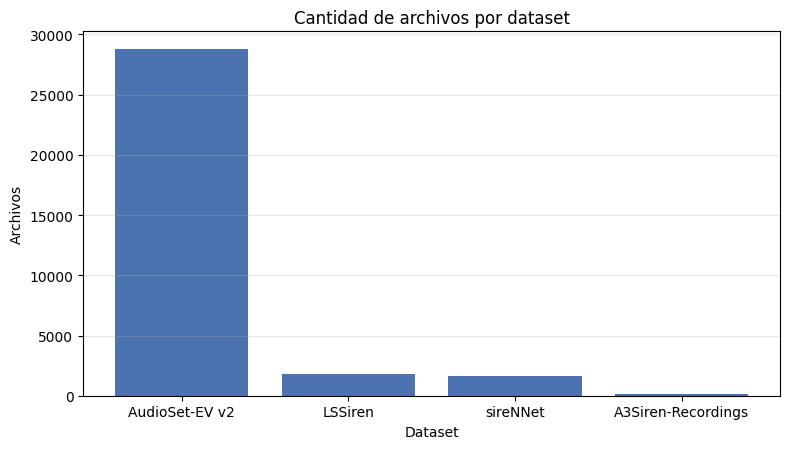

gráfico: /kaggle/working/dataset_eda/plots/structural_files_per_dataset.png
CANDIDATO PARA TESIS: /kaggle/working/dataset_eda/plots/thesis/fig_3_1_distribucion_muestras.png


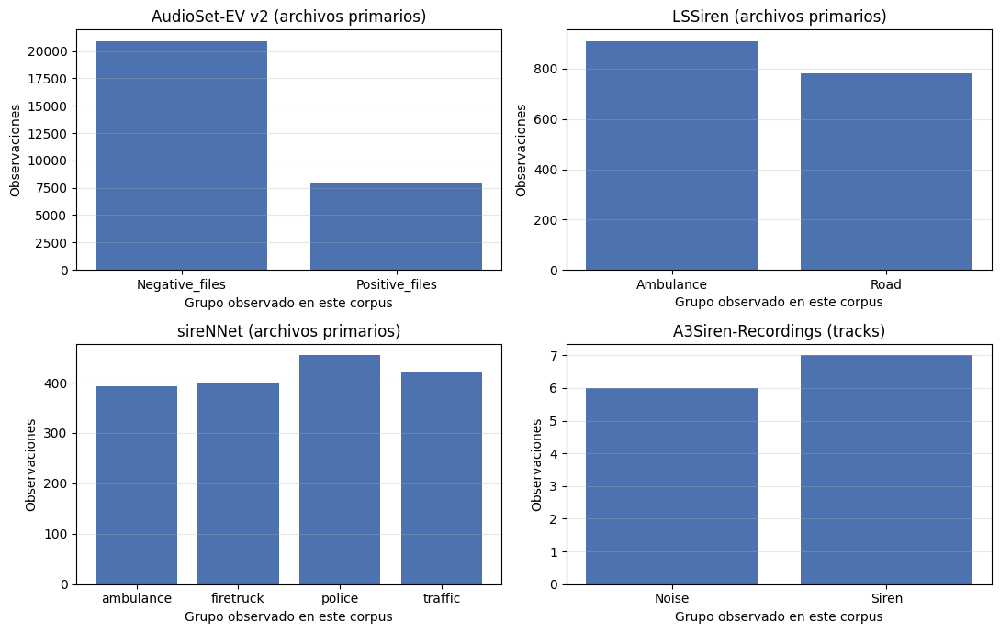

gráfico: /kaggle/working/dataset_eda/plots/class_counts_analytic.png


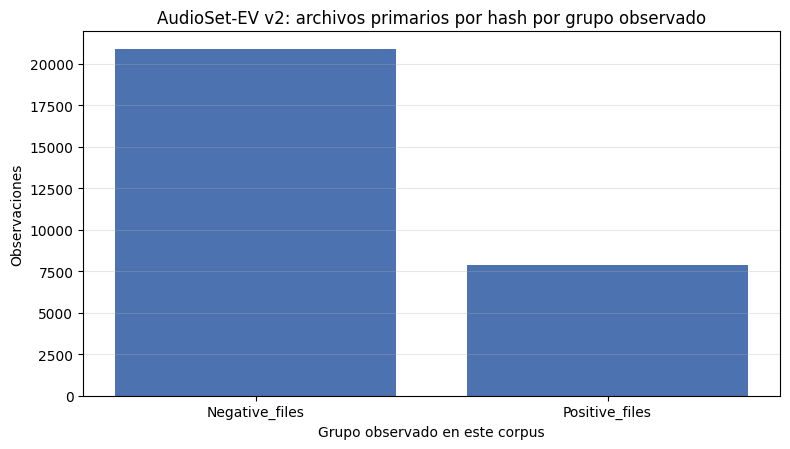

gráfico: /kaggle/working/dataset_eda/plots/class_counts_audioset_ev.png


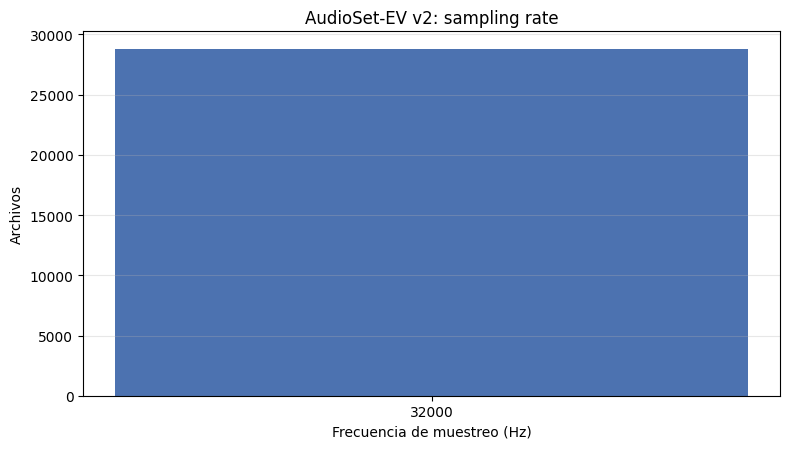

gráfico: /kaggle/working/dataset_eda/plots/sampling_rate_audioset_ev.png


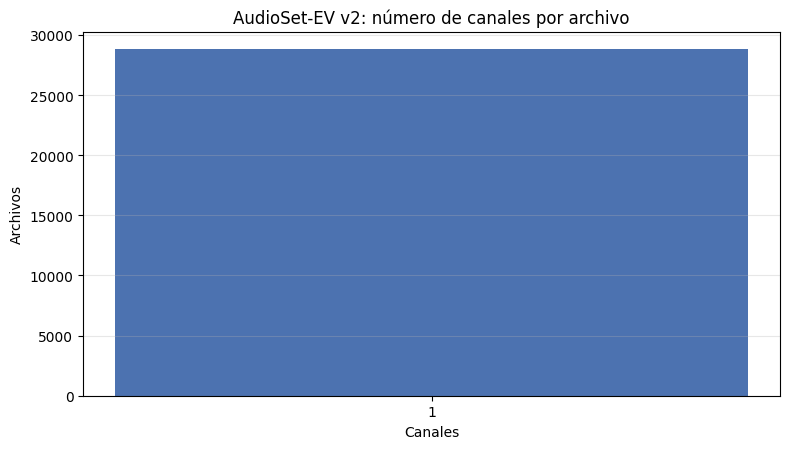

gráfico: /kaggle/working/dataset_eda/plots/channels_audioset_ev.png


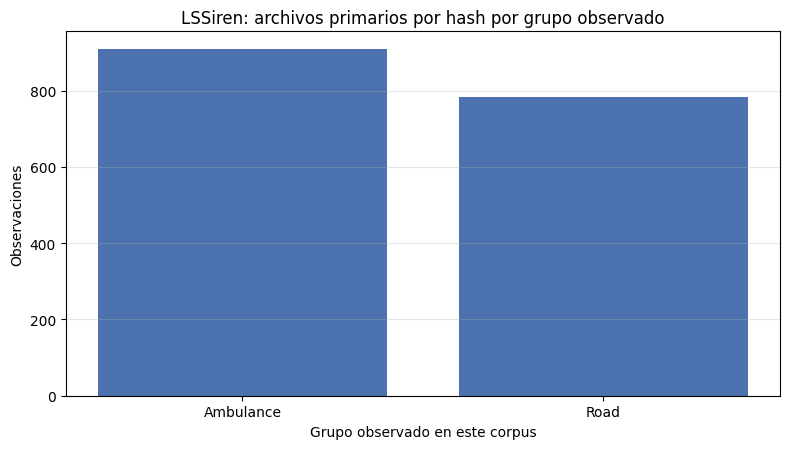

gráfico: /kaggle/working/dataset_eda/plots/class_counts_lssiren.png


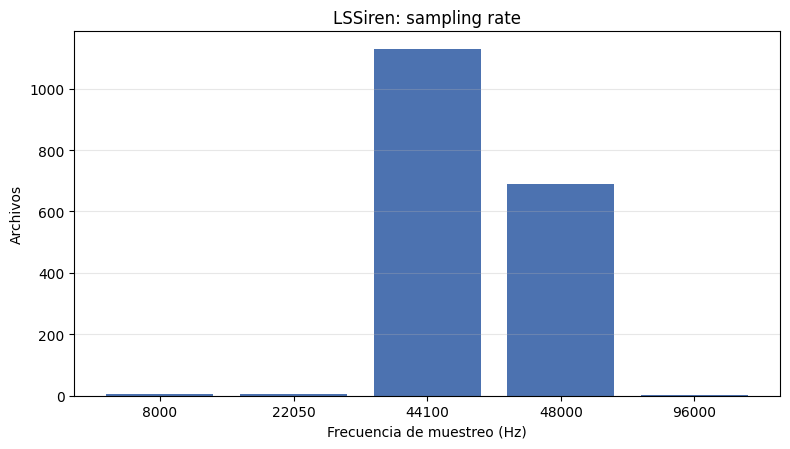

gráfico: /kaggle/working/dataset_eda/plots/sampling_rate_lssiren.png


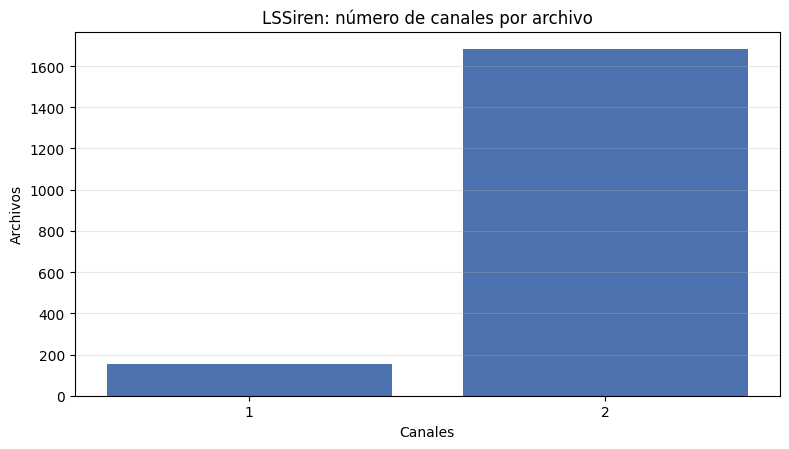

gráfico: /kaggle/working/dataset_eda/plots/channels_lssiren.png


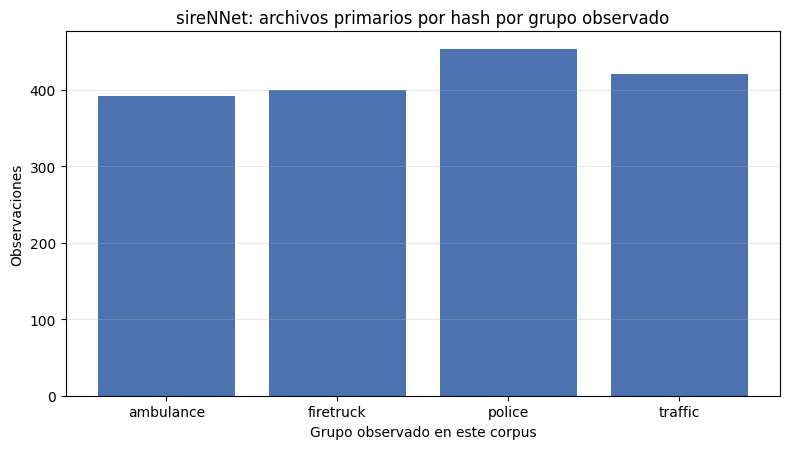

gráfico: /kaggle/working/dataset_eda/plots/class_counts_sirennet.png


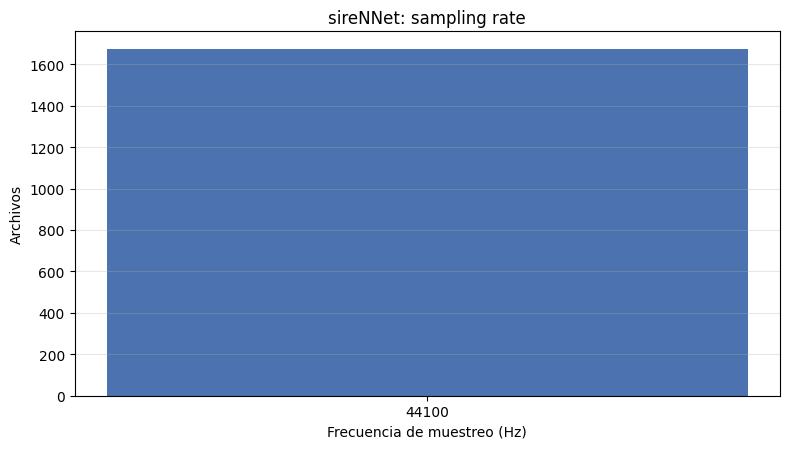

gráfico: /kaggle/working/dataset_eda/plots/sampling_rate_sirennet.png


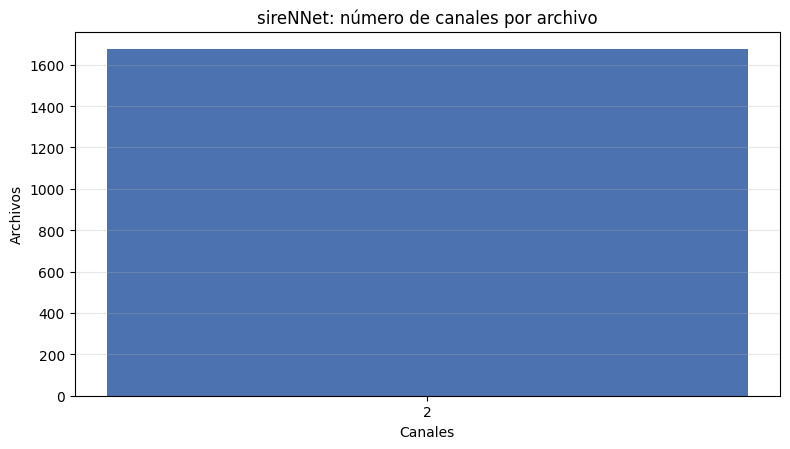

gráfico: /kaggle/working/dataset_eda/plots/channels_sirennet.png


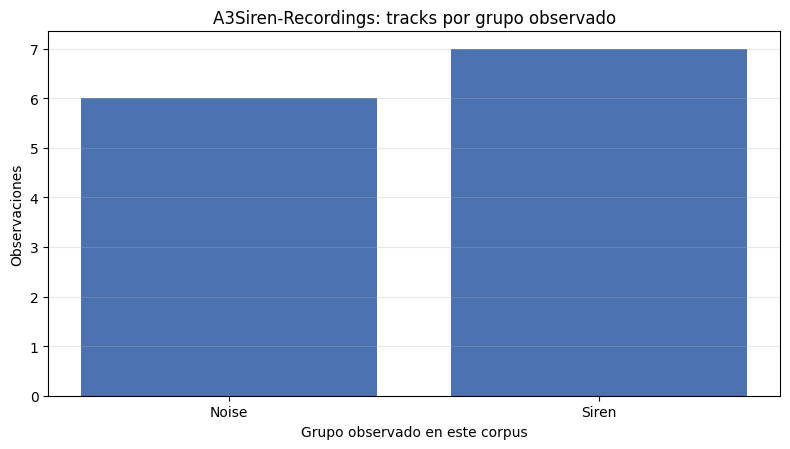

gráfico: /kaggle/working/dataset_eda/plots/class_counts_a3siren.png


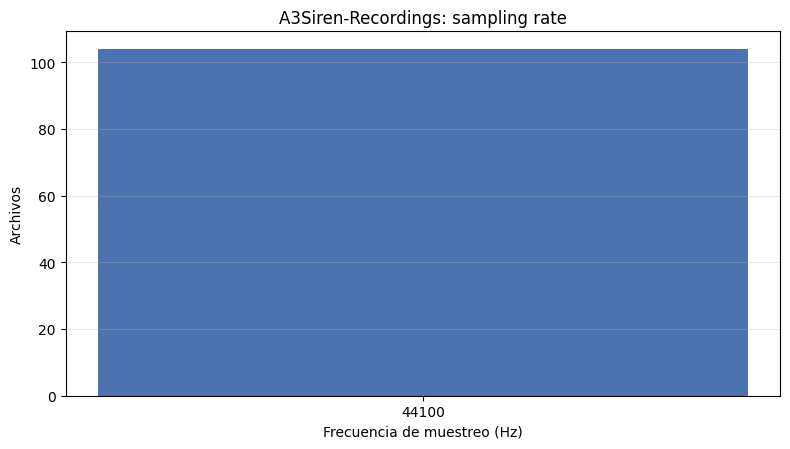

gráfico: /kaggle/working/dataset_eda/plots/sampling_rate_a3siren.png


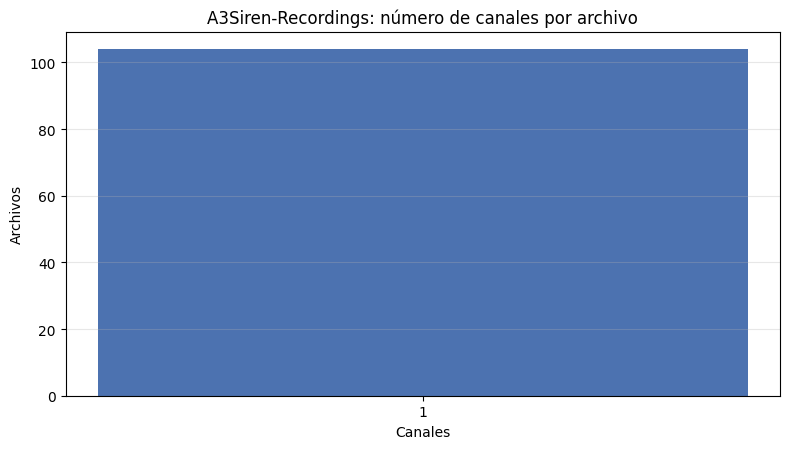

gráfico: /kaggle/working/dataset_eda/plots/channels_a3siren.png
CANDIDATO PARA TESIS: /kaggle/working/dataset_eda/plots/thesis/fig_3_3_sampling_rate.png


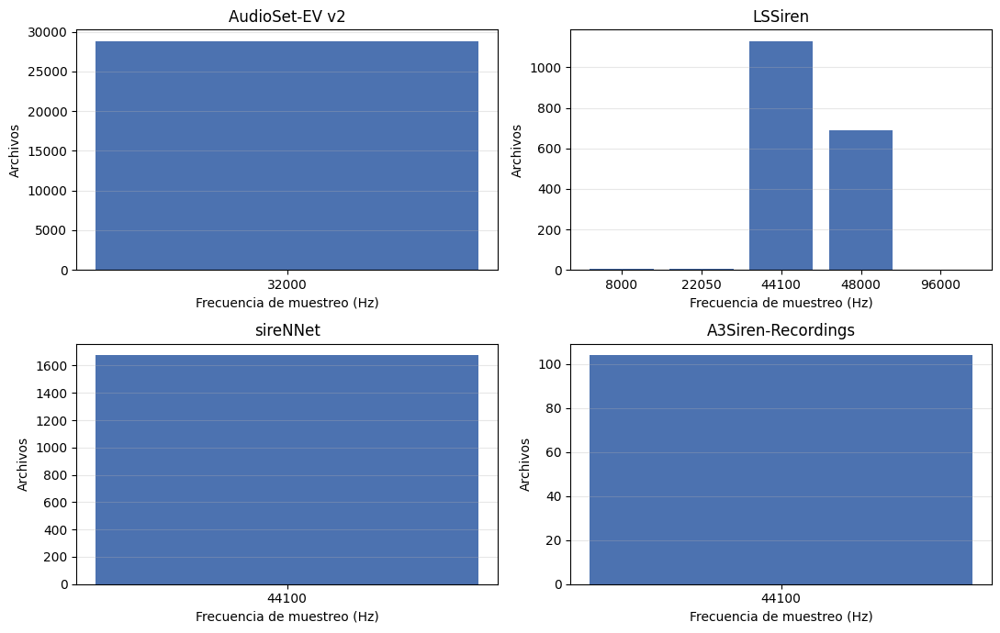

gráfico: /kaggle/working/dataset_eda/plots/sampling_rate_comparison.png


In [13]:
def section_structure() -> None:
    inventory = STATE["inventory"]
    rows = []
    for dataset_id in DATASET_ORDER:
        subset = inventory[inventory["dataset_id"] == dataset_id]
        valid = subset[subset["quality_status"] == "OK"]
        deduped = analytic_frame(inventory, dataset_id)
        rows.append({
            "dataset": DISPLAY[dataset_id],
            "files": int(len(subset)),
            "valid_files": int(len(valid)),
            "invalid_files": int((subset["quality_status"] != "OK").sum()),
            "duplicate_secondary_files": int((~valid["is_hash_primary"]).sum()) if dataset_id != "a3siren" else 0,
            "analysis_population": "track" if dataset_id == "a3siren" else "archivo_primario_por_hash",
            "analysis_n": int(len(deduped)),
        })
    population = pd.DataFrame(rows)
    STATE["population_summary"] = population
    export_table(population, "tabla_3_1_resumen_estructural.csv")
    show_df(population, n=10)
    fig, ax = plt.subplots(figsize=(8, 4.6))
    ax.bar(population["dataset"], population["files"], color="#4C72B0")
    style_ax(ax, "Cantidad de archivos por dataset", "Dataset", "Archivos")
    save_figure(fig, "structural_files_per_dataset.png")
    fig, axes = plt.subplots(2, 2, figsize=(11, 7))
    for ax, dataset_id in zip(axes.ravel(), DATASET_ORDER):
        analytic = analytic_frame(inventory, dataset_id)
        counts = analytic["analysis_group"].value_counts().sort_index()
        ax.bar(counts.index.astype(str), counts.values, color="#4C72B0")
        unit = "tracks" if dataset_id == "a3siren" else "archivos primarios"
        style_ax(ax, f"{DISPLAY[dataset_id]} ({unit})", "Grupo observado en este corpus", "Observaciones")
    save_figure(fig, "class_counts_analytic.png", "fig_3_1_distribucion_muestras.png")
    for dataset_id in DATASET_ORDER:
        subset = inventory[(inventory["dataset_id"] == dataset_id) & (inventory["quality_status"] == "OK")]
        analytic = analytic_frame(inventory, dataset_id)
        counts = analytic["analysis_group"].value_counts().sort_index()
        fig, ax = plt.subplots(figsize=(8, 4.6))
        ax.bar(counts.index.astype(str), counts.values, color="#4C72B0")
        unit = "tracks" if dataset_id == "a3siren" else "archivos primarios por hash"
        style_ax(ax, f"{DISPLAY[dataset_id]}: {unit} por grupo observado", "Grupo observado en este corpus", "Observaciones")
        save_figure(fig, f"class_counts_{dataset_id}.png")
        fig, ax = plt.subplots(figsize=(8, 4.6))
        rates = pd.to_numeric(subset["sampling_rate_hz"], errors="coerce").dropna().astype(int)
        rate_counts = rates.value_counts().sort_index()
        ax.bar([str(value) for value in rate_counts.index], rate_counts.values, color="#4C72B0")
        style_ax(ax, f"{DISPLAY[dataset_id]}: sampling rate", "Frecuencia de muestreo (Hz)", "Archivos")
        save_figure(fig, f"sampling_rate_{dataset_id}.png")
        fig, ax = plt.subplots(figsize=(8, 4.6))
        channels = pd.to_numeric(subset["channels"], errors="coerce").dropna().astype(int)
        channel_counts = channels.value_counts().sort_index()
        ax.bar([str(value) for value in channel_counts.index], channel_counts.values, color="#4C72B0")
        style_ax(ax, f"{DISPLAY[dataset_id]}: número de canales por archivo", "Canales", "Archivos")
        save_figure(fig, f"channels_{dataset_id}.png")
    fig, axes = plt.subplots(2, 2, figsize=(11, 7))
    for ax, dataset_id in zip(axes.ravel(), DATASET_ORDER):
        subset = inventory[(inventory["dataset_id"] == dataset_id) & (inventory["quality_status"] == "OK")]
        rates = pd.to_numeric(subset["sampling_rate_hz"], errors="coerce").dropna().astype(int)
        rate_counts = rates.value_counts().sort_index()
        ax.bar([str(value) for value in rate_counts.index], rate_counts.values, color="#4C72B0")
        style_ax(ax, DISPLAY[dataset_id], "Frecuencia de muestreo (Hz)", "Archivos")
    save_figure(fig, "sampling_rate_comparison.png", "fig_3_3_sampling_rate.png")

section_structure()


## 06. EDA de duración

La duración sale de la cabecera. En AudioSet-EV, LSSiren y sireNNet se cuenta un archivo por hash. En A3Siren se cuenta un track.


CANDIDATO PARA TESIS: /kaggle/working/dataset_eda/plots/thesis/fig_3_2_duracion.png


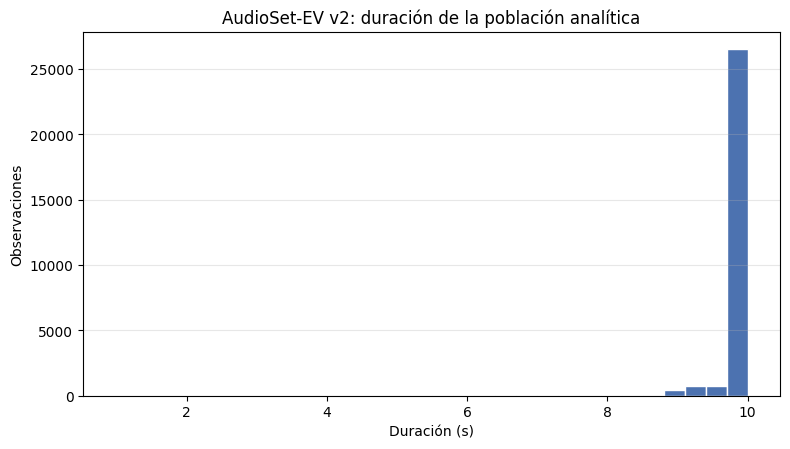

gráfico: /kaggle/working/dataset_eda/plots/duration_hist_audioset_ev.png


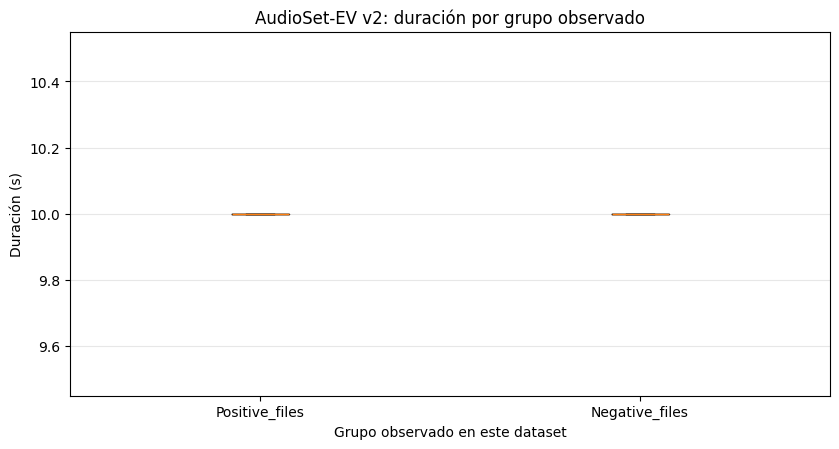

gráfico: /kaggle/working/dataset_eda/plots/duration_box_audioset_ev.png


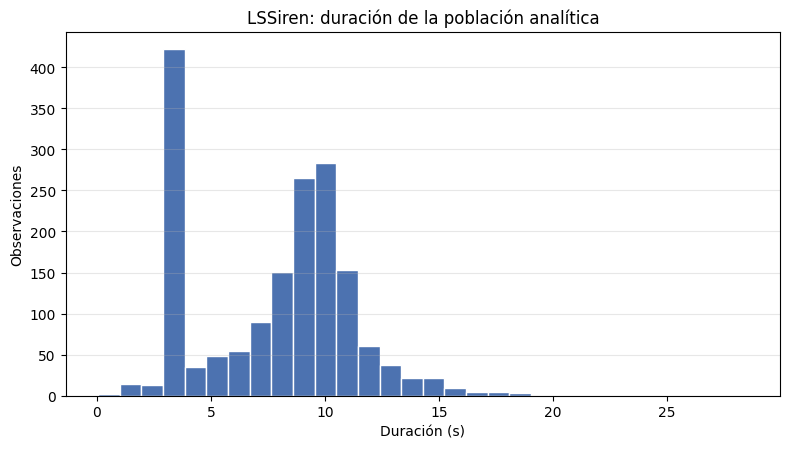

gráfico: /kaggle/working/dataset_eda/plots/duration_hist_lssiren.png


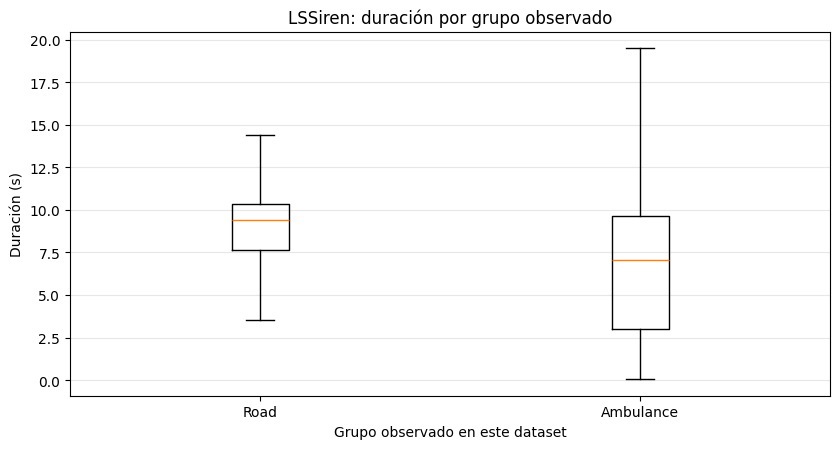

gráfico: /kaggle/working/dataset_eda/plots/duration_box_lssiren.png


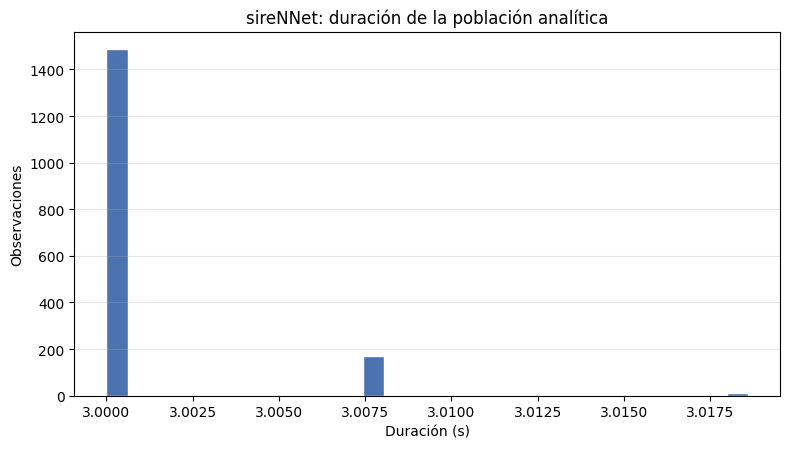

gráfico: /kaggle/working/dataset_eda/plots/duration_hist_sirennet.png


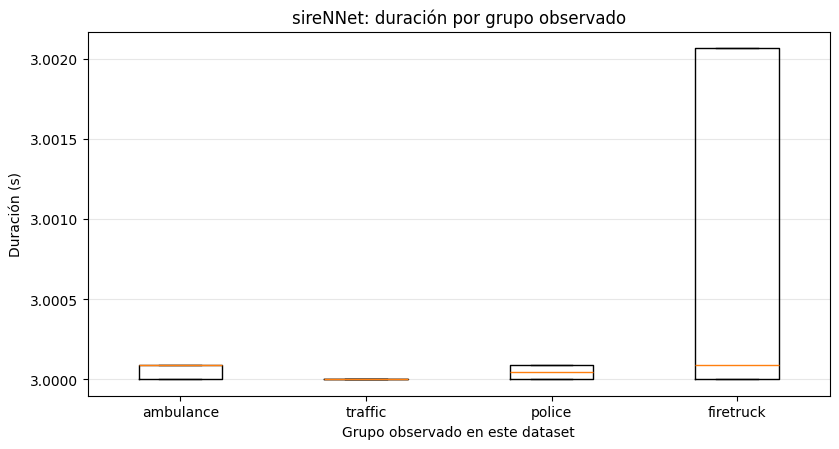

gráfico: /kaggle/working/dataset_eda/plots/duration_box_sirennet.png


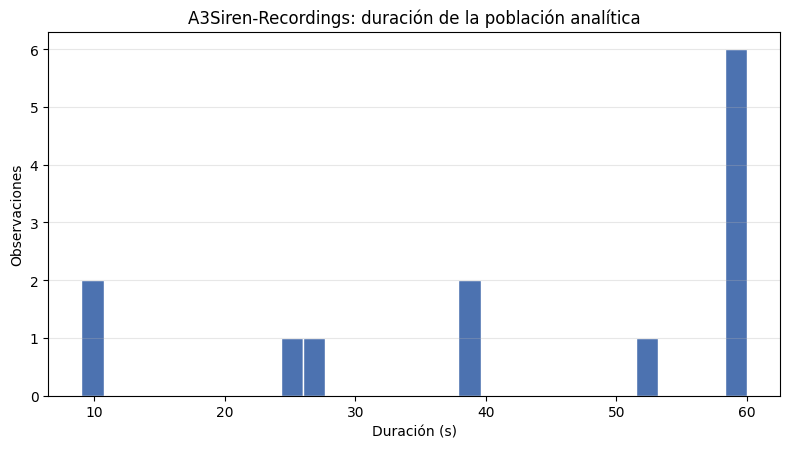

gráfico: /kaggle/working/dataset_eda/plots/duration_hist_a3siren.png


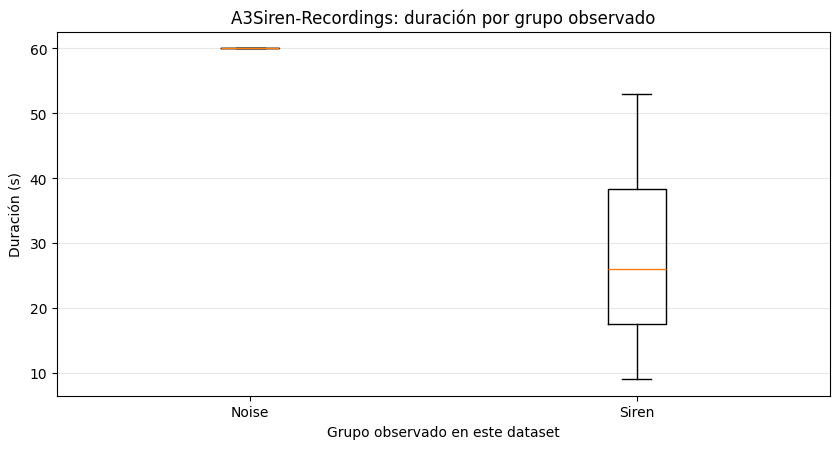

gráfico: /kaggle/working/dataset_eda/plots/duration_box_a3siren.png
escrito: /kaggle/working/dataset_eda/duration_statistics.csv
escrito: /kaggle/working/dataset_eda/tabla_3_2_duracion.csv
filas: 10 | columnas: 12


,dataset,analysis_group,feature,n,min,max,mean,median,std,p25,p75,p95
0,AudioSet-EV v2,Negative_files,duration_seconds,20898,0.975250,10.010906,9.927975,10.000000,0.459587,10.000000,10.000000,10.000625
1,AudioSet-EV v2,Positive_files,duration_seconds,7896,1.000000,10.009906,9.844461,10.000000,0.530928,10.000000,10.000000,10.000031
2,LSSiren,Ambulance,duration_seconds,910,0.050000,19.498667,6.718977,7.070766,3.673201,3.000000,9.662875,12.183467
3,LSSiren,Road,duration_seconds,783,0.719819,28.544000,8.862718,9.400998,2.907721,7.617104,10.347132,13.126400
4,sireNNet,ambulance,duration_seconds,392,3.000000,3.018594,3.001936,3.000091,0.004061,3.000000,3.000091,3.007982
5,sireNNet,firetruck,duration_seconds,400,3.000000,3.007982,3.002029,3.000091,0.003441,3.000000,3.002063,3.007982
6,sireNNet,police,duration_seconds,454,3.000000,3.000091,3.000045,3.000045,0.000045,3.000000,3.000091,3.000091
7,sireNNet,traffic,duration_seconds,421,3.000000,3.000000,3.000000,3.000000,0.000000,3.000000,3.000000,3.000000
8,A3Siren-Recordings,Noise,duration_seconds,6,60.000000,60.000000,60.000000,60.000000,0.000000,60.000000,60.000000,60.000000
9,A3Siren-Recordings,Siren,duration_seconds,7,9.000000,53.000000,28.500000,26.000000,15.976545,17.500000,38.250000,48.650000


In [14]:
def section_duration() -> None:
    inventory = STATE["inventory"]
    duration_parts = []
    for dataset_id in DATASET_ORDER:
        base = analytic_frame(inventory, dataset_id)
        if dataset_id == "a3siren":
            base = base.copy()
            base["dataset"] = DISPLAY[dataset_id]
        duration_parts.append(numeric_summary(base, ["duration_seconds"], ["dataset", "analysis_group"]))
        fig, ax = plt.subplots(figsize=(8, 4.6))
        ax.hist(pd.to_numeric(base["duration_seconds"], errors="coerce").dropna(), bins=30, color="#4C72B0", edgecolor="white")
        style_ax(ax, f"{DISPLAY[dataset_id]}: duración de la población analítica", "Duración (s)", "Observaciones")
        thesis = "fig_3_2_duracion.png" if dataset_id == "audioset_ev" else None
        save_figure(fig, f"duration_hist_{dataset_id}.png", thesis)
        plot_box(base, "duration_seconds", f"{DISPLAY[dataset_id]}: duración por grupo observado", "Duración (s)", f"duration_box_{dataset_id}.png")
    duration = pd.concat(duration_parts, ignore_index=True)
    STATE["duration_stats"] = duration
    export_table(duration, "duration_statistics.csv")
    export_table(duration, "tabla_3_2_duracion.csv")
    show_df(duration, n=40)

section_duration()


## 07. EDA de amplitud y energía

RMS, pico, crest factor, clipping y silencio de la muestra. Estas distribuciones no se presentan como una regla de clasificación.


características:   0%|          | 0/1504 [00:00<?, ?it/s]

escrito: /kaggle/working/dataset_eda/amplitude_energy_statistics.csv


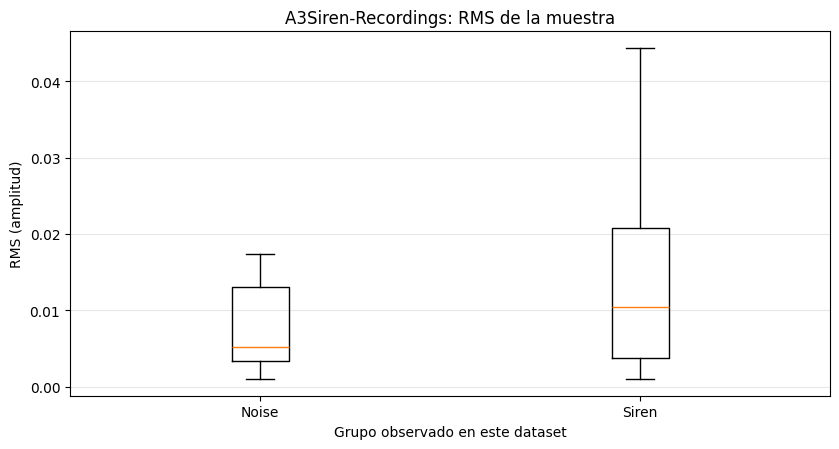

gráfico: /kaggle/working/dataset_eda/plots/rms_a3siren.png


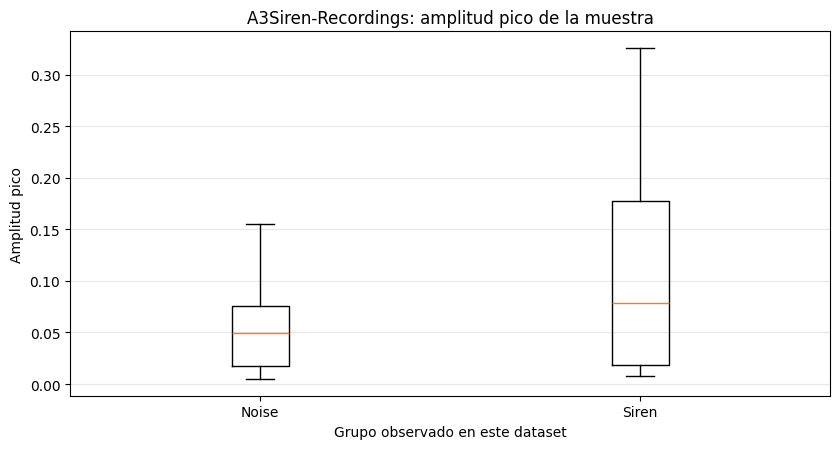

gráfico: /kaggle/working/dataset_eda/plots/peak_a3siren.png


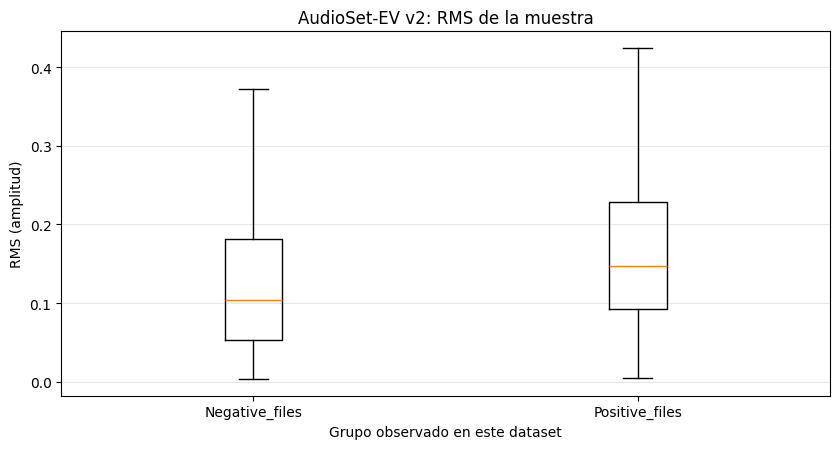

gráfico: /kaggle/working/dataset_eda/plots/rms_audioset_ev.png


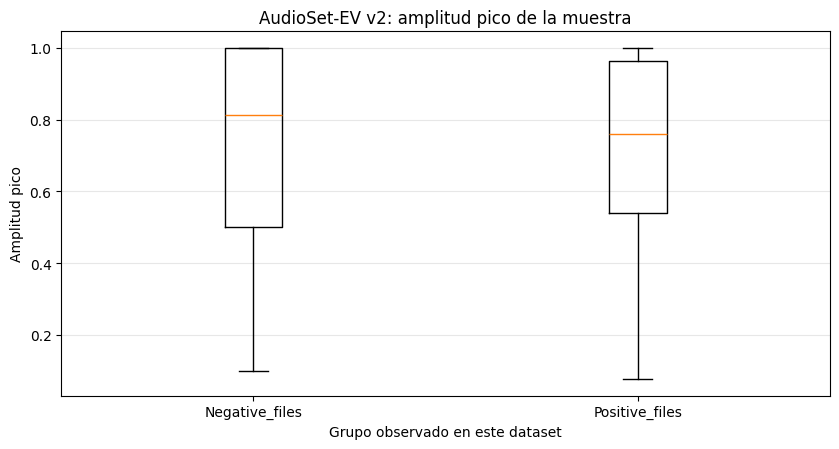

gráfico: /kaggle/working/dataset_eda/plots/peak_audioset_ev.png


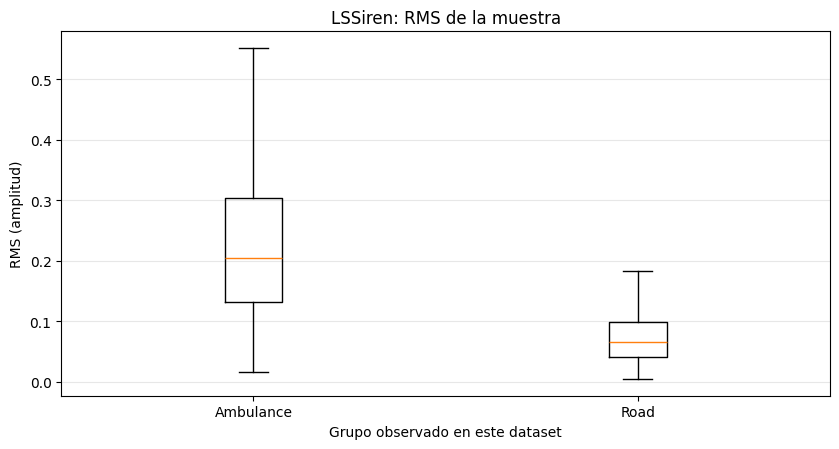

gráfico: /kaggle/working/dataset_eda/plots/rms_lssiren.png


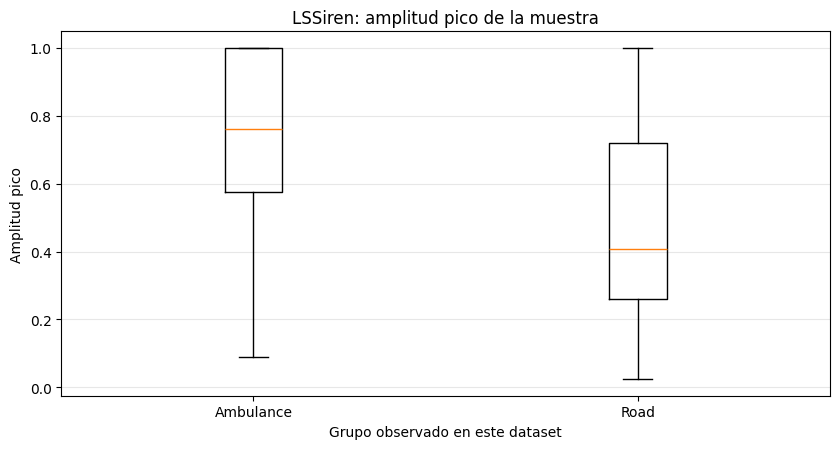

gráfico: /kaggle/working/dataset_eda/plots/peak_lssiren.png
CANDIDATO PARA TESIS: /kaggle/working/dataset_eda/plots/thesis/fig_3_4_rms.png


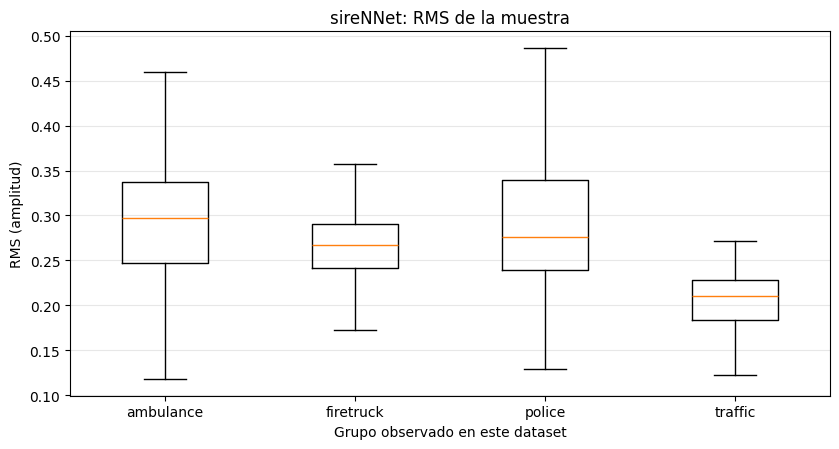

gráfico: /kaggle/working/dataset_eda/plots/rms_sirennet.png


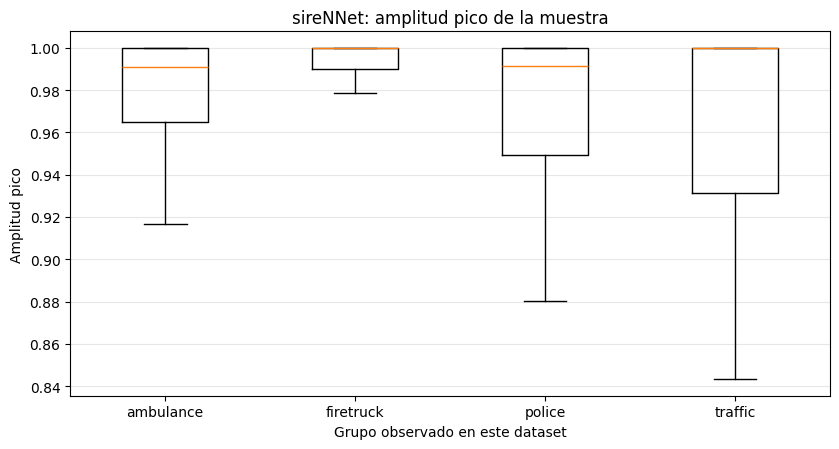

gráfico: /kaggle/working/dataset_eda/plots/peak_sirennet.png


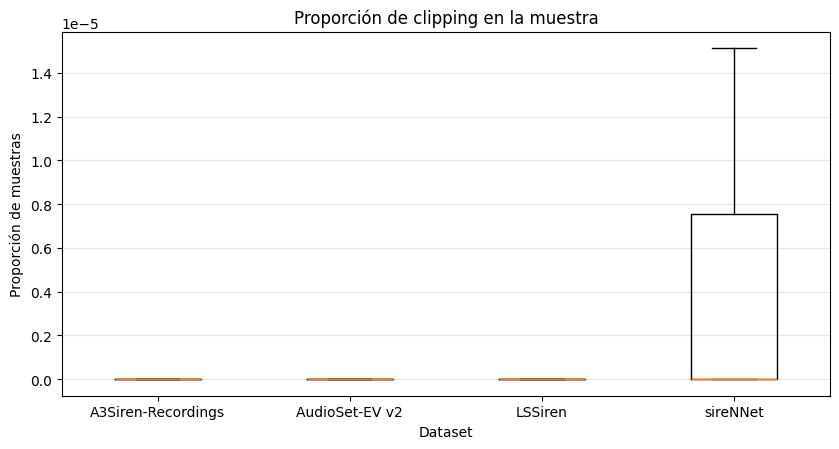

gráfico: /kaggle/working/dataset_eda/plots/clipping_ratio_by_dataset.png


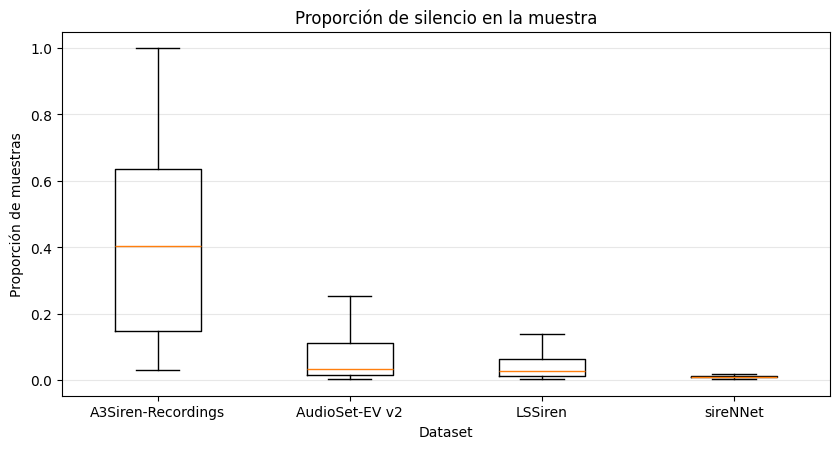

gráfico: /kaggle/working/dataset_eda/plots/silence_ratio_by_dataset.png


In [15]:
def section_amplitude() -> None:
    features = ensure_features()
    energy = numeric_summary(features, ["rms_mean", "rms_std", "peak_amplitude", "crest_factor", "clipping_ratio", "silence_ratio"], ["dataset", "analysis_group"])
    export_table(energy, "amplitude_energy_statistics.csv")
    STATE["energy_stats"] = energy
    for dataset, group in features.groupby("dataset"):
        slug = group["dataset_id"].iloc[0]
        plot_box(group, "rms_mean", f"{dataset}: RMS de la muestra", "RMS (amplitud)", f"rms_{slug}.png", "fig_3_4_rms.png" if slug == "sirennet" else None)
        plot_box(group, "peak_amplitude", f"{dataset}: amplitud pico de la muestra", "Amplitud pico", f"peak_{slug}.png")
    for column, title, ylabel, filename in (
        ("clipping_ratio", "Proporción de clipping en la muestra", "Proporción de muestras", "clipping_ratio_by_dataset.png"),
        ("silence_ratio", "Proporción de silencio en la muestra", "Proporción de muestras", "silence_ratio_by_dataset.png"),
    ):
        fig, ax = plt.subplots(figsize=(8.5, 4.6))
        labels, data = [], []
        for dataset, group in features.groupby("dataset"):
            values = pd.to_numeric(group[column], errors="coerce").dropna()
            if values.empty:
                continue
            labels.append(dataset)
            data.append(values)
        if data:
            ax.boxplot(data, tick_labels=labels, showfliers=False)
            style_ax(ax, title, "Dataset", ylabel)
            save_figure(fig, filename)

section_amplitude()


## 08. EDA temporal

ZCR de la muestra y, para un archivo reproducible de cada grupo, forma de onda, envolvente, RMS por trama y ZCR por trama. Cada figura es un ejemplo, no un prototipo de la clase.


escrito: /kaggle/working/dataset_eda/zcr_statistics.csv
escrito: /kaggle/working/dataset_eda/tabla_3_3_temporales.csv


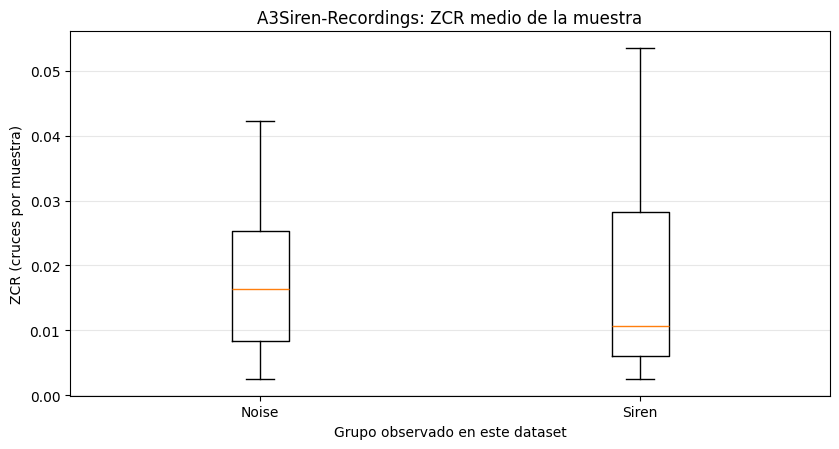

gráfico: /kaggle/working/dataset_eda/plots/zcr_a3siren.png


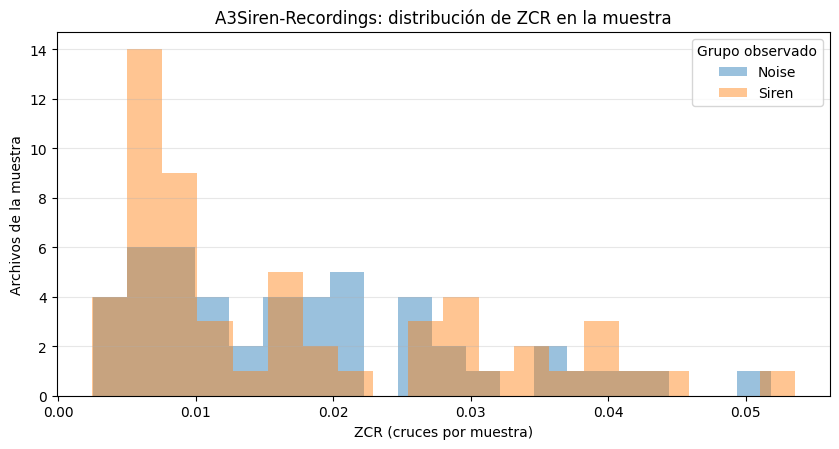

gráfico: /kaggle/working/dataset_eda/plots/zcr_hist_a3siren.png


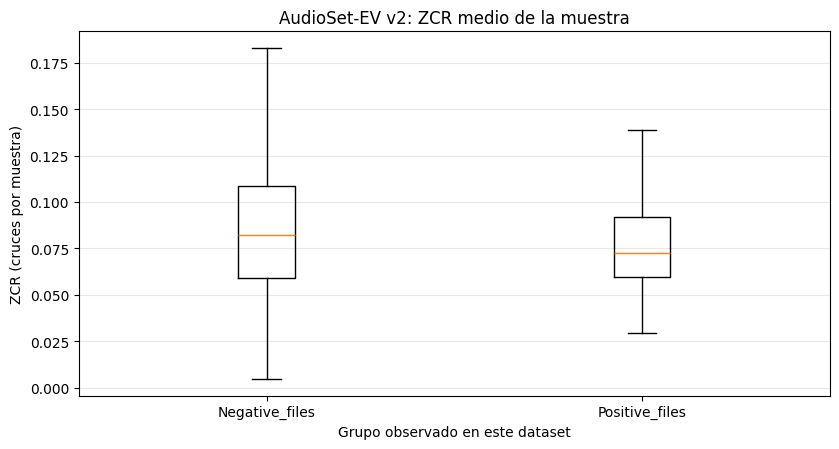

gráfico: /kaggle/working/dataset_eda/plots/zcr_audioset_ev.png


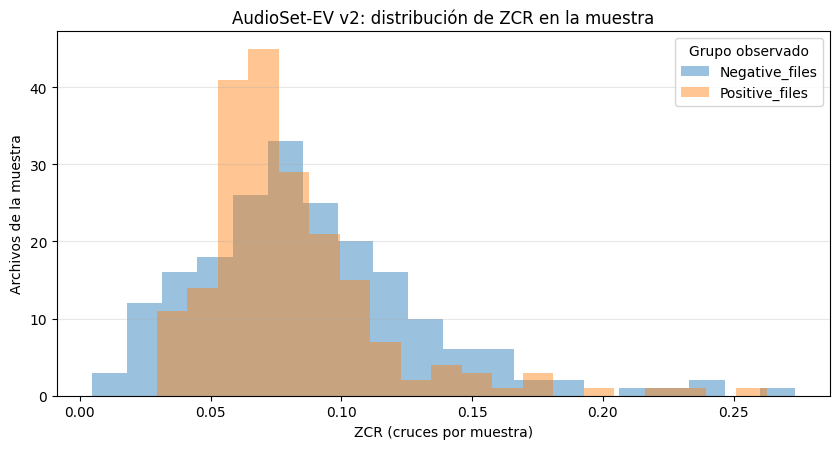

gráfico: /kaggle/working/dataset_eda/plots/zcr_hist_audioset_ev.png


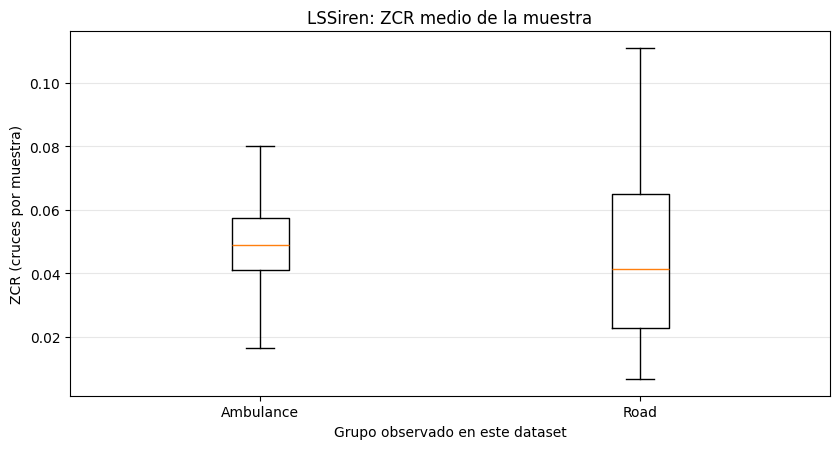

gráfico: /kaggle/working/dataset_eda/plots/zcr_lssiren.png


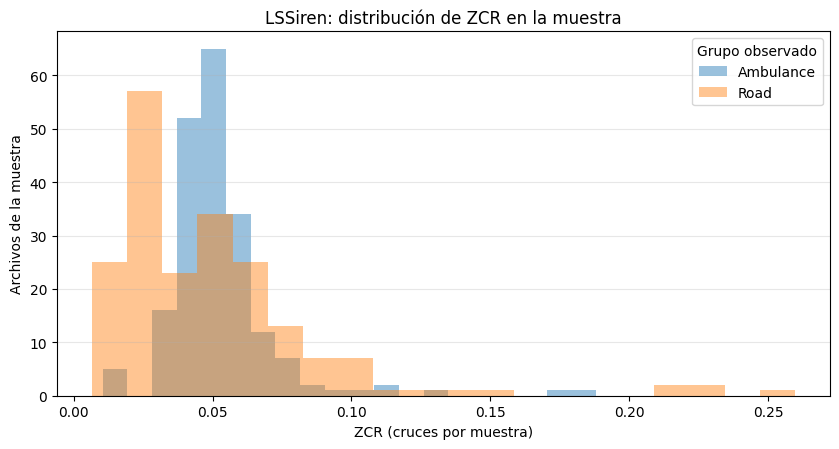

gráfico: /kaggle/working/dataset_eda/plots/zcr_hist_lssiren.png


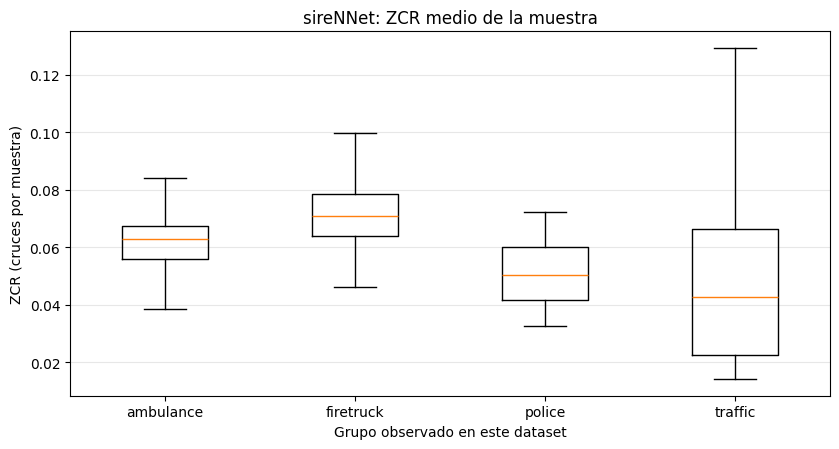

gráfico: /kaggle/working/dataset_eda/plots/zcr_sirennet.png


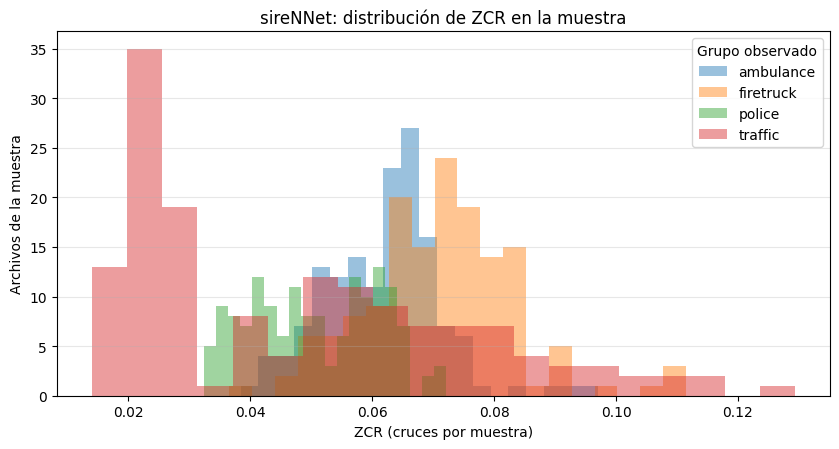

gráfico: /kaggle/working/dataset_eda/plots/zcr_hist_sirennet.png


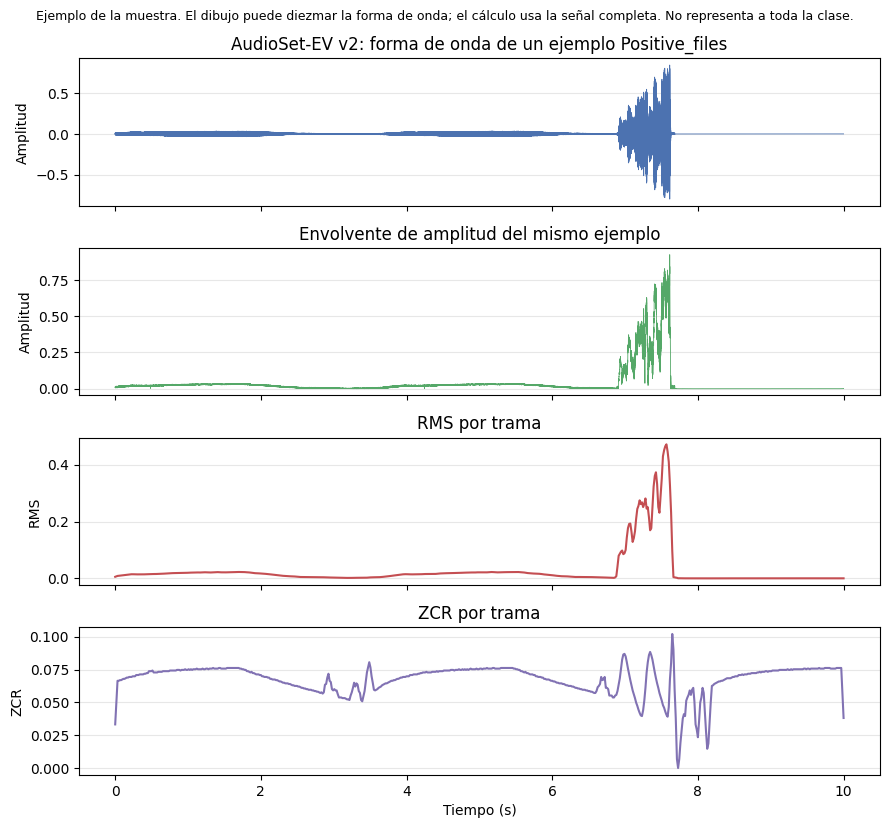

gráfico: /kaggle/working/dataset_eda/plots/temporal_examples/AudioSet-EV_v2_Positive_files.png


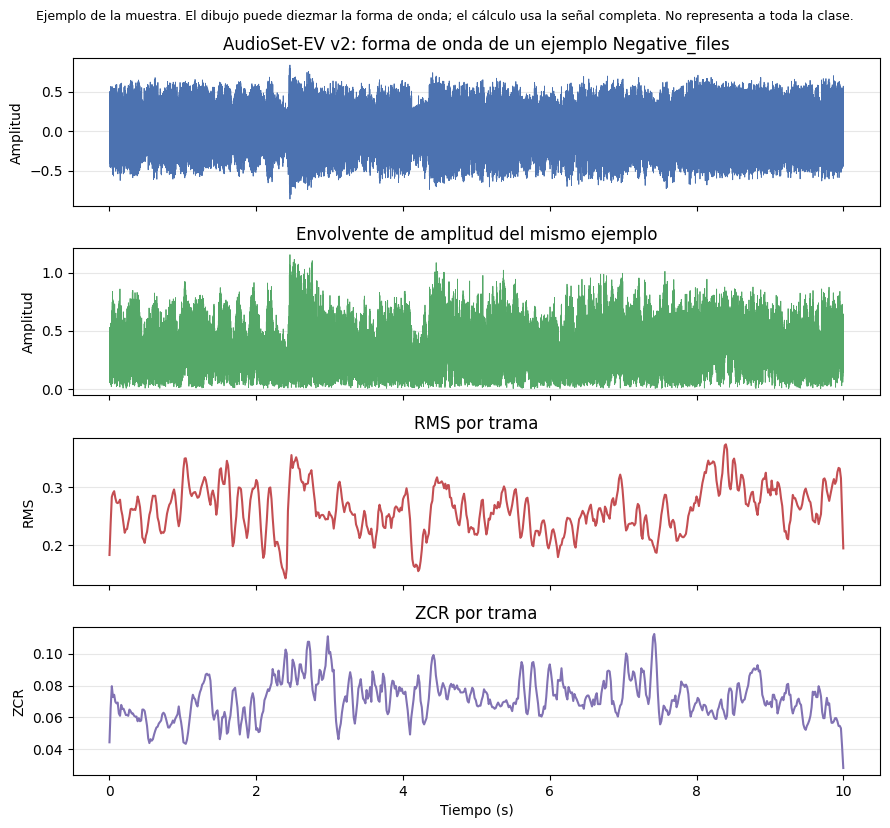

gráfico: /kaggle/working/dataset_eda/plots/temporal_examples/AudioSet-EV_v2_Negative_files.png


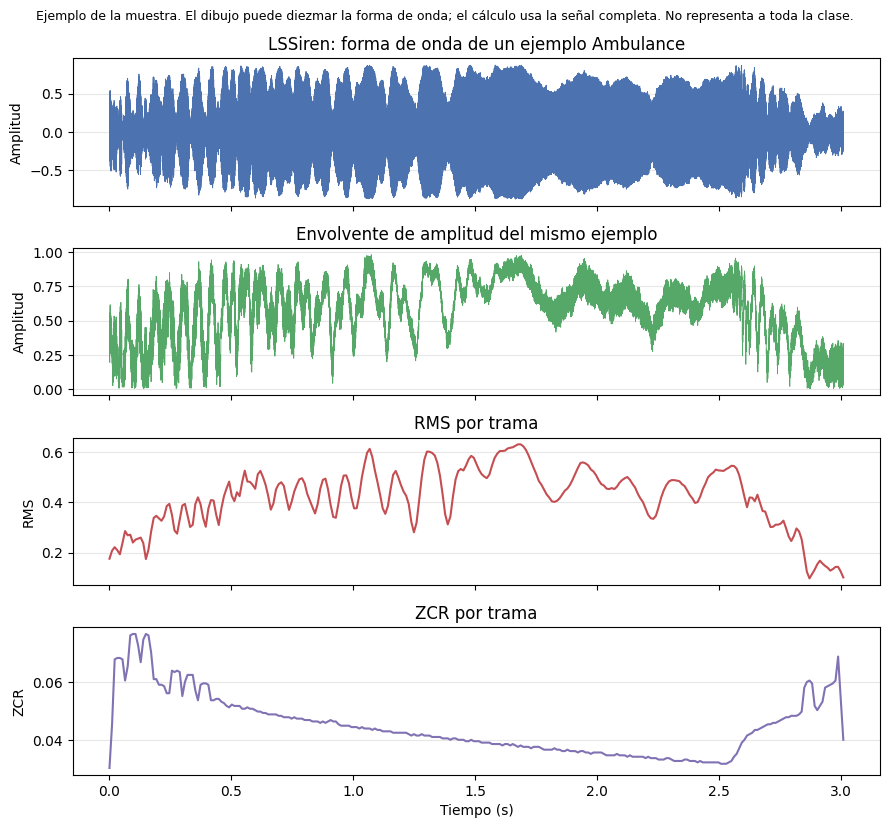

gráfico: /kaggle/working/dataset_eda/plots/temporal_examples/LSSiren_Ambulance.png


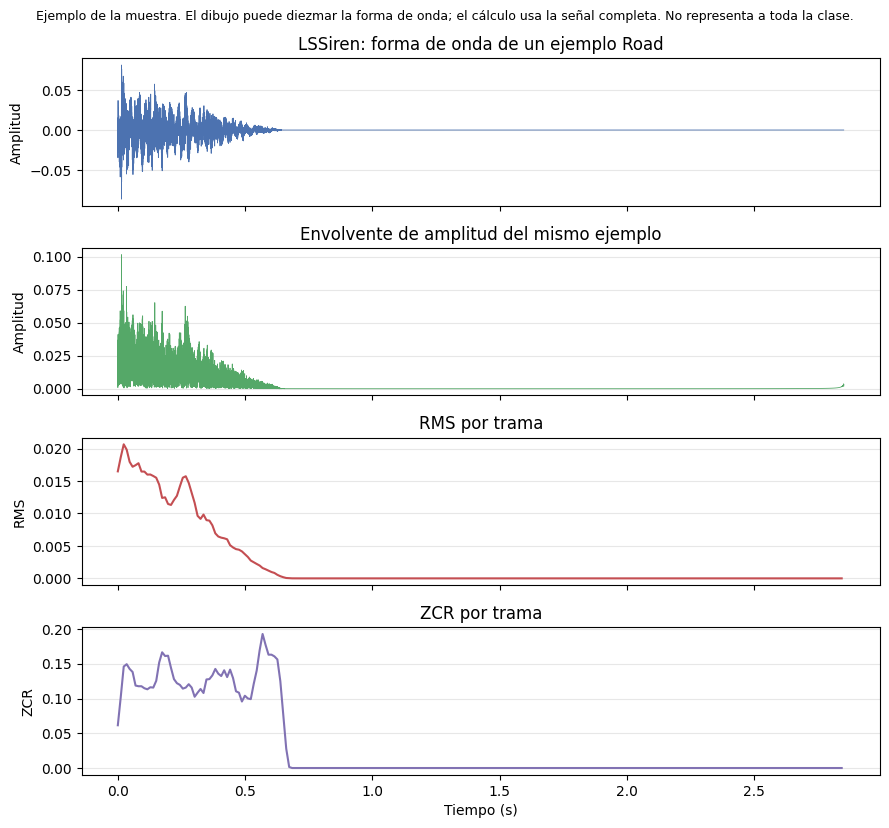

gráfico: /kaggle/working/dataset_eda/plots/temporal_examples/LSSiren_Road.png


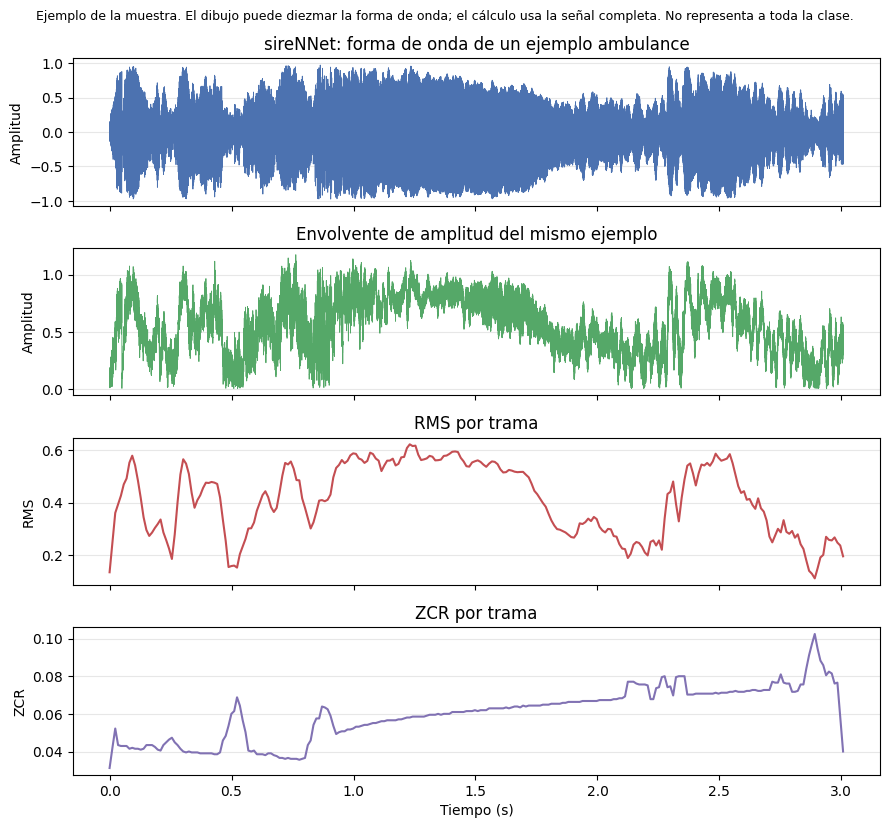

gráfico: /kaggle/working/dataset_eda/plots/temporal_examples/sireNNet_ambulance.png


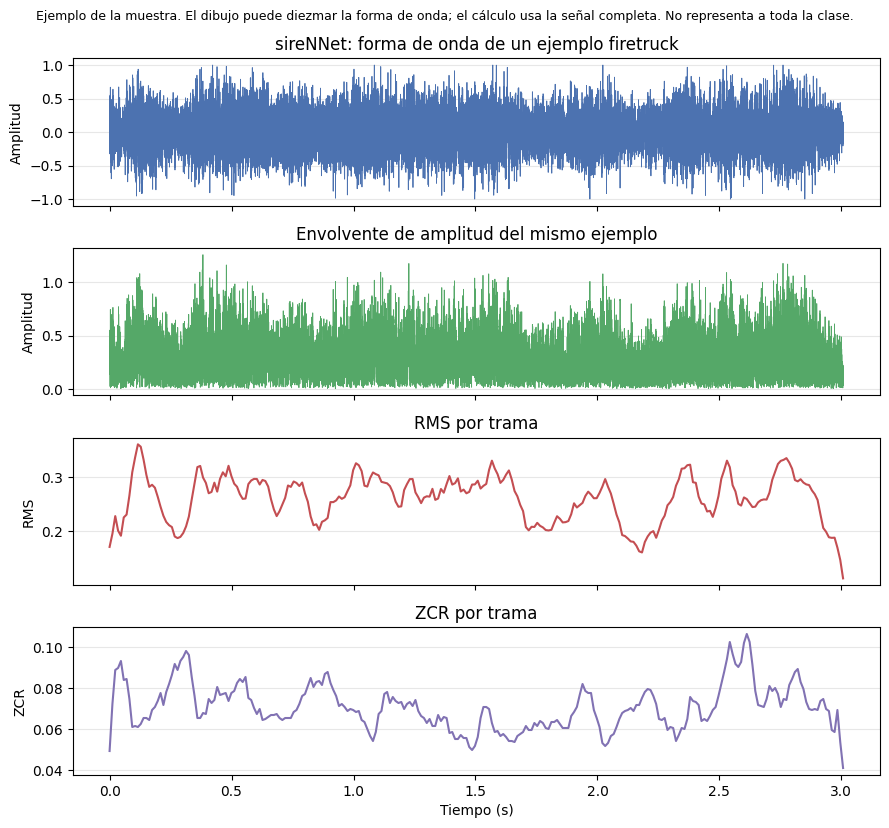

gráfico: /kaggle/working/dataset_eda/plots/temporal_examples/sireNNet_firetruck.png


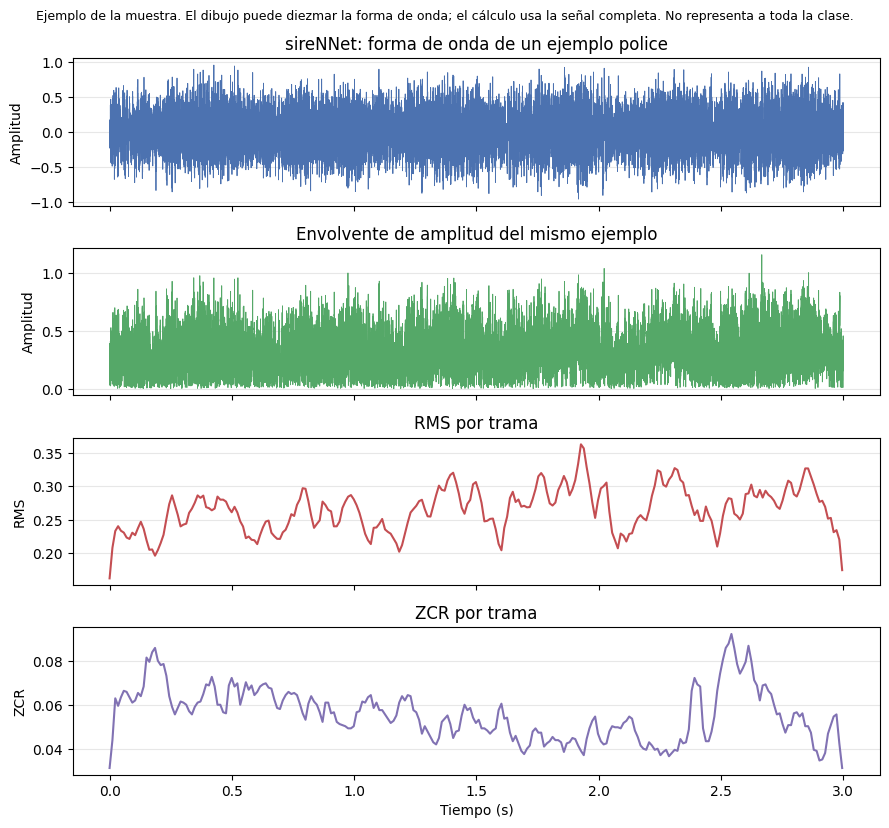

gráfico: /kaggle/working/dataset_eda/plots/temporal_examples/sireNNet_police.png


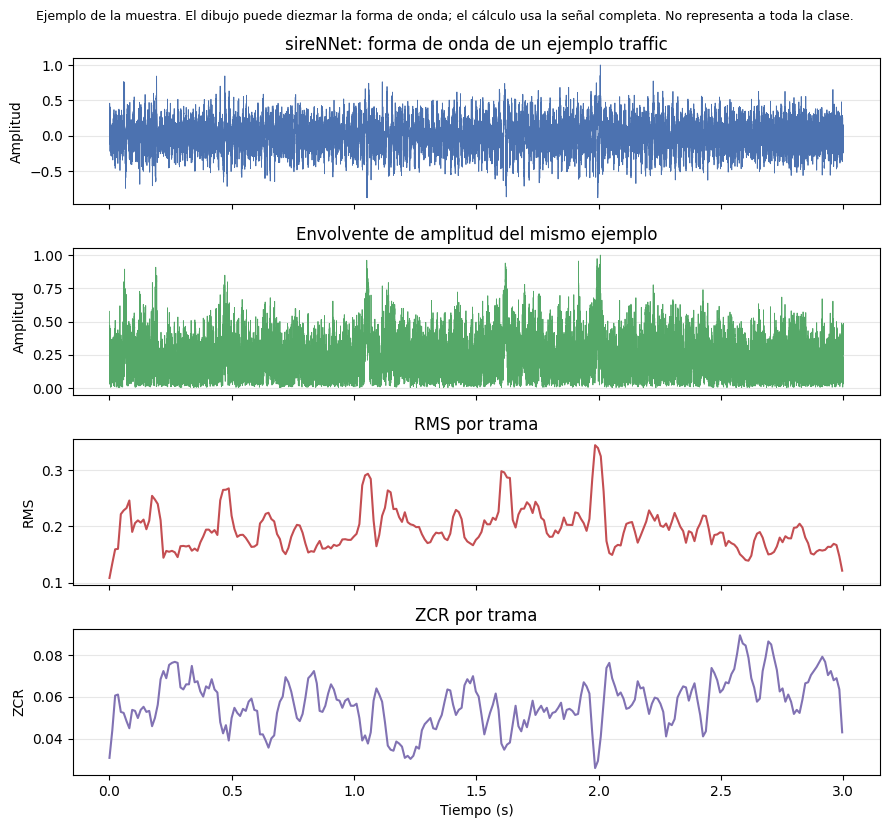

gráfico: /kaggle/working/dataset_eda/plots/temporal_examples/sireNNet_traffic.png


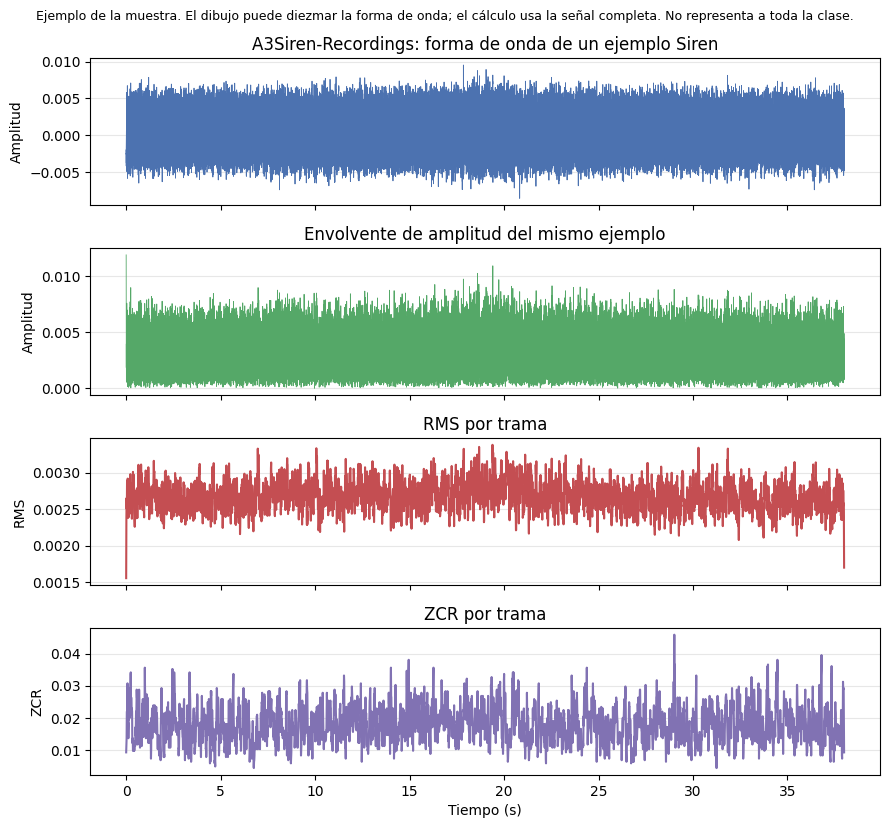

gráfico: /kaggle/working/dataset_eda/plots/temporal_examples/A3Siren-Recordings_Siren.png


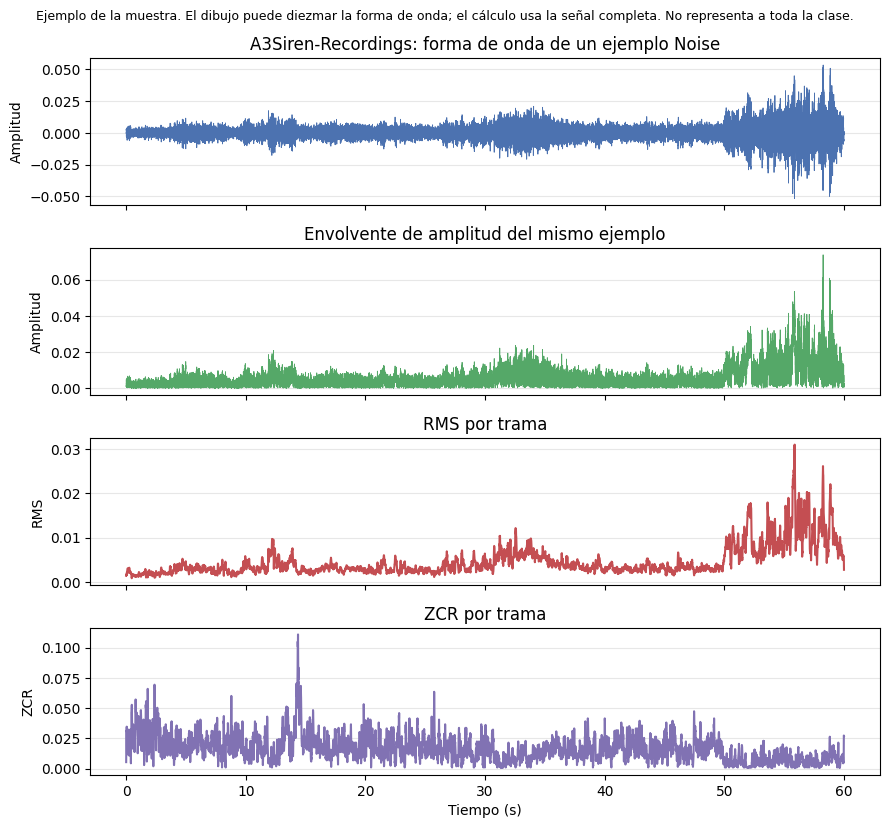

gráfico: /kaggle/working/dataset_eda/plots/temporal_examples/A3Siren-Recordings_Noise.png
Ejemplos temporales guardados: 10. Cada uno es un archivo de la muestra, no un prototipo de clase.


In [16]:
def section_temporal() -> None:
    features = ensure_features()
    zcr = numeric_summary(features, ["zcr_mean", "zcr_median"], ["dataset", "analysis_group"])
    export_table(zcr, "zcr_statistics.csv")
    export_table(zcr, "tabla_3_3_temporales.csv")
    STATE["zcr_stats"] = zcr
    for dataset, group in features.groupby("dataset"):
        slug = group["dataset_id"].iloc[0]
        plot_box(group, "zcr_mean", f"{dataset}: ZCR medio de la muestra", "ZCR (cruces por muestra)", f"zcr_{slug}.png")
        fig, ax = plt.subplots(figsize=(8.5, 4.6))
        for label, subgroup in group.groupby("analysis_group"):
            values = pd.to_numeric(subgroup["zcr_mean"], errors="coerce").dropna()
            if values.empty:
                continue
            ax.hist(values, bins=20, alpha=0.45, label=str(label))
        style_ax(ax, f"{dataset}: distribución de ZCR en la muestra", "ZCR (cruces por muestra)", "Archivos de la muestra")
        ax.legend(title="Grupo observado")
        save_figure(fig, f"zcr_hist_{slug}.png")
    examples = pick_examples(features)
    for pick in examples.itertuples(index=False):
        waveform, sr, _mix = load_audio(Path(pick.absolute_path))
        time = np.arange(len(waveform)) / sr
        step = max(1, len(waveform) // 80_000)
        envelope = np.abs(hilbert(waveform))
        fig, axes = plt.subplots(4, 1, figsize=(9, 8.4), sharex=True)
        axes[0].plot(time[::step], waveform[::step], color="#4C72B0", linewidth=0.6)
        style_ax(axes[0], f"{pick.dataset}: forma de onda de un ejemplo {pick.analysis_group}", "", "Amplitud")
        axes[1].plot(time[::step], envelope[::step], color="#55A868", linewidth=0.6)
        style_ax(axes[1], "Envolvente de amplitud del mismo ejemplo", "", "Amplitud")
        frame_rms = librosa.feature.rms(y=waveform, frame_length=WIN_LENGTH, hop_length=HOP_LENGTH)[0]
        frame_zcr = librosa.feature.zero_crossing_rate(waveform, frame_length=WIN_LENGTH, hop_length=HOP_LENGTH)[0]
        times = librosa.times_like(frame_rms, sr=sr, hop_length=HOP_LENGTH)
        limit = min(len(times), len(frame_rms), len(frame_zcr))
        axes[2].plot(times[:limit], frame_rms[:limit], color="#C44E52")
        style_ax(axes[2], "RMS por trama", "", "RMS")
        axes[3].plot(times[:limit], frame_zcr[:limit], color="#8172B3")
        style_ax(axes[3], "ZCR por trama", "Tiempo (s)", "ZCR")
        fig.suptitle("Ejemplo de la muestra. El dibujo puede diezmar la forma de onda; el cálculo usa la señal completa. No representa a toda la clase.", fontsize=9)
        save_figure(fig, f"temporal_examples/{pick.dataset}_{pick.analysis_group}.png".replace(" ", "_"))
    print(f"Ejemplos temporales guardados: {len(examples)}. Cada uno es un archivo de la muestra, no un prototipo de clase.")

section_temporal()


## 09. EDA frecuencial

Frecuencia dominante, centroide, ancho de banda, roll-off al 85 %, flatness y flujo espectral. La frecuencia dominante no identifica por sí sola una sirena. En LSSiren un valor en hertz no es equivalente entre tasas de muestreo distintas.


escrito: /kaggle/working/dataset_eda/dominant_frequency_statistics.csv
escrito: /kaggle/working/dataset_eda/spectral_centroid_statistics.csv
escrito: /kaggle/working/dataset_eda/spectral_bandwidth_statistics.csv
escrito: /kaggle/working/dataset_eda/rolloff_statistics.csv
escrito: /kaggle/working/dataset_eda/spectral_flux_statistics.csv
escrito: /kaggle/working/dataset_eda/tabla_3_4_frecuenciales.csv


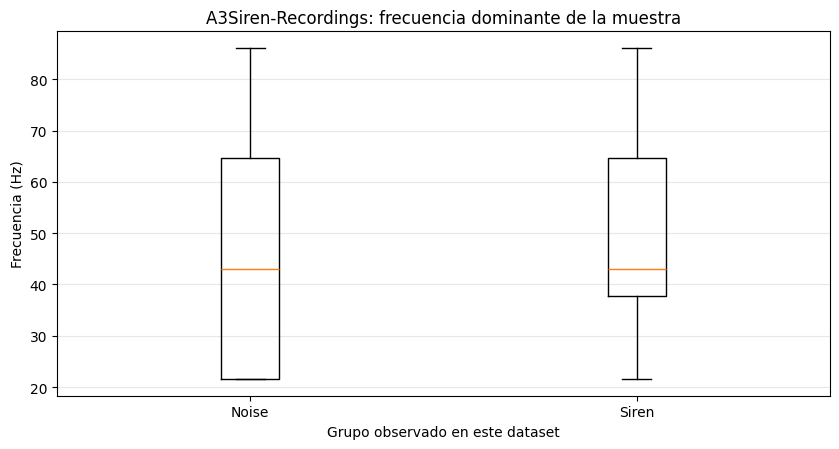

gráfico: /kaggle/working/dataset_eda/plots/dominant_a3siren.png


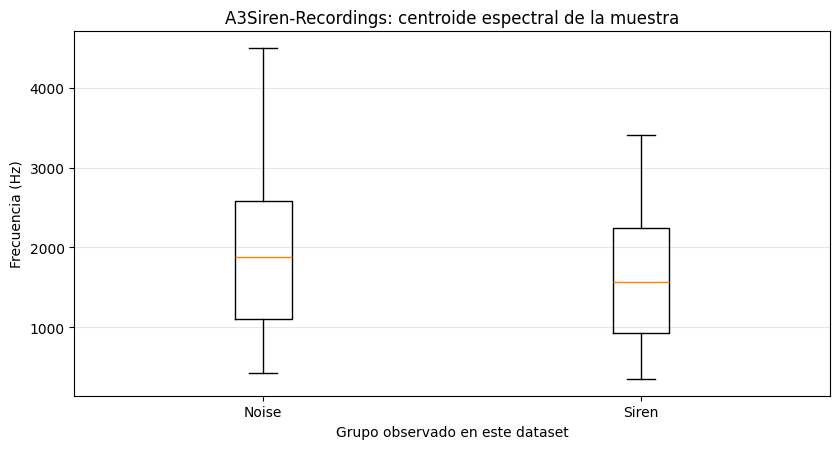

gráfico: /kaggle/working/dataset_eda/plots/centroid_a3siren.png


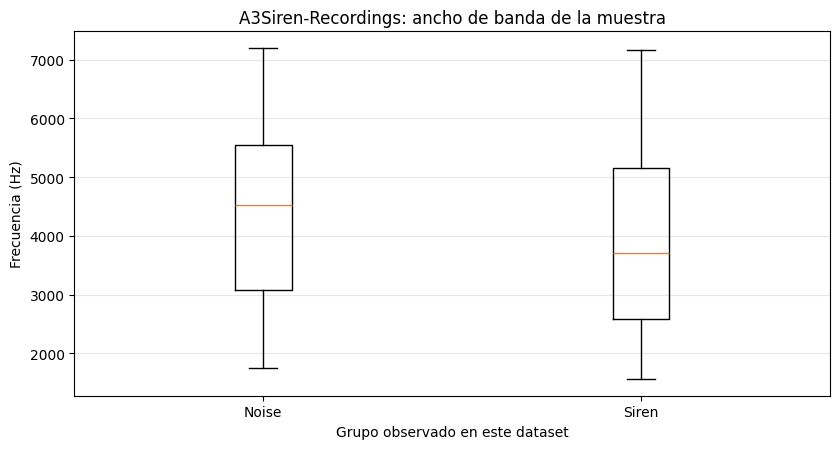

gráfico: /kaggle/working/dataset_eda/plots/bandwidth_a3siren.png


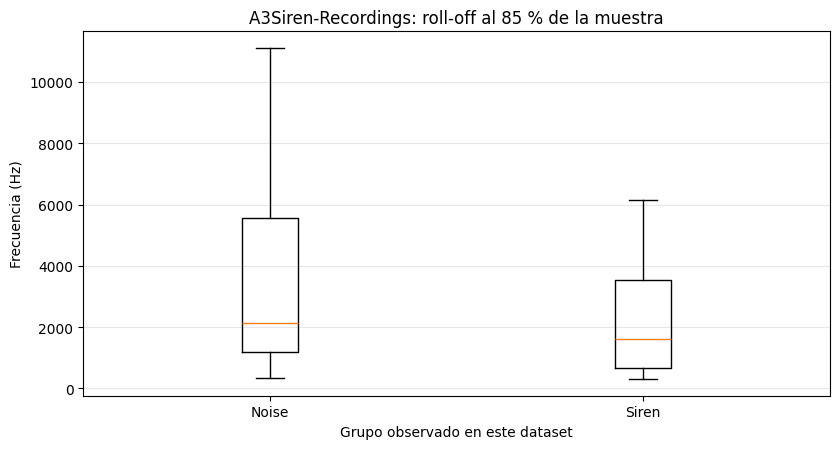

gráfico: /kaggle/working/dataset_eda/plots/rolloff_a3siren.png


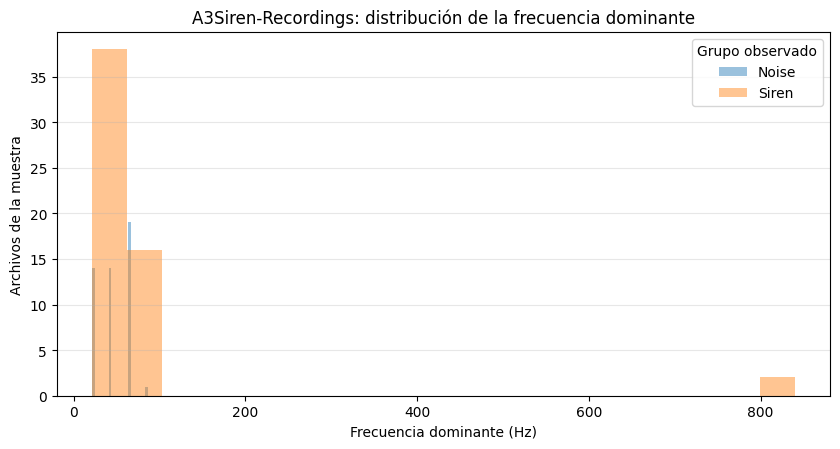

gráfico: /kaggle/working/dataset_eda/plots/dominant_hist_a3siren.png


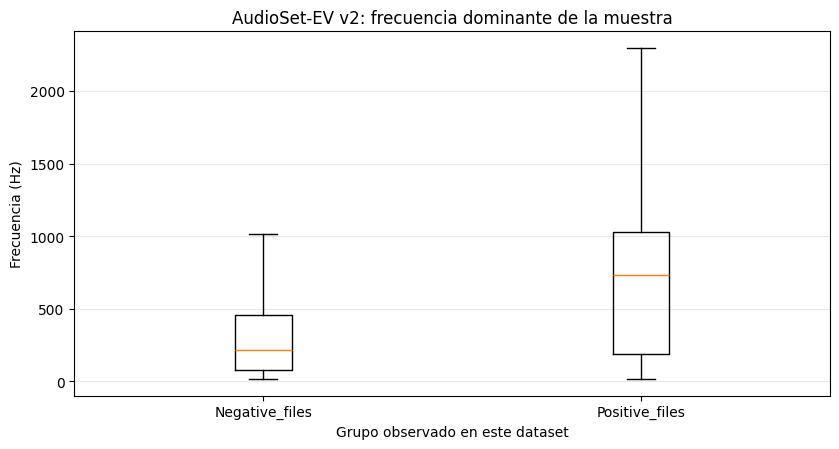

gráfico: /kaggle/working/dataset_eda/plots/dominant_audioset_ev.png


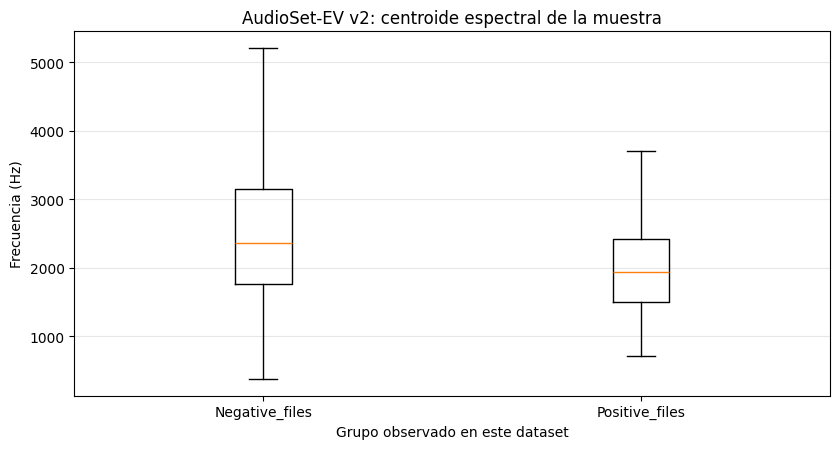

gráfico: /kaggle/working/dataset_eda/plots/centroid_audioset_ev.png


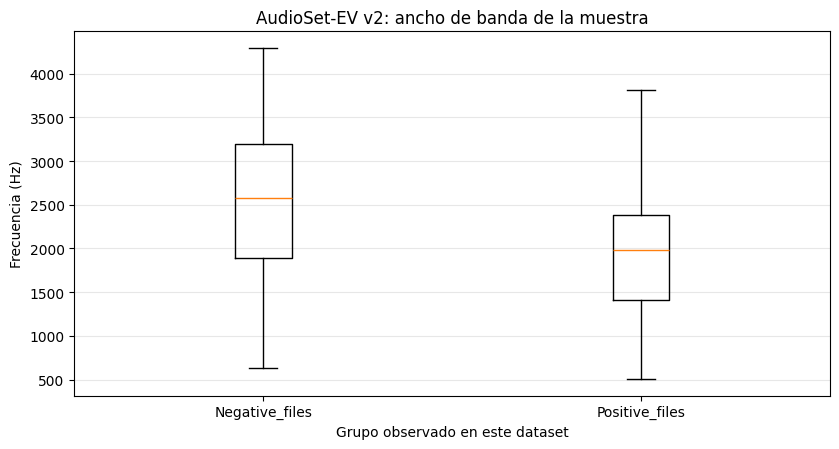

gráfico: /kaggle/working/dataset_eda/plots/bandwidth_audioset_ev.png


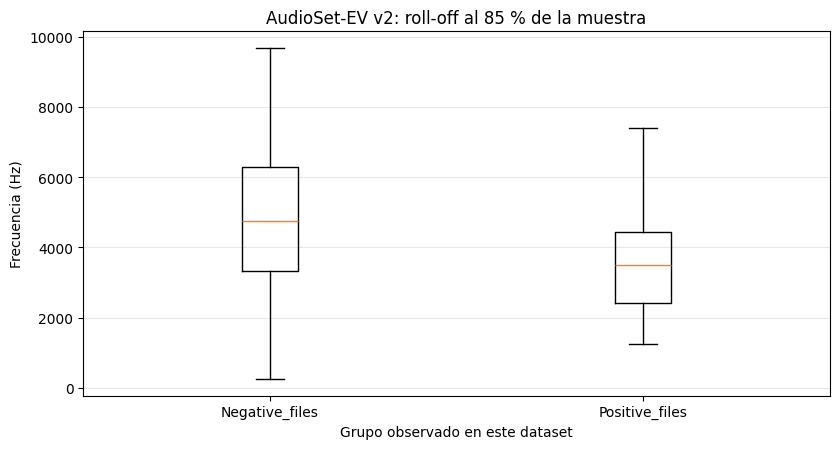

gráfico: /kaggle/working/dataset_eda/plots/rolloff_audioset_ev.png


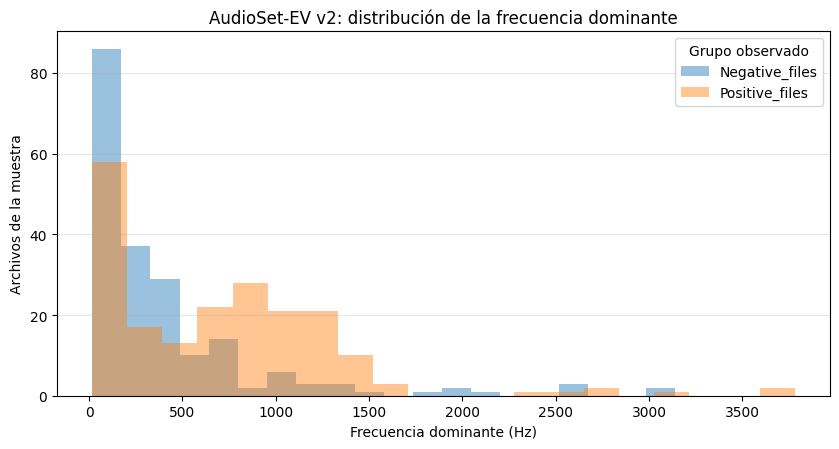

gráfico: /kaggle/working/dataset_eda/plots/dominant_hist_audioset_ev.png


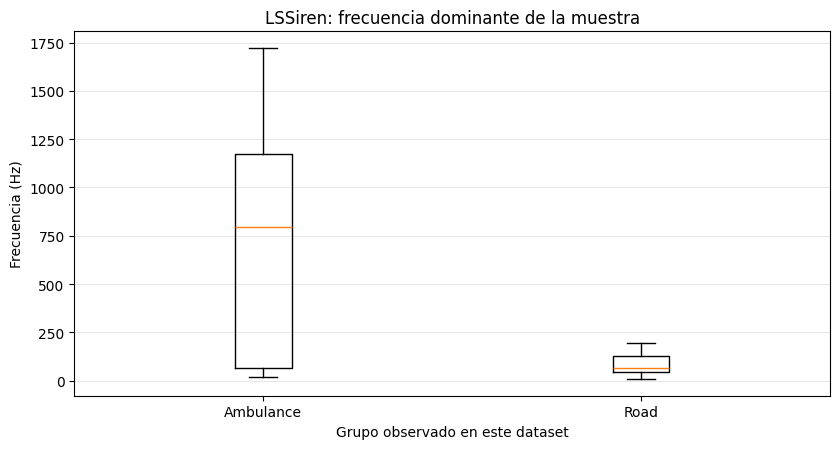

gráfico: /kaggle/working/dataset_eda/plots/dominant_lssiren.png
CANDIDATO PARA TESIS: /kaggle/working/dataset_eda/plots/thesis/fig_3_5_centroid.png


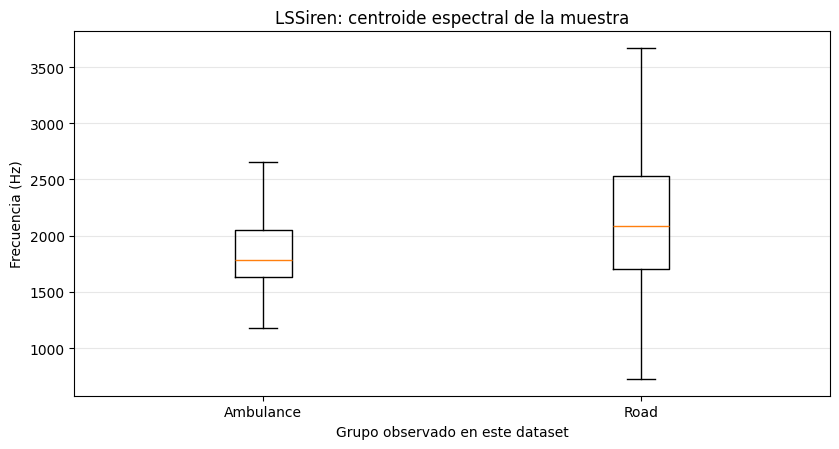

gráfico: /kaggle/working/dataset_eda/plots/centroid_lssiren.png


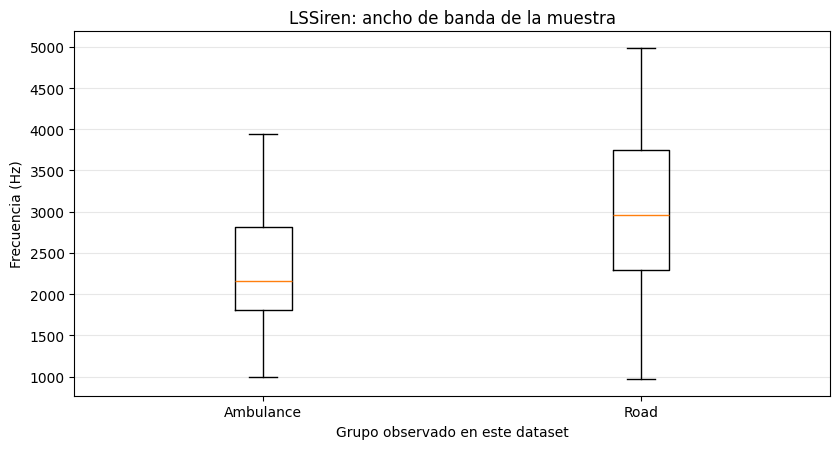

gráfico: /kaggle/working/dataset_eda/plots/bandwidth_lssiren.png


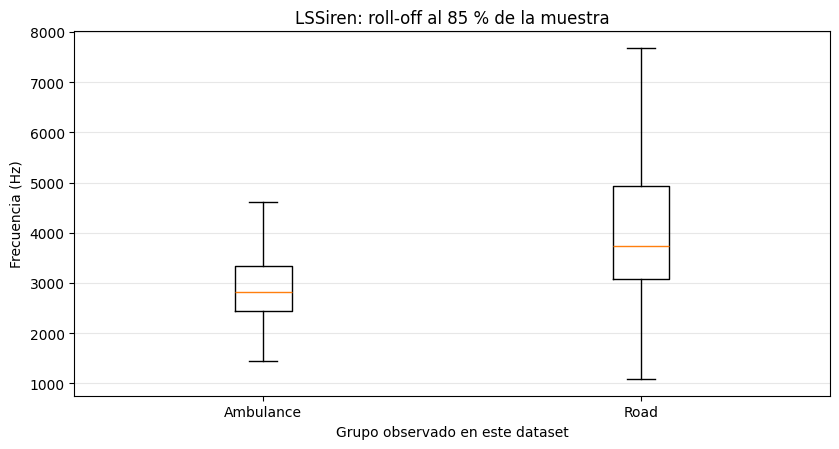

gráfico: /kaggle/working/dataset_eda/plots/rolloff_lssiren.png


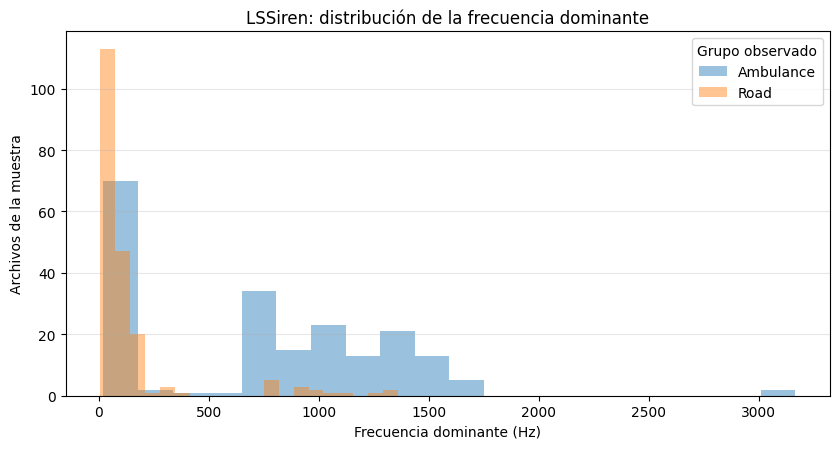

gráfico: /kaggle/working/dataset_eda/plots/dominant_hist_lssiren.png


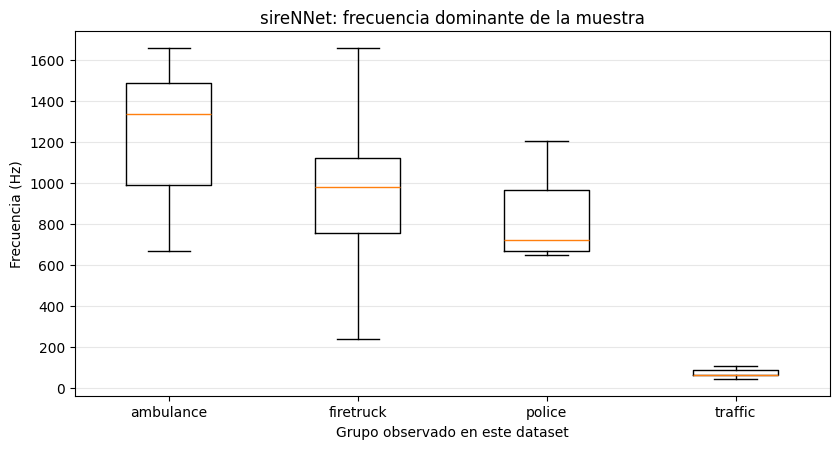

gráfico: /kaggle/working/dataset_eda/plots/dominant_sirennet.png


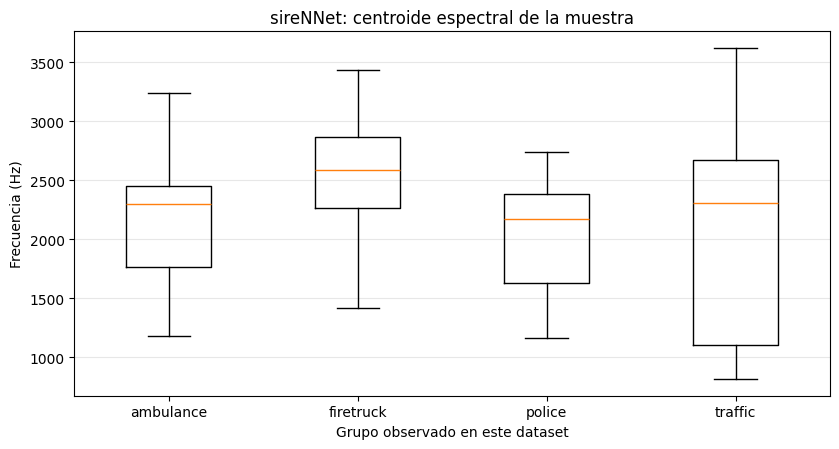

gráfico: /kaggle/working/dataset_eda/plots/centroid_sirennet.png


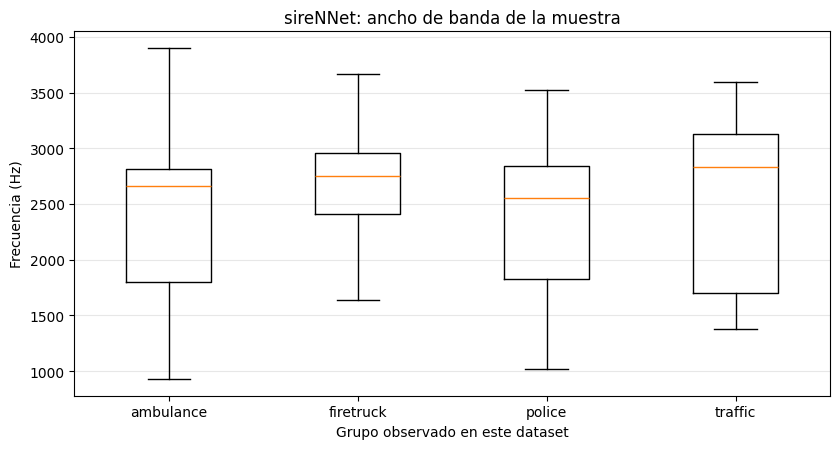

gráfico: /kaggle/working/dataset_eda/plots/bandwidth_sirennet.png


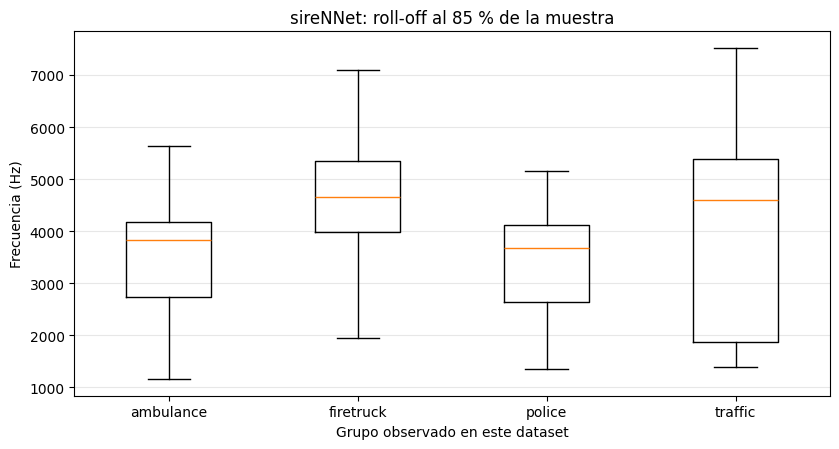

gráfico: /kaggle/working/dataset_eda/plots/rolloff_sirennet.png


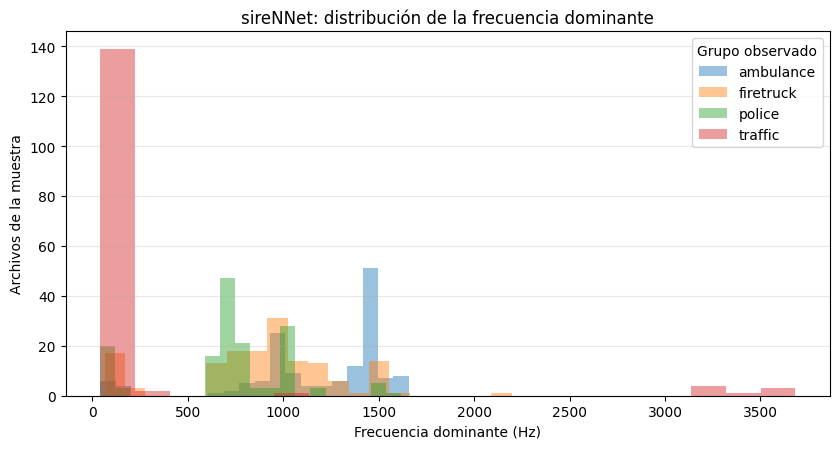

gráfico: /kaggle/working/dataset_eda/plots/dominant_hist_sirennet.png
La frecuencia dominante es el bin de mayor magnitud media, sin la componente DC. No identifica por sí sola una sirena.
En LSSiren el Nyquist cambia con la tasa de muestreo, así que un valor en hertz no es equivalente entre tasas.


In [17]:
def section_spectral() -> None:
    features = ensure_features()
    dominant = numeric_summary(features, ["dominant_frequency"], ["dataset", "analysis_group"])
    centroid = numeric_summary(features, ["spectral_centroid_mean"], ["dataset", "analysis_group"])
    bandwidth = numeric_summary(features, ["spectral_bandwidth_mean"], ["dataset", "analysis_group"])
    rolloff = numeric_summary(features, ["spectral_rolloff_mean"], ["dataset", "analysis_group"])
    flux = numeric_summary(features, ["spectral_flux_mean", "spectral_flatness_mean"], ["dataset", "analysis_group"])
    export_table(dominant, "dominant_frequency_statistics.csv")
    export_table(centroid, "spectral_centroid_statistics.csv")
    export_table(bandwidth, "spectral_bandwidth_statistics.csv")
    export_table(rolloff, "rolloff_statistics.csv")
    export_table(flux, "spectral_flux_statistics.csv")
    spectral = pd.concat([dominant, centroid, bandwidth, rolloff, flux], ignore_index=True)
    export_table(spectral, "tabla_3_4_frecuenciales.csv")
    STATE["spectral_stats"] = spectral
    for dataset, group in features.groupby("dataset"):
        slug = group["dataset_id"].iloc[0]
        plot_box(group, "dominant_frequency", f"{dataset}: frecuencia dominante de la muestra", "Frecuencia (Hz)", f"dominant_{slug}.png")
        plot_box(group, "spectral_centroid_mean", f"{dataset}: centroide espectral de la muestra", "Frecuencia (Hz)", f"centroid_{slug}.png", "fig_3_5_centroid.png" if slug == "lssiren" else None)
        plot_box(group, "spectral_bandwidth_mean", f"{dataset}: ancho de banda de la muestra", "Frecuencia (Hz)", f"bandwidth_{slug}.png")
        plot_box(group, "spectral_rolloff_mean", f"{dataset}: roll-off al 85 % de la muestra", "Frecuencia (Hz)", f"rolloff_{slug}.png")
        fig, ax = plt.subplots(figsize=(8.5, 4.6))
        for label, subgroup in group.groupby("analysis_group"):
            values = pd.to_numeric(subgroup["dominant_frequency"], errors="coerce").dropna()
            if values.empty:
                continue
            ax.hist(values, bins=20, alpha=0.45, label=str(label))
        style_ax(ax, f"{dataset}: distribución de la frecuencia dominante", "Frecuencia dominante (Hz)", "Archivos de la muestra")
        ax.legend(title="Grupo observado")
        save_figure(fig, f"dominant_hist_{slug}.png")
    print("La frecuencia dominante es el bin de mayor magnitud media, sin la componente DC. No identifica por sí sola una sirena.")
    print("En LSSiren el Nyquist cambia con la tasa de muestreo, así que un valor en hertz no es equivalente entre tasas.")

section_spectral()


## 10. EDA tiempo-frecuencia

Espectrograma, log-Mel y mapa de 13 MFCC de los mismos ejemplos de la sección 08. Sirven para inspección visual. Todavía no son la entrada de un modelo.


CANDIDATO PARA TESIS: /kaggle/working/dataset_eda/plots/thesis/fig_3_6_espectrograma.png


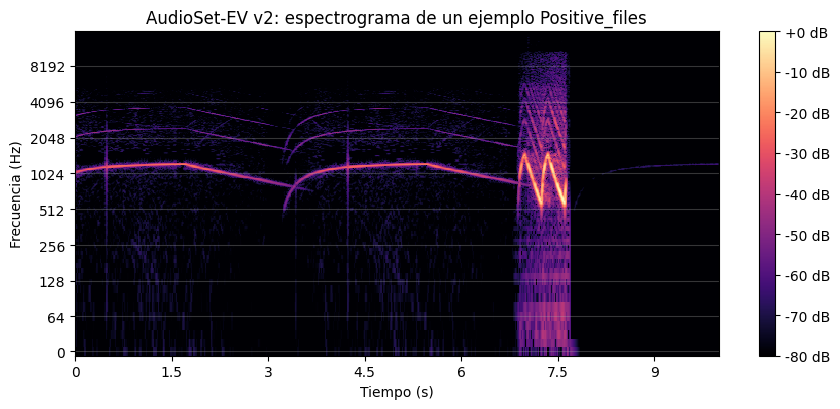

gráfico: /kaggle/working/dataset_eda/plots/spectrograms/AudioSet-EV_v2_Positive_files.png


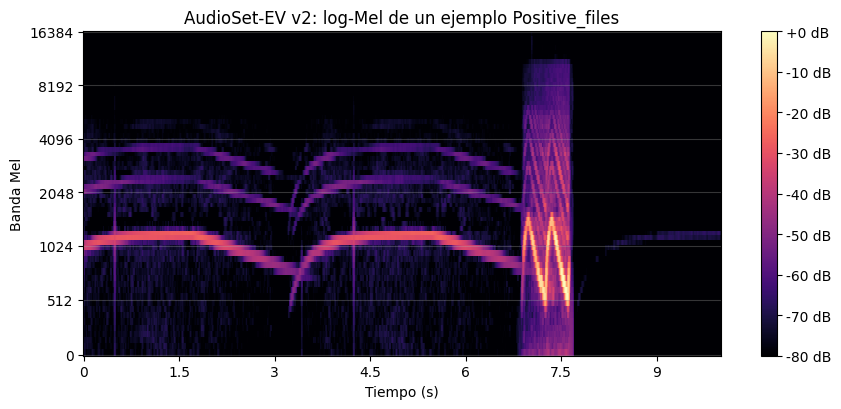

gráfico: /kaggle/working/dataset_eda/plots/spectrograms/logmel_AudioSet-EV_v2_Positive_files.png


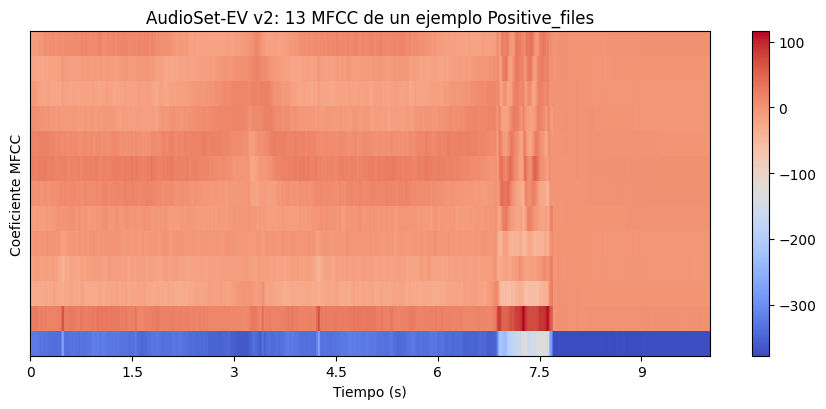

gráfico: /kaggle/working/dataset_eda/plots/spectrograms/mfcc_AudioSet-EV_v2_Positive_files.png


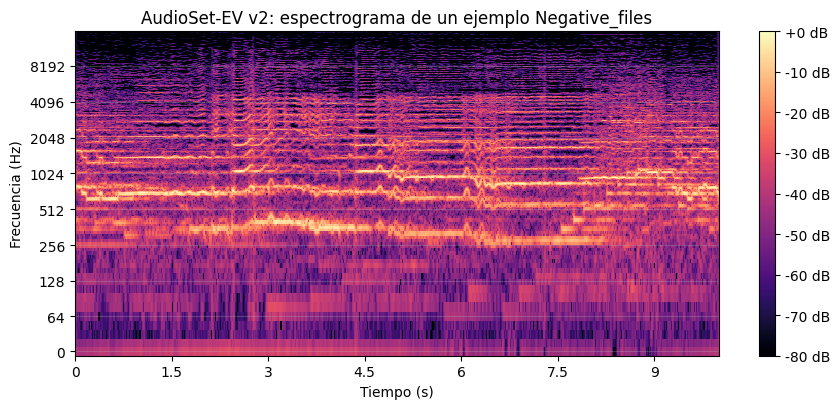

gráfico: /kaggle/working/dataset_eda/plots/spectrograms/AudioSet-EV_v2_Negative_files.png


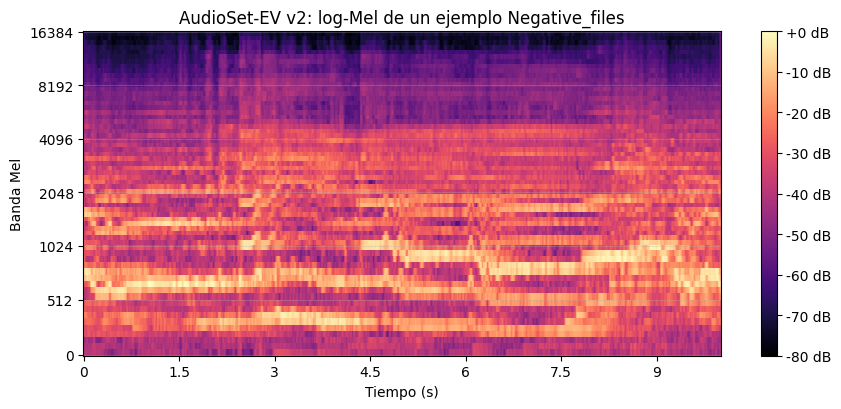

gráfico: /kaggle/working/dataset_eda/plots/spectrograms/logmel_AudioSet-EV_v2_Negative_files.png


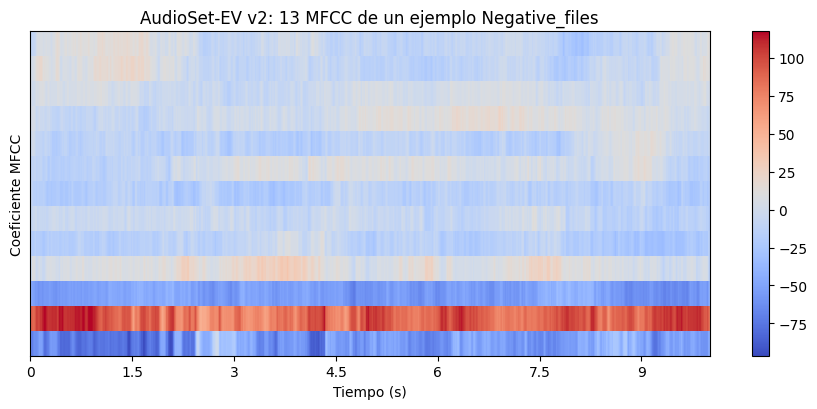

gráfico: /kaggle/working/dataset_eda/plots/spectrograms/mfcc_AudioSet-EV_v2_Negative_files.png


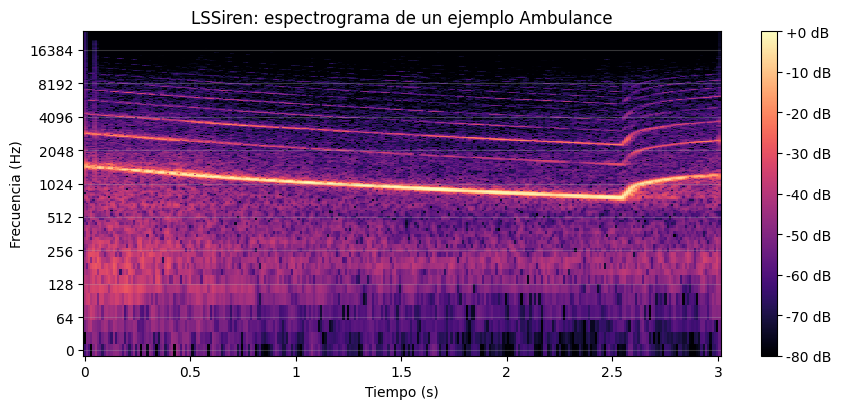

gráfico: /kaggle/working/dataset_eda/plots/spectrograms/LSSiren_Ambulance.png


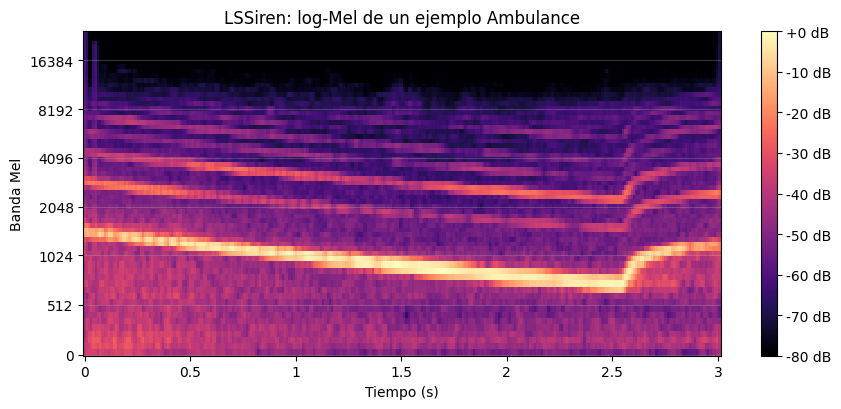

gráfico: /kaggle/working/dataset_eda/plots/spectrograms/logmel_LSSiren_Ambulance.png


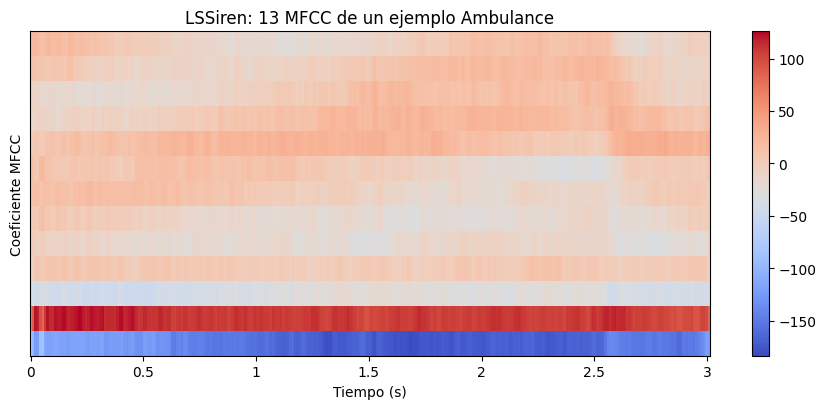

gráfico: /kaggle/working/dataset_eda/plots/spectrograms/mfcc_LSSiren_Ambulance.png


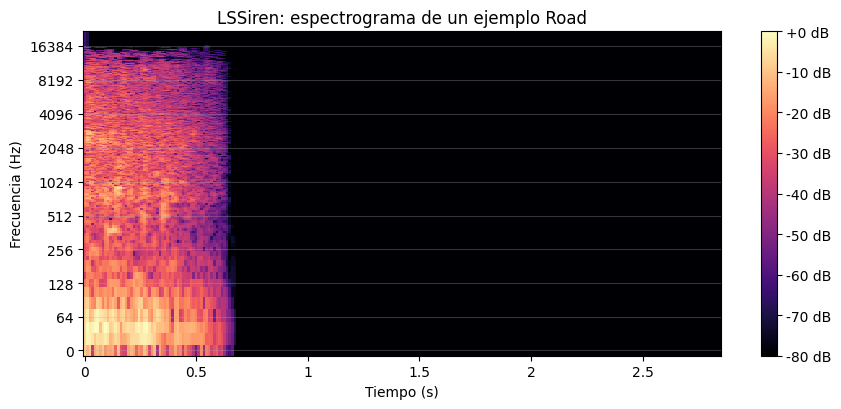

gráfico: /kaggle/working/dataset_eda/plots/spectrograms/LSSiren_Road.png


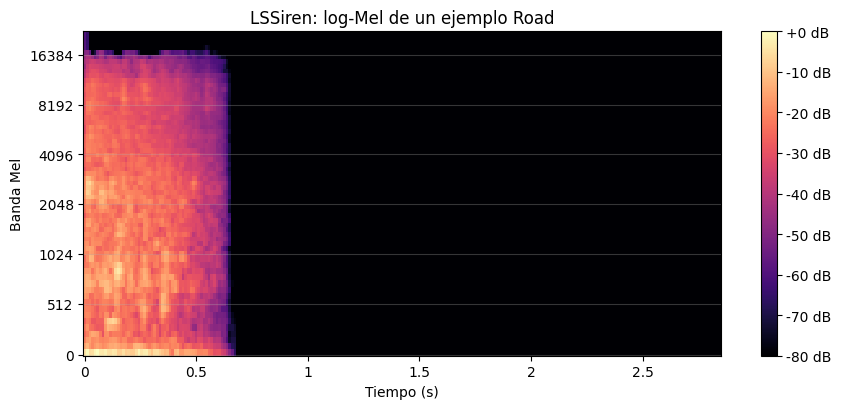

gráfico: /kaggle/working/dataset_eda/plots/spectrograms/logmel_LSSiren_Road.png


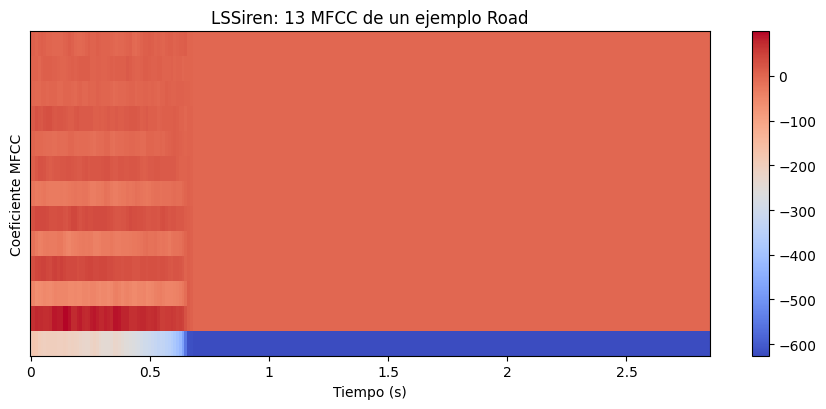

gráfico: /kaggle/working/dataset_eda/plots/spectrograms/mfcc_LSSiren_Road.png


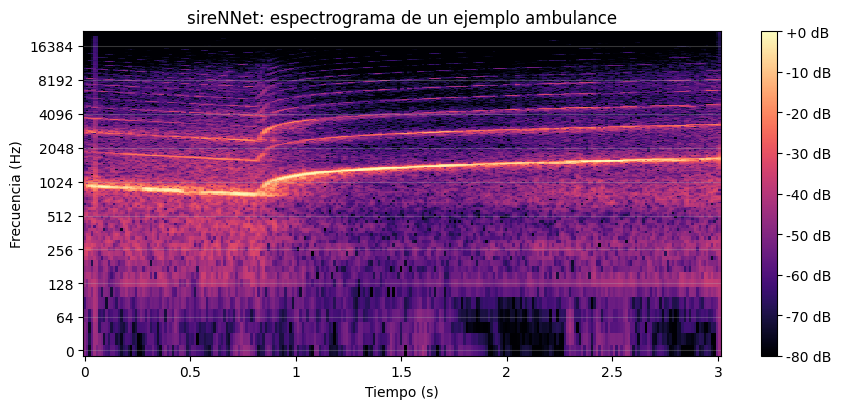

gráfico: /kaggle/working/dataset_eda/plots/spectrograms/sireNNet_ambulance.png


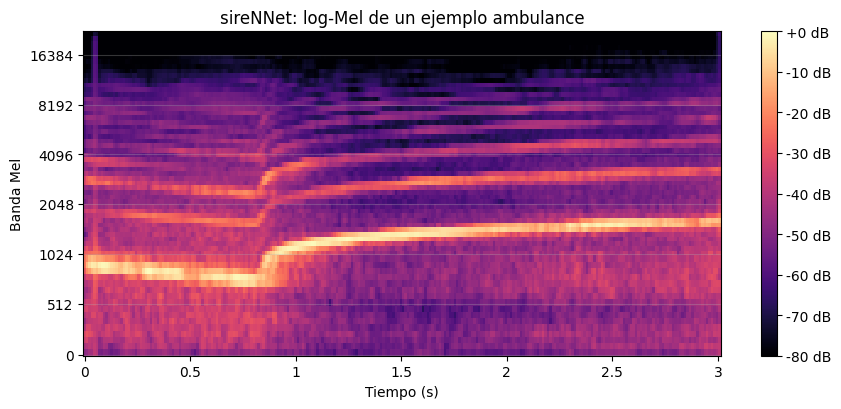

gráfico: /kaggle/working/dataset_eda/plots/spectrograms/logmel_sireNNet_ambulance.png


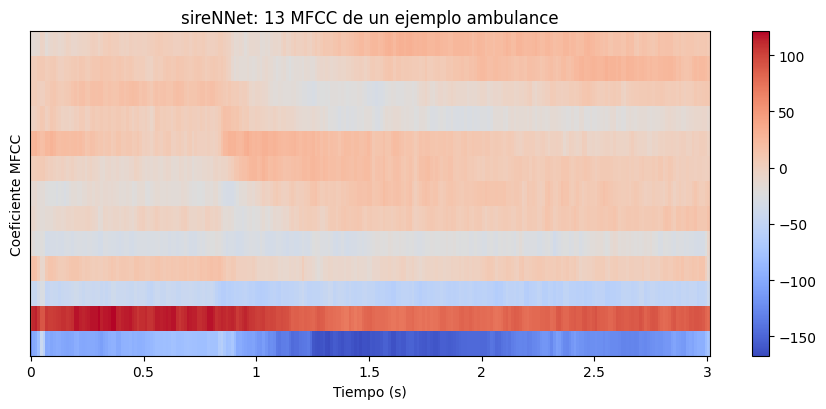

gráfico: /kaggle/working/dataset_eda/plots/spectrograms/mfcc_sireNNet_ambulance.png


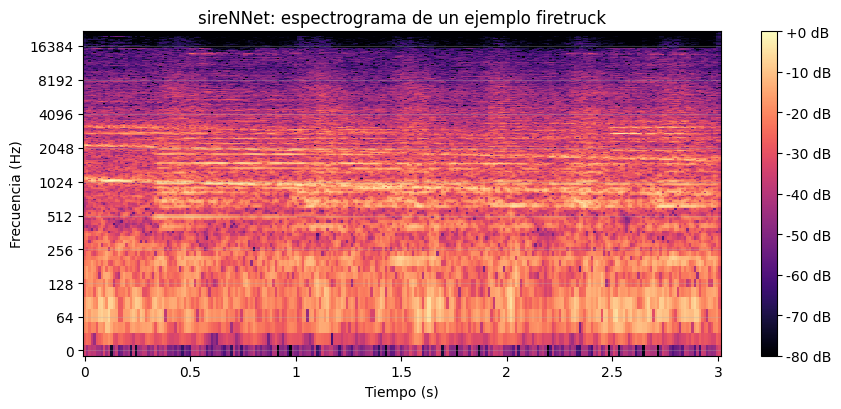

gráfico: /kaggle/working/dataset_eda/plots/spectrograms/sireNNet_firetruck.png


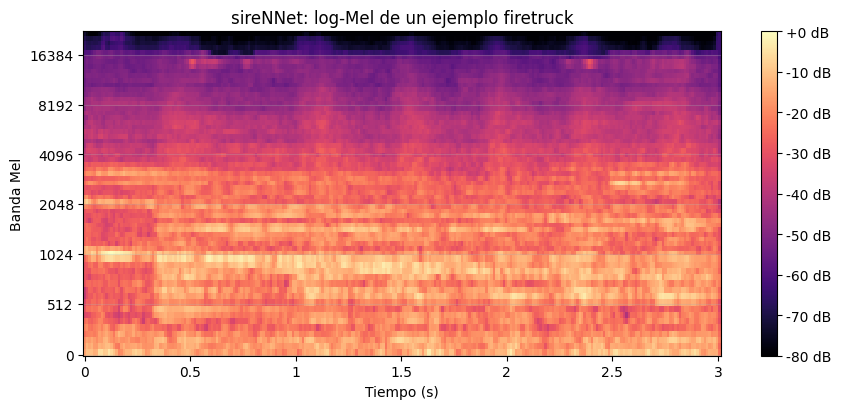

gráfico: /kaggle/working/dataset_eda/plots/spectrograms/logmel_sireNNet_firetruck.png


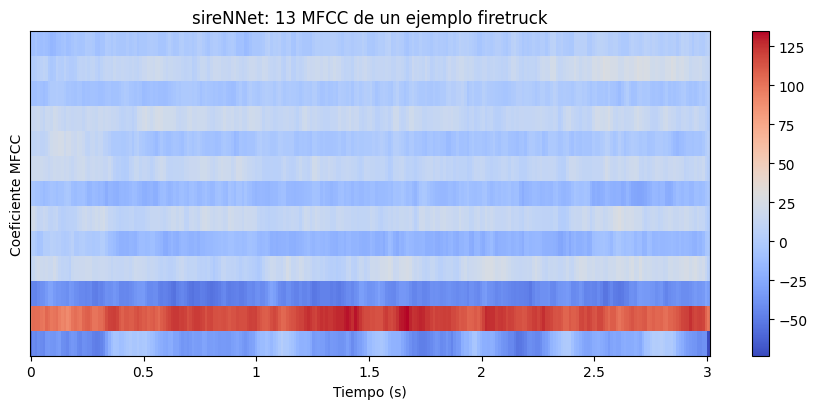

gráfico: /kaggle/working/dataset_eda/plots/spectrograms/mfcc_sireNNet_firetruck.png


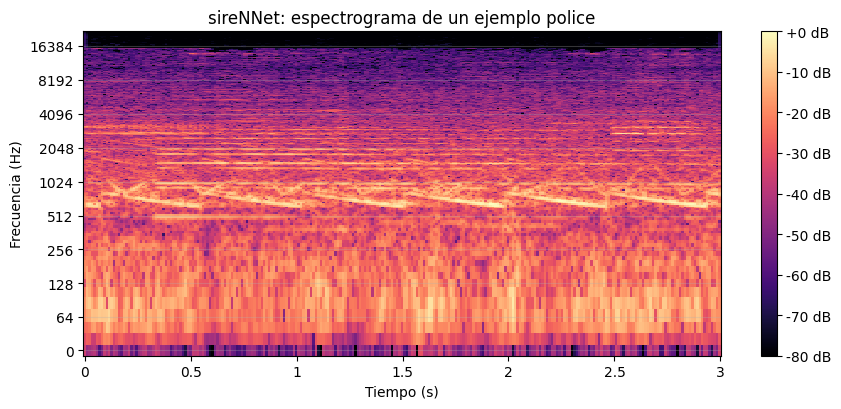

gráfico: /kaggle/working/dataset_eda/plots/spectrograms/sireNNet_police.png


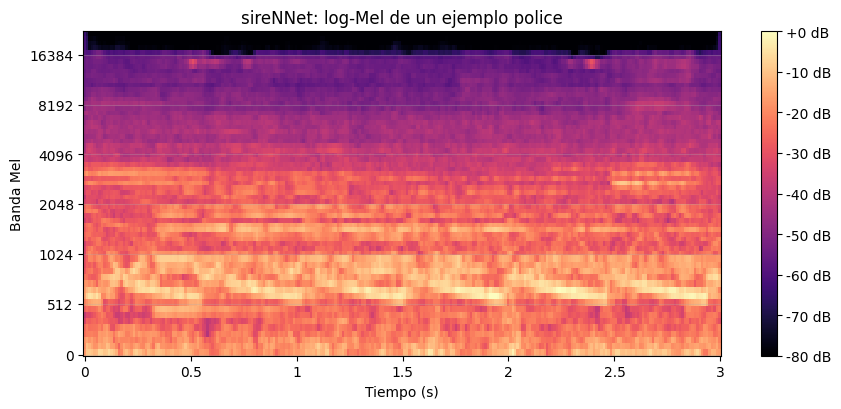

gráfico: /kaggle/working/dataset_eda/plots/spectrograms/logmel_sireNNet_police.png


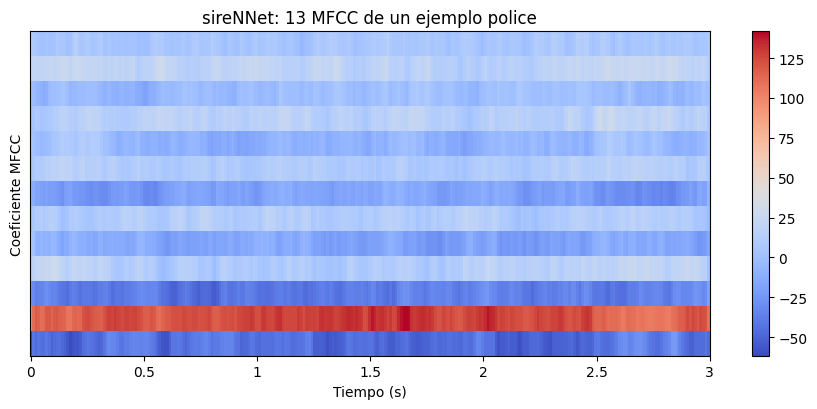

gráfico: /kaggle/working/dataset_eda/plots/spectrograms/mfcc_sireNNet_police.png


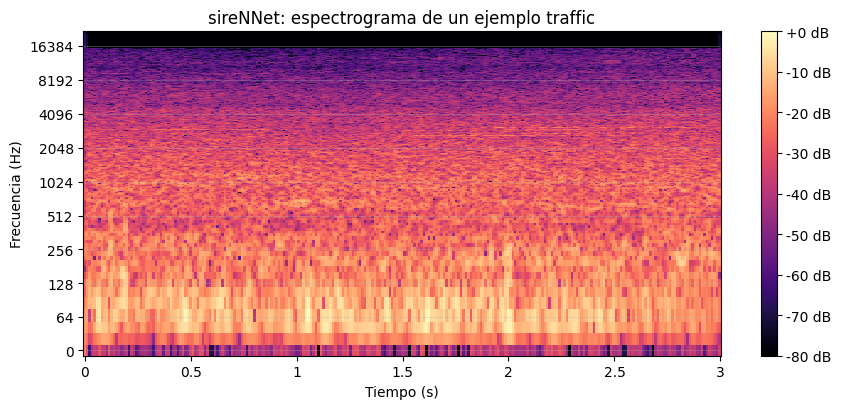

gráfico: /kaggle/working/dataset_eda/plots/spectrograms/sireNNet_traffic.png


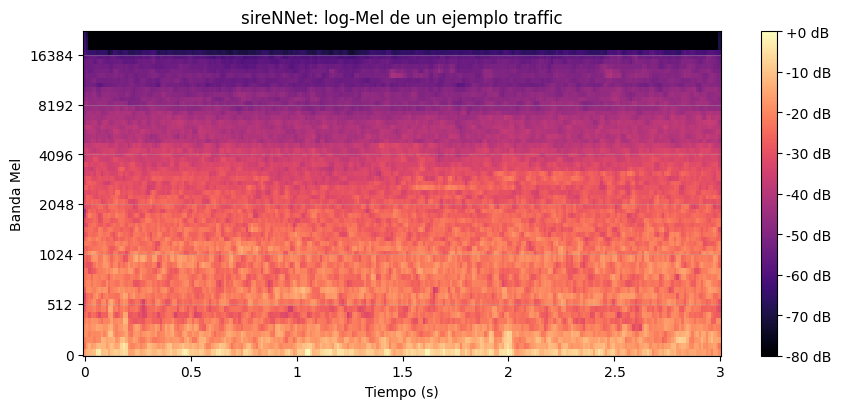

gráfico: /kaggle/working/dataset_eda/plots/spectrograms/logmel_sireNNet_traffic.png


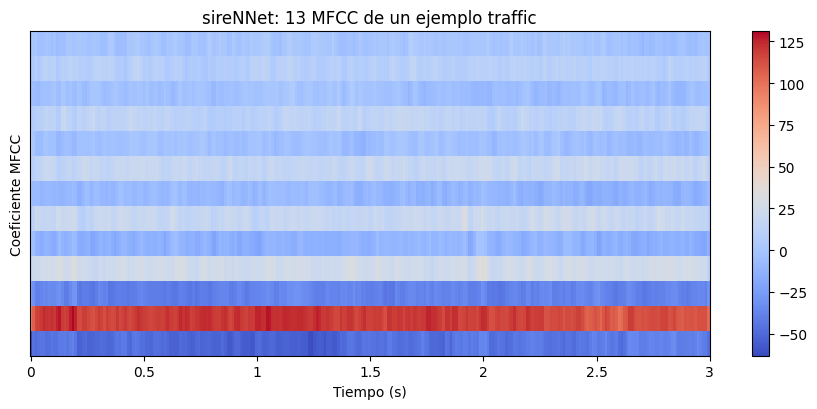

gráfico: /kaggle/working/dataset_eda/plots/spectrograms/mfcc_sireNNet_traffic.png


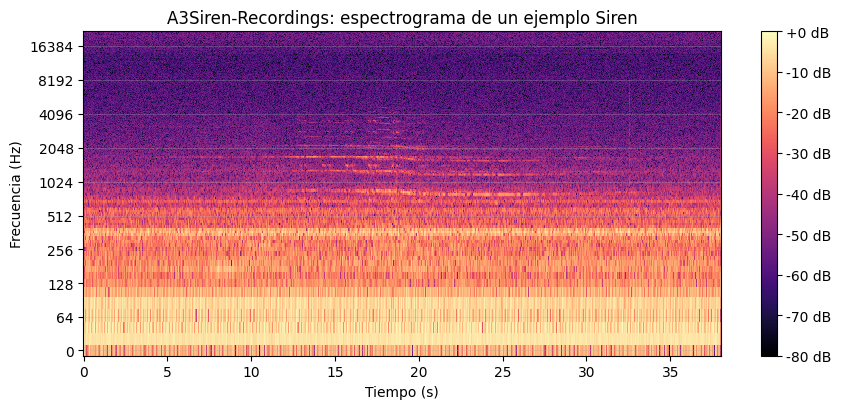

gráfico: /kaggle/working/dataset_eda/plots/spectrograms/A3Siren-Recordings_Siren.png


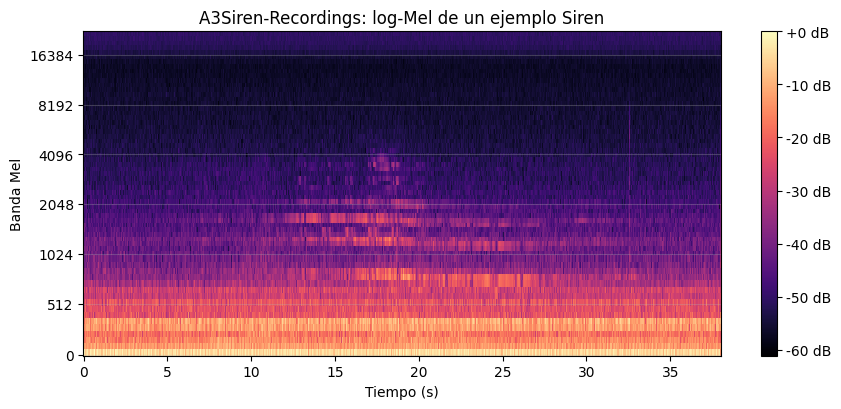

gráfico: /kaggle/working/dataset_eda/plots/spectrograms/logmel_A3Siren-Recordings_Siren.png


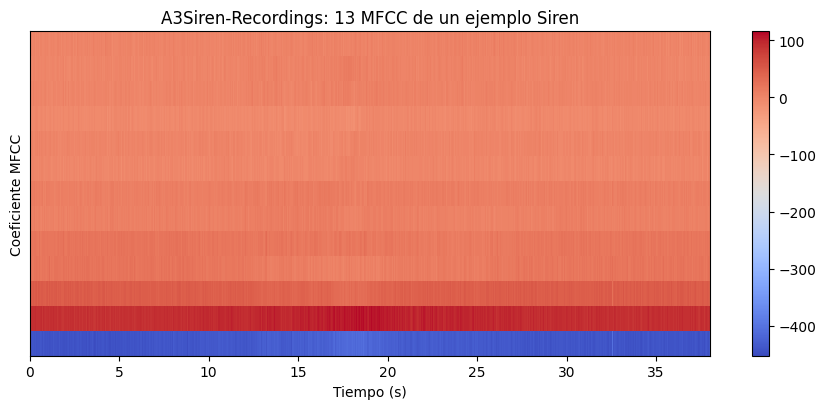

gráfico: /kaggle/working/dataset_eda/plots/spectrograms/mfcc_A3Siren-Recordings_Siren.png


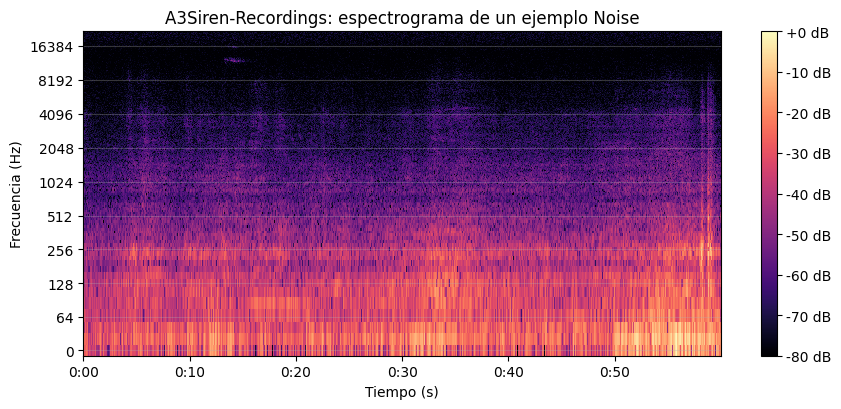

gráfico: /kaggle/working/dataset_eda/plots/spectrograms/A3Siren-Recordings_Noise.png


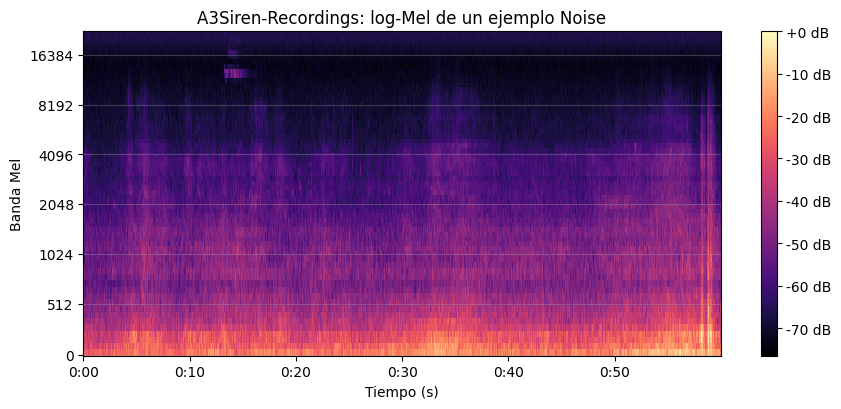

gráfico: /kaggle/working/dataset_eda/plots/spectrograms/logmel_A3Siren-Recordings_Noise.png


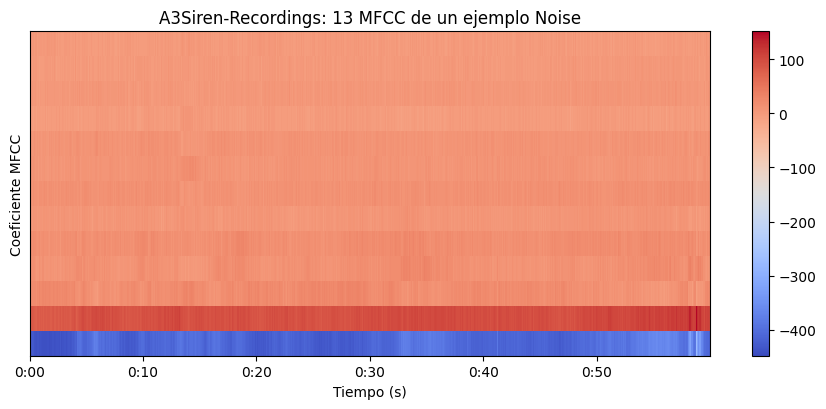

gráfico: /kaggle/working/dataset_eda/plots/spectrograms/mfcc_A3Siren-Recordings_Noise.png
Cada espectrograma, log-Mel y mapa MFCC es un ejemplo de la muestra. No es la entrada de un modelo.


In [19]:
def section_time_frequency() -> None:
    features = ensure_features()
    examples = pick_examples(features)
    for pick in examples.itertuples(index=False):
        waveform, sr, _mix = load_audio(Path(pick.absolute_path))
        spectrum = np.abs(librosa.stft(waveform, n_fft=N_FFT, hop_length=HOP_LENGTH, win_length=WIN_LENGTH, window=WINDOW))
        fig, ax = plt.subplots(figsize=(9, 4.2))
        image = librosa.display.specshow(librosa.amplitude_to_db(spectrum, ref=np.max), sr=sr, hop_length=HOP_LENGTH, x_axis="time", y_axis="log", ax=ax)
        style_ax(ax, f"{pick.dataset}: espectrograma de un ejemplo {pick.analysis_group}", "Tiempo (s)", "Frecuencia (Hz)")
        fig.colorbar(image, ax=ax, format="%+2.0f dB")
        save_figure(fig, f"spectrograms/{pick.dataset}_{pick.analysis_group}.png".replace(" ", "_"), "fig_3_6_espectrograma.png" if pick.dataset == "AudioSet-EV v2" and pick.analysis_group == "Positive_files" else None)
        mel = librosa.feature.melspectrogram(y=waveform, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH, win_length=WIN_LENGTH, n_mels=N_MELS, fmin=FMIN, fmax=float(sr) / 2)
        fig, ax = plt.subplots(figsize=(9, 4.2))
        image = librosa.display.specshow(librosa.power_to_db(mel, ref=np.max), sr=sr, hop_length=HOP_LENGTH, x_axis="time", y_axis="mel", fmin=FMIN, ax=ax)
        style_ax(ax, f"{pick.dataset}: log-Mel de un ejemplo {pick.analysis_group}", "Tiempo (s)", "Banda Mel")
        fig.colorbar(image, ax=ax, format="%+2.0f dB")
        save_figure(fig, f"spectrograms/logmel_{pick.dataset}_{pick.analysis_group}.png".replace(" ", "_"))
        mfcc = librosa.feature.mfcc(y=waveform, sr=sr, n_mfcc=N_MFCC, n_fft=N_FFT, hop_length=HOP_LENGTH, win_length=WIN_LENGTH, n_mels=N_MELS, fmin=FMIN, fmax=float(sr) / 2)
        fig, ax = plt.subplots(figsize=(9, 4.2))
        image = librosa.display.specshow(mfcc, sr=sr, hop_length=HOP_LENGTH, x_axis="time", ax=ax)
        style_ax(ax, f"{pick.dataset}: 13 MFCC de un ejemplo {pick.analysis_group}", "Tiempo (s)", "Coeficiente MFCC")
        fig.colorbar(image, ax=ax)
        save_figure(fig, f"spectrograms/mfcc_{pick.dataset}_{pick.analysis_group}.png".replace(" ", "_"))
    print("Cada espectrograma, log-Mel y mapa MFCC es un ejemplo de la muestra. No es la entrada de un modelo.")

section_time_frequency()


## 11. EDA de características acústicas

Tabla consolidada de la muestra y resumen de los 13 MFCC. Los MFCC no quedan elegidos como características definitivas.


In [20]:
def section_acoustic_features() -> None:
    features = ensure_features()
    keep = [
        "dataset", "label", "label_raw", "analysis_group", "relative_path", "absolute_path", "track_id", "logical_unit",
        "sampling_rate_hz", "channels", "nyquist_hz", "analysis_mix", "window_exceeds_duration", "sha256", "duration",
        "rms_mean", "rms_std", "peak_amplitude", "crest_factor", "clipping_ratio", "silence_ratio",
        "zcr_mean", "zcr_median", "dominant_frequency", "spectral_centroid_mean", "spectral_bandwidth_mean",
        "spectral_rolloff_mean", "spectral_flux_mean", "spectral_flatness_mean",
    ] + [f"mfcc_{i}_mean" for i in range(1, 14)] + ["feature_error"]
    export_frame = features[[column for column in keep if column in features.columns]]
    export_table(export_frame, "eda_feature_sample.csv")
    export_table(export_frame, "data/eda_feature_sample.csv")
    mfcc_cols = [f"mfcc_{i}_mean" for i in range(1, 14)]
    mfcc = numeric_summary(features, mfcc_cols, ["dataset", "analysis_group"])
    export_table(mfcc, "mfcc_statistics.csv")
    energy = STATE.get("energy_stats", numeric_summary(features, ["rms_mean", "rms_std", "peak_amplitude", "crest_factor", "clipping_ratio", "silence_ratio"], ["dataset", "analysis_group"]))
    zcr = STATE.get("zcr_stats", numeric_summary(features, ["zcr_mean", "zcr_median"], ["dataset", "analysis_group"]))
    spectral = STATE.get("spectral_stats", numeric_summary(features, ["dominant_frequency", "spectral_centroid_mean", "spectral_bandwidth_mean", "spectral_rolloff_mean", "spectral_flux_mean", "spectral_flatness_mean"], ["dataset", "analysis_group"]))
    export_table(pd.concat([energy, zcr, spectral, mfcc], ignore_index=True), "tabla_3_5_por_clase.csv")
    print("Los MFCC de esta tabla son descriptivos. No quedan elegidos como características definitivas.")

section_acoustic_features()


escrito: /kaggle/working/dataset_eda/eda_feature_sample.csv
escrito: /kaggle/working/dataset_eda/data/eda_feature_sample.csv
escrito: /kaggle/working/dataset_eda/mfcc_statistics.csv
escrito: /kaggle/working/dataset_eda/tabla_3_5_por_clase.csv
Los MFCC de esta tabla son descriptivos. No quedan elegidos como características definitivas.


## 12. EDA específico de AudioSet-EV v2

Positive y Negative se comparan como carpetas de este corpus. Los identificadores de `positive_labels` no se traducen a nombres de vehículos. `segment_type` no es una partición train/test del proyecto.


In [21]:
def section_audioset() -> None:
    inventory = STATE["inventory"]
    audioset = inventory[(inventory["dataset_id"] == "audioset_ev") & (inventory["quality_status"] == "OK") & inventory["is_hash_primary"]]
    parsed = audioset["label_raw"].map(parse_audioset_ids)
    combination_counts = audioset["label_raw"].value_counts().rename_axis("label_raw").reset_index(name="files")
    export_table(combination_counts.head(50), "audioset_label_combinations_top50.csv")
    individual = Counter()
    parsed_ok = 0
    for value in parsed:
        if value is None:
            continue
        parsed_ok += 1
        individual.update(value)
    individual_frame = pd.DataFrame({"audioset_id": list(individual), "files": list(individual.values())}).sort_values("files", ascending=False)
    export_table(individual_frame, "audioset_individual_label_counts.csv")
    print(f"AudioSet-EV: combinaciones distintas de positive_labels en archivos primarios utilizables = {audioset['label_raw'].nunique()}. Segmentos cuya lista de IDs se pudo separar = {parsed_ok}.")
    print("No se tradujeron los IDs a nombres de vehículos: no hay un mapping oficial en el input.")
    segments = audioset["segment_type"].fillna("").replace("", "<sin segment_type>").value_counts().rename_axis("segment_type").reset_index(name="primary_files")
    export_table(segments, "audioset_segment_type_counts.csv")
    print("segment_type se conserva como metadata de AudioSet. No es una partición train/test de este proyecto.")
    show_df(segments, n=10)

section_audioset()


escrito: /kaggle/working/dataset_eda/audioset_label_combinations_top50.csv
escrito: /kaggle/working/dataset_eda/audioset_individual_label_counts.csv
AudioSet-EV: combinaciones distintas de positive_labels en archivos primarios utilizables = 7745. Segmentos cuya lista de IDs se pudo separar = 28794.
No se tradujeron los IDs a nombres de vehículos: no hay un mapping oficial en el input.
escrito: /kaggle/working/dataset_eda/audioset_segment_type_counts.csv
segment_type se conserva como metadata de AudioSet. No es una partición train/test de este proyecto.
filas: 3 | columnas: 2


,segment_type,primary_files
0,balanced_train,11093
1,eval,10075
2,unbalanced_train,7626


## 13. EDA específico de LSSiren

La comparación por clase se mantiene separada de la comparación por sampling rate y por número de canales. Las columnas precalculadas del CSV no sustituyen el cálculo de esta notebook.


In [23]:
def section_lssiren() -> None:
    features = ensure_features()
    lssiren = features[features["dataset"] == "LSSiren"]
    export_table(numeric_summary(lssiren, FEATURE_COLUMNS, ["analysis_group"]), "lssiren_class_statistics.csv")
    export_table(numeric_summary(lssiren, ["rms_mean", "zcr_mean", "spectral_centroid_mean", "dominant_frequency"], ["analysis_group", "sampling_rate_hz"]), "lssiren_sampling_rate_analysis.csv")
    export_table(numeric_summary(lssiren, ["rms_mean", "zcr_mean", "spectral_centroid_mean"], ["analysis_group", "channels"]), "lssiren_channel_analysis.csv")
    precomputed = STATE.get("lssiren_precomputed", {})
    if precomputed:
        ambulance = precomputed["ambulance"]
        file_column = _match_column(list(ambulance.columns), ["filename"])
        mfcc_column = _match_column(list(ambulance.columns), ["mfcc1"])
        if file_column and mfcc_column:
            joined = lssiren.merge(ambulance[[file_column, mfcc_column]], left_on="filename", right_on=file_column, how="inner")
            if not joined.empty:
                diff = (pd.to_numeric(joined["mfcc_1_mean"], errors="coerce") - pd.to_numeric(joined[mfcc_column], errors="coerce")).abs()
                print(f"LSSiren: diferencia absoluta mediana entre mfcc_1 recalculado y mfcc1 del CSV de ambulancia = {float(diff.median()) if diff.notna().any() else 'no medible'}.")
                print("El cálculo de esta notebook no se sustituye por las columnas precalculadas del CSV.")
    print("Las comparaciones por tasa y por número de canales se mantienen separadas de la comparación por clase.")

section_lssiren()


escrito: /kaggle/working/dataset_eda/lssiren_class_statistics.csv
escrito: /kaggle/working/dataset_eda/lssiren_sampling_rate_analysis.csv
escrito: /kaggle/working/dataset_eda/lssiren_channel_analysis.csv
LSSiren: diferencia absoluta mediana entre mfcc_1 recalculado y mfcc1 del CSV de ambulancia = 145.0705530865384.
El cálculo de esta notebook no se sustituye por las columnas precalculadas del CSV.
Las comparaciones por tasa y por número de canales se mantienen separadas de la comparación por clase.


## 14. EDA específico de sireNNet

Las cuatro carpetas se comparan de forma descriptiva. No se declara que las clases sean separables.


escrito: /kaggle/working/dataset_eda/sirennet_class_statistics.csv
escrito: /kaggle/working/dataset_eda/sirennet_pairwise_descriptive.csv
sireNNet: las seis comparaciones de carpetas son descriptivas. No hay clasificación.
CANDIDATO PARA TESIS: /kaggle/working/dataset_eda/plots/thesis/fig_3_7_sirennet.png


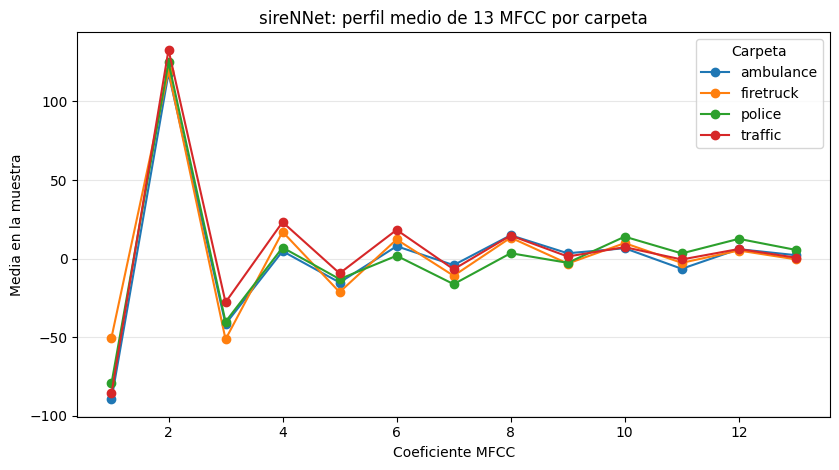

gráfico: /kaggle/working/dataset_eda/plots/sirennet_mfcc_profile.png


In [24]:
def section_sirennet() -> None:
    features = ensure_features()
    siren = features[features["dataset"] == "sireNNet"]
    export_table(numeric_summary(siren, FEATURE_COLUMNS, ["analysis_group"]), "sirennet_class_statistics.csv")
    pair_rows = []
    pair_features = ["rms_mean", "zcr_mean", "dominant_frequency", "spectral_centroid_mean", "spectral_bandwidth_mean", "spectral_rolloff_mean", "spectral_flux_mean"]
    classes = sorted(siren["analysis_group"].dropna().unique())
    for left_index, left in enumerate(classes):
        for right in classes[left_index + 1:]:
            for feature in pair_features:
                phrase, confidence = distribution_phrase(siren.loc[siren["analysis_group"] == left, feature], siren.loc[siren["analysis_group"] == right, feature])
                pair_rows.append({"left": left, "right": right, "feature": feature, "descriptive_relation": phrase, "confidence": confidence})
    export_table(pd.DataFrame(pair_rows), "sirennet_pairwise_descriptive.csv")
    print("sireNNet: las seis comparaciones de carpetas son descriptivas. No hay clasificación.")
    fig, ax = plt.subplots(figsize=(8.5, 4.8))
    for label, group in siren.groupby("analysis_group"):
        profile = [float(pd.to_numeric(group[f"mfcc_{i}_mean"], errors="coerce").mean()) for i in range(1, 14)]
        ax.plot(range(1, 14), profile, marker="o", label=str(label))
    style_ax(ax, "sireNNet: perfil medio de 13 MFCC por carpeta", "Coeficiente MFCC", "Media en la muestra")
    ax.legend(title="Carpeta")
    save_figure(fig, "sirennet_mfcc_profile.png", "fig_3_7_sirennet.png")


def section_a3() -> None:
    features = ensure_features()
    a3 = features[features["dataset"] == "A3Siren-Recordings"].copy()
    export_table(a3[["track_id", "analysis_group", "relative_path", "rms_mean", "zcr_mean", "peak_amplitude", "spectral_centroid_mean", "spectral_bandwidth_mean", "spectral_rolloff_mean", "spectral_flux_mean", "dominant_frequency"]], "a3siren_channel_statistics.csv")
    track = a3.groupby(["track_id", "analysis_group"], as_index=False)[["rms_mean", "zcr_mean", "peak_amplitude", "spectral_centroid_mean", "spectral_bandwidth_mean", "spectral_rolloff_mean", "spectral_flux_mean", "dominant_frequency"]].median()
    track["aggregation"] = "mediana explícita entre los 8 canales; no sustituye la tabla por canal"
    export_table(track, "a3siren_track_statistics.csv")
    generator = np.random.default_rng(SEED)
    for group_name in ("Siren", "Noise"):
        ids = sorted(a3.loc[a3["analysis_group"] == group_name, "track_id"].unique())
        picks = list(generator.choice(ids, size=min(2, len(ids)), replace=False)) if ids else []
        for track_id in picks:
            subset = a3[a3["track_id"] == track_id].copy()
            subset["channel_sort"] = subset["relative_path"].map(lambda path: int(re.search(r"(\d+)", a3_channel(path, Path(path).name)).group(1)))
            subset = subset.sort_values("channel_sort")
            fig, ax = plt.subplots(figsize=(8.5, 4.6))
            channels = [a3_channel(path, Path(path).name) for path in subset["relative_path"]]
            ax.plot(channels, subset["rms_mean"], marker="o")
            style_ax(ax, f"A3Siren: RMS por canal del track {track_id}", "Canal", "RMS")
            save_figure(fig, f"a3_channel_rms_{track_id}.png", "fig_3_8_a3_canales.png" if group_name == "Siren" and track_id == picks[0] else None)
    print("La tabla por canal se conserva. La mediana entre canales está marcada y no la reemplaza.")

section_sirennet()


## 15. EDA específico de A3Siren

Cada track conserva sus ocho canales. La mediana entre canales se calcula de forma explícita y no reemplaza la tabla por canal.


escrito: /kaggle/working/dataset_eda/a3siren_channel_statistics.csv
escrito: /kaggle/working/dataset_eda/a3siren_track_statistics.csv
CANDIDATO PARA TESIS: /kaggle/working/dataset_eda/plots/thesis/fig_3_8_a3_canales.png


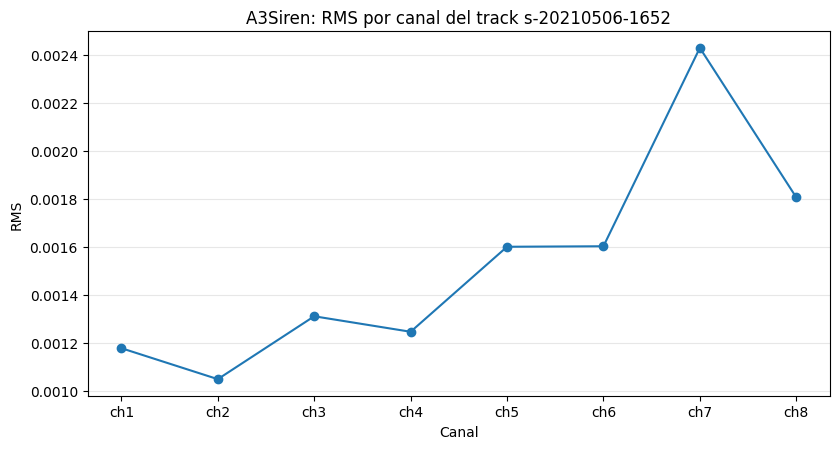

gráfico: /kaggle/working/dataset_eda/plots/a3_channel_rms_s-20210506-1652.png


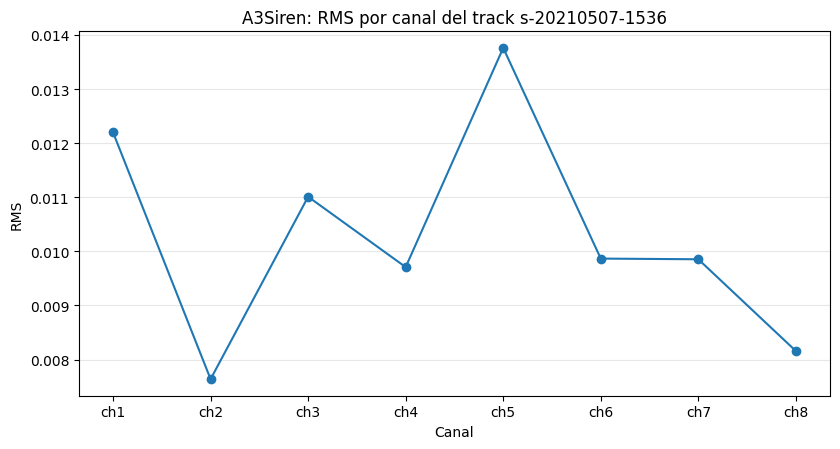

gráfico: /kaggle/working/dataset_eda/plots/a3_channel_rms_s-20210507-1536.png


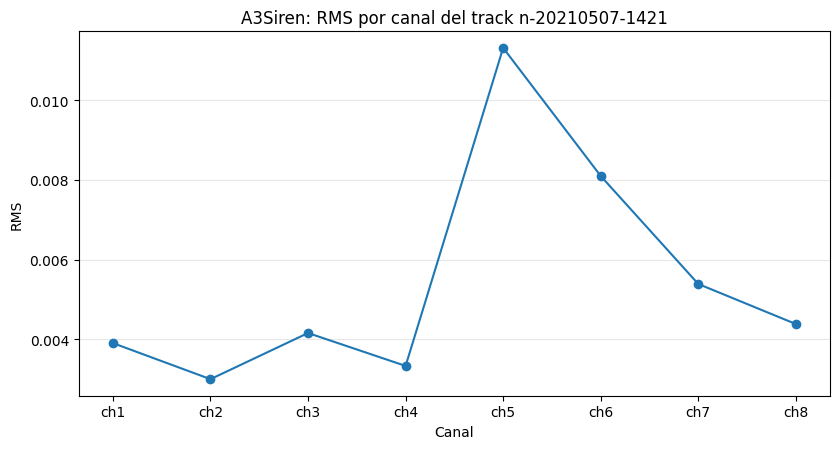

gráfico: /kaggle/working/dataset_eda/plots/a3_channel_rms_n-20210507-1421.png


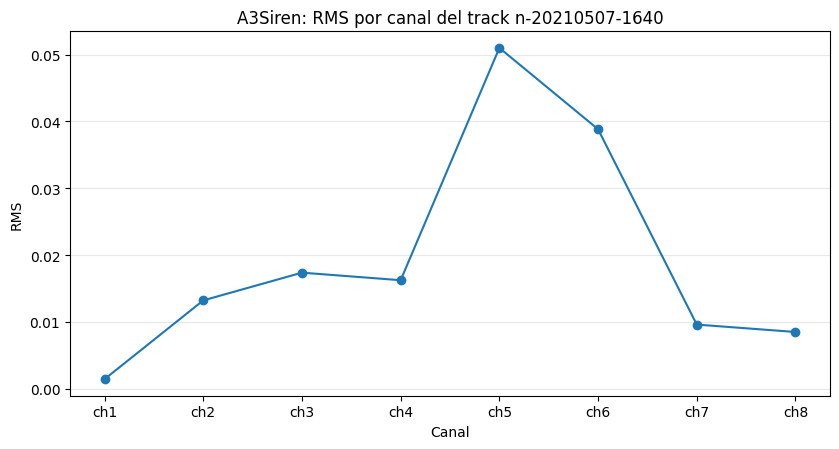

gráfico: /kaggle/working/dataset_eda/plots/a3_channel_rms_n-20210507-1640.png
La tabla por canal se conserva. La mediana entre canales está marcada y no la reemplaza.


In [25]:
def section_a3() -> None:
    features = ensure_features()
    a3 = features[features["dataset"] == "A3Siren-Recordings"].copy()
    export_table(a3[["track_id", "analysis_group", "relative_path", "rms_mean", "zcr_mean", "peak_amplitude", "spectral_centroid_mean", "spectral_bandwidth_mean", "spectral_rolloff_mean", "spectral_flux_mean", "dominant_frequency"]], "a3siren_channel_statistics.csv")
    track = a3.groupby(["track_id", "analysis_group"], as_index=False)[["rms_mean", "zcr_mean", "peak_amplitude", "spectral_centroid_mean", "spectral_bandwidth_mean", "spectral_rolloff_mean", "spectral_flux_mean", "dominant_frequency"]].median()
    track["aggregation"] = "mediana explícita entre los 8 canales; no sustituye la tabla por canal"
    export_table(track, "a3siren_track_statistics.csv")
    generator = np.random.default_rng(SEED)
    for group_name in ("Siren", "Noise"):
        ids = sorted(a3.loc[a3["analysis_group"] == group_name, "track_id"].unique())
        picks = list(generator.choice(ids, size=min(2, len(ids)), replace=False)) if ids else []
        for track_id in picks:
            subset = a3[a3["track_id"] == track_id].copy()
            subset["channel_sort"] = subset["relative_path"].map(lambda path: int(re.search(r"(\d+)", a3_channel(path, Path(path).name)).group(1)))
            subset = subset.sort_values("channel_sort")
            fig, ax = plt.subplots(figsize=(8.5, 4.6))
            channels = [a3_channel(path, Path(path).name) for path in subset["relative_path"]]
            ax.plot(channels, subset["rms_mean"], marker="o")
            style_ax(ax, f"A3Siren: RMS por canal del track {track_id}", "Canal", "RMS")
            save_figure(fig, f"a3_channel_rms_{track_id}.png", "fig_3_8_a3_canales.png" if group_name == "Siren" and track_id == picks[0] else None)
    print("La tabla por canal se conserva. La mediana entre canales está marcada y no la reemplaza.")

section_a3()


## 16. Comparación transversal entre datasets

Los cuatro corpus se comparan sin fusionar sus etiquetas. Una diferencia entre corpus es heterogeneidad observada, no un domain shift confirmado.


escrito: /kaggle/working/dataset_eda/dataset_comparison_statistics.csv
escrito: /kaggle/working/dataset_eda/tabla_3_6_variabilidad_datasets.csv


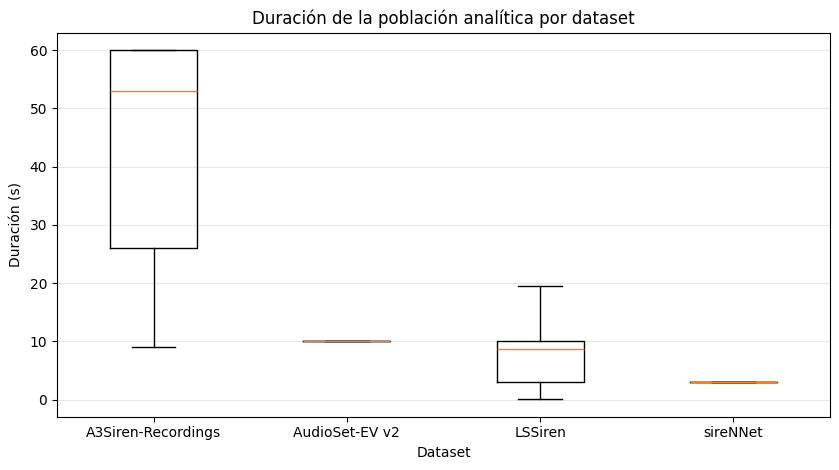

gráfico: /kaggle/working/dataset_eda/plots/comparison_duration.png


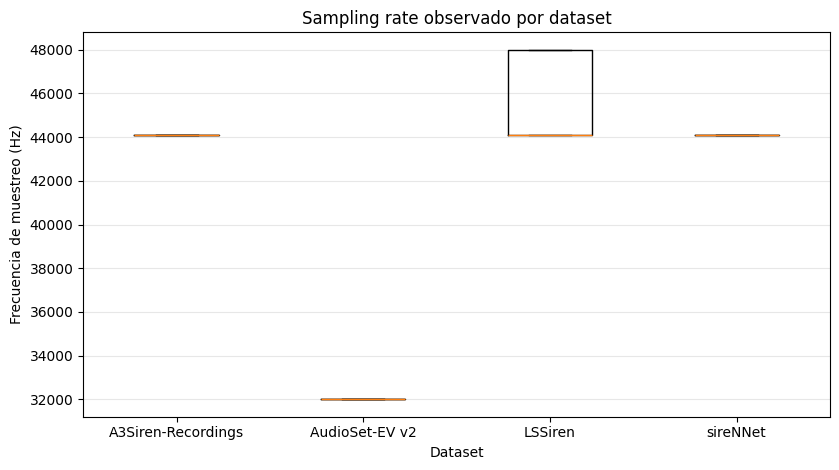

gráfico: /kaggle/working/dataset_eda/plots/comparison_sampling_rate.png


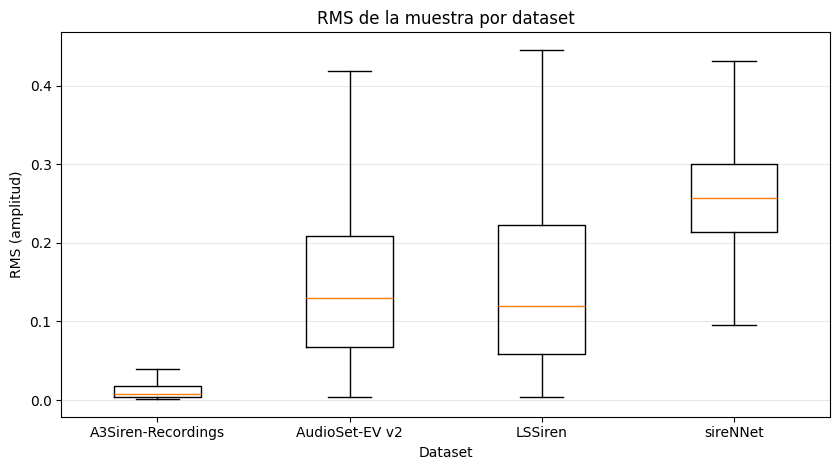

gráfico: /kaggle/working/dataset_eda/plots/comparison_rms.png
CANDIDATO PARA TESIS: /kaggle/working/dataset_eda/plots/thesis/fig_3_9_comparacion_datasets.png


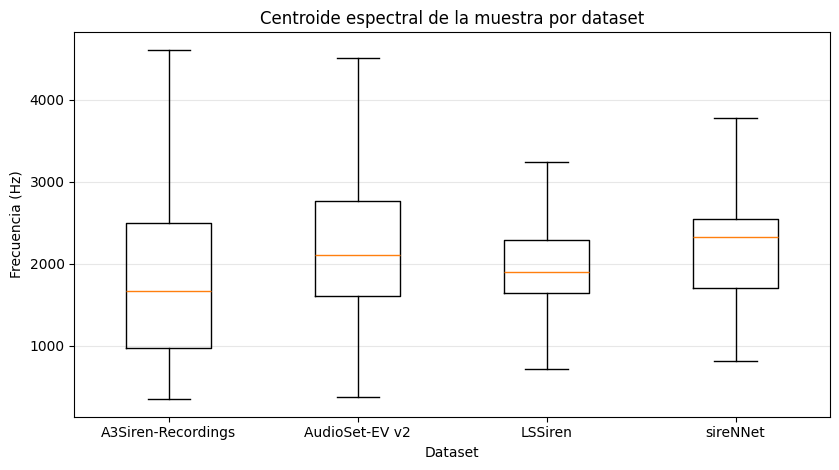

gráfico: /kaggle/working/dataset_eda/plots/comparison_centroid.png


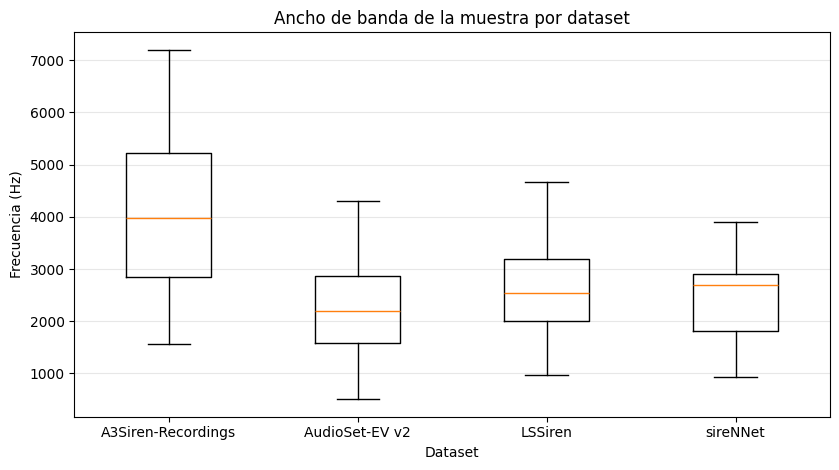

gráfico: /kaggle/working/dataset_eda/plots/comparison_bandwidth.png


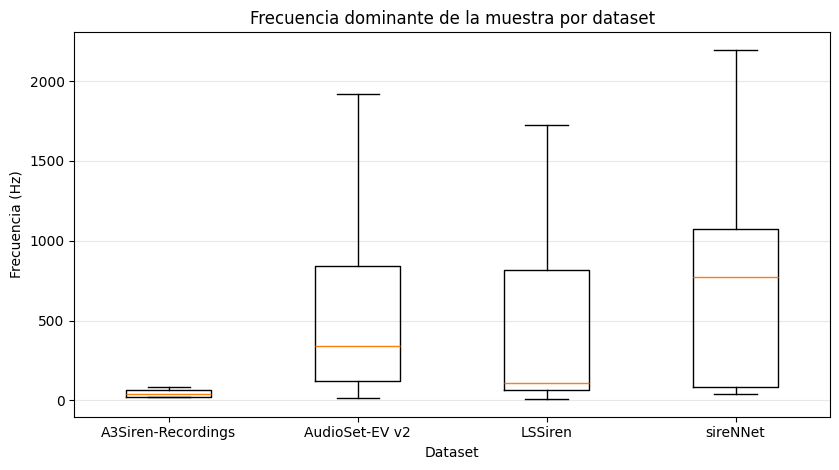

gráfico: /kaggle/working/dataset_eda/plots/comparison_dominant_frequency.png
Una diferencia entre corpus se describe como heterogeneidad. No confirma domain shift.


In [26]:
def section_comparison() -> None:
    features = ensure_features()
    inventory = STATE["inventory"]
    comparison = numeric_summary(features, ["duration", "rms_mean", "zcr_mean", "dominant_frequency", "spectral_centroid_mean", "spectral_bandwidth_mean", "spectral_rolloff_mean", "spectral_flux_mean"], ["dataset"])
    export_table(comparison, "dataset_comparison_statistics.csv")
    export_table(comparison, "tabla_3_6_variabilidad_datasets.csv")
    population_frames = []
    for dataset_id in DATASET_ORDER:
        base = analytic_frame(inventory, dataset_id)
        population_frames.append(base[["dataset", "duration_seconds", "sampling_rate_hz"]])
    population_features = pd.concat(population_frames, ignore_index=True)
    for column, title, ylabel, filename in (
        ("duration_seconds", "Duración de la población analítica por dataset", "Duración (s)", "comparison_duration.png"),
        ("sampling_rate_hz", "Sampling rate observado por dataset", "Frecuencia de muestreo (Hz)", "comparison_sampling_rate.png"),
    ):
        fig, ax = plt.subplots(figsize=(8.5, 4.8))
        data, labels = [], []
        for dataset, group in population_features.groupby("dataset"):
            values = pd.to_numeric(group[column], errors="coerce").dropna()
            if not values.empty:
                data.append(values)
                labels.append(dataset)
        ax.boxplot(data, tick_labels=labels, showfliers=False)
        style_ax(ax, title, "Dataset", ylabel)
        save_figure(fig, filename)
    for column, title, ylabel, filename, thesis in (
        ("rms_mean", "RMS de la muestra por dataset", "RMS (amplitud)", "comparison_rms.png", None),
        ("spectral_centroid_mean", "Centroide espectral de la muestra por dataset", "Frecuencia (Hz)", "comparison_centroid.png", "fig_3_9_comparacion_datasets.png"),
        ("spectral_bandwidth_mean", "Ancho de banda de la muestra por dataset", "Frecuencia (Hz)", "comparison_bandwidth.png", None),
        ("dominant_frequency", "Frecuencia dominante de la muestra por dataset", "Frecuencia (Hz)", "comparison_dominant_frequency.png", None),
    ):
        fig, ax = plt.subplots(figsize=(8.5, 4.8))
        data, labels = [], []
        for dataset, group in features.groupby("dataset"):
            values = pd.to_numeric(group[column], errors="coerce").dropna()
            if not values.empty:
                data.append(values)
                labels.append(dataset)
        if not data:
            plt.close(fig)
            continue
        ax.boxplot(data, tick_labels=labels, showfliers=False)
        style_ax(ax, title, "Dataset", ylabel)
        save_figure(fig, filename, thesis)
    print("Una diferencia entre corpus se describe como heterogeneidad. No confirma domain shift.")

section_comparison()


## 17. Patrones, correlación y anomalías exploratorias

Dispersión entre pares de variables, correlación de Pearson y Spearman, proyección PCA y extremos de la muestra. La estandarización del PCA existe solo en esa copia de visualización. Una anomalía exploratoria no es un error y no se elimina.


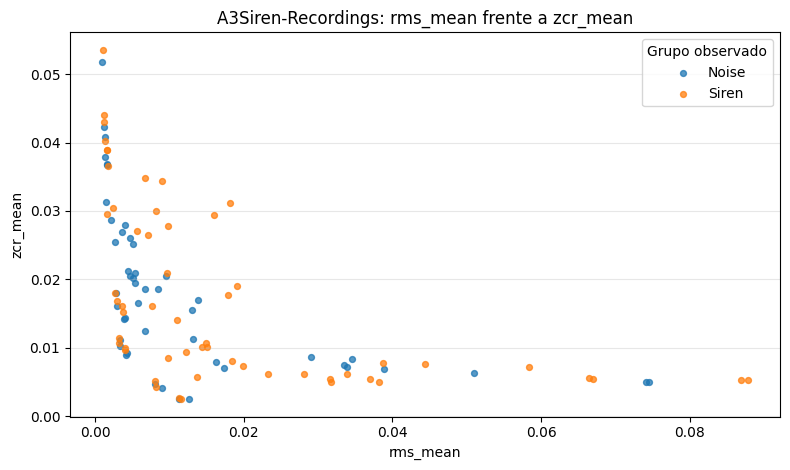

gráfico: /kaggle/working/dataset_eda/plots/scatter_rms_zcr_a3siren.png


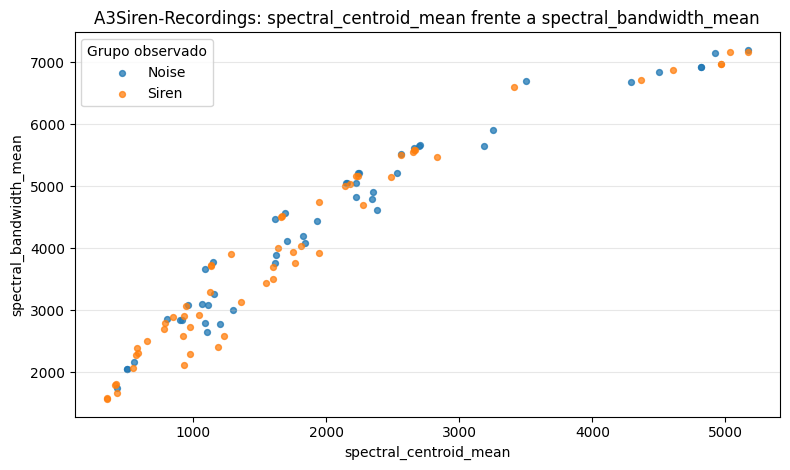

gráfico: /kaggle/working/dataset_eda/plots/scatter_centroid_bandwidth_a3siren.png


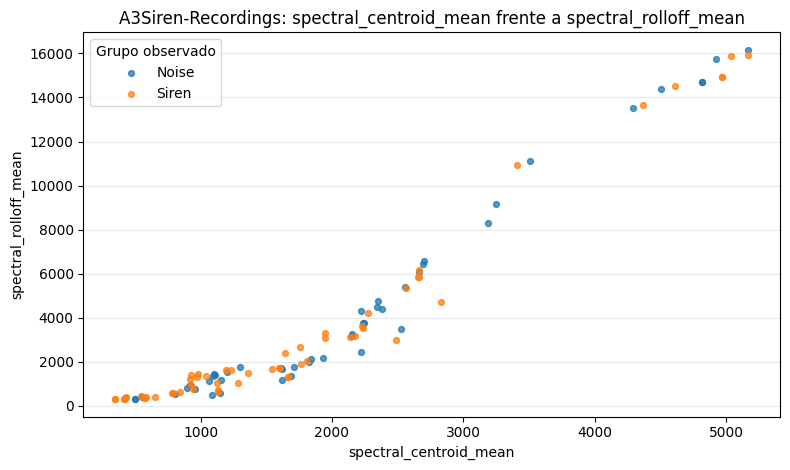

gráfico: /kaggle/working/dataset_eda/plots/scatter_centroid_rolloff_a3siren.png


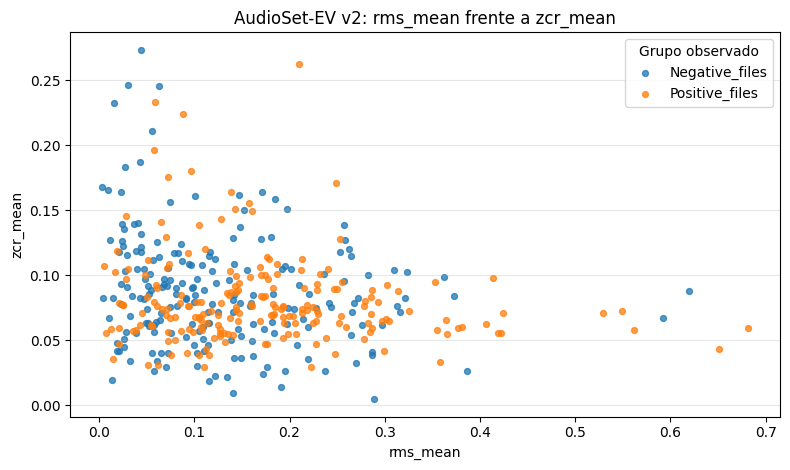

gráfico: /kaggle/working/dataset_eda/plots/scatter_rms_zcr_audioset_ev.png


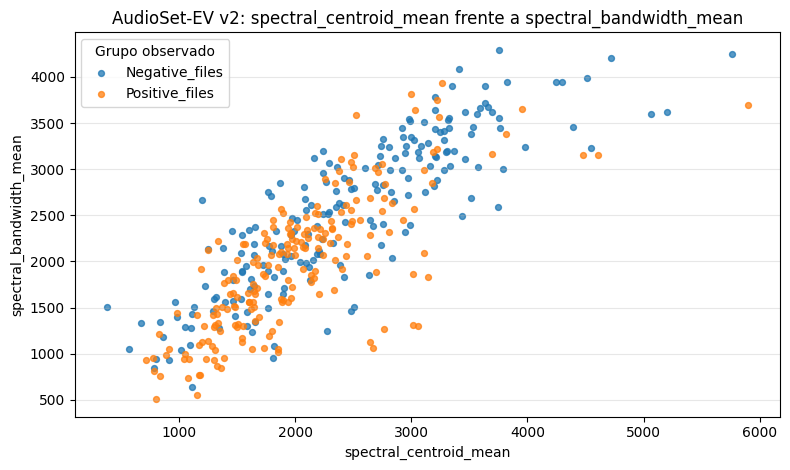

gráfico: /kaggle/working/dataset_eda/plots/scatter_centroid_bandwidth_audioset_ev.png


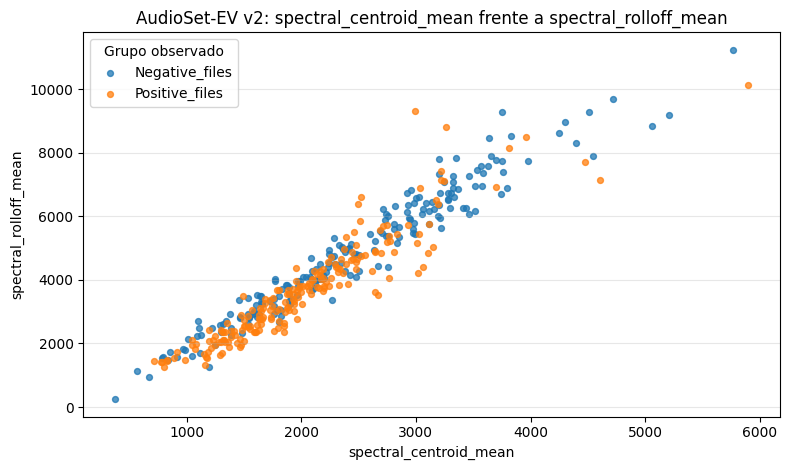

gráfico: /kaggle/working/dataset_eda/plots/scatter_centroid_rolloff_audioset_ev.png


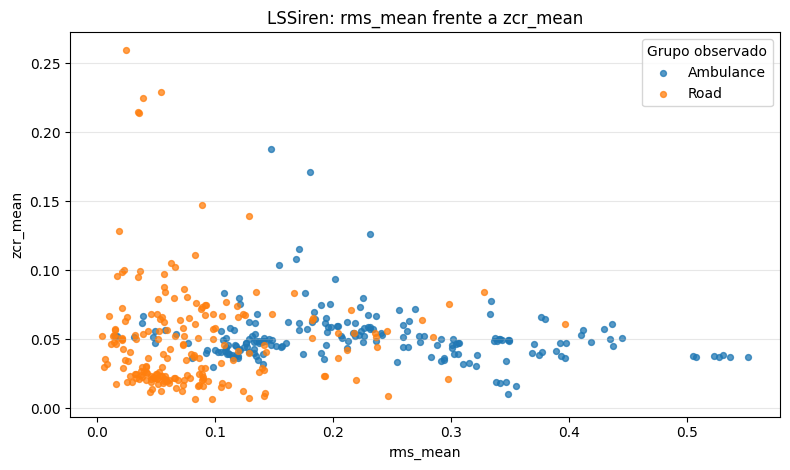

gráfico: /kaggle/working/dataset_eda/plots/scatter_rms_zcr_lssiren.png


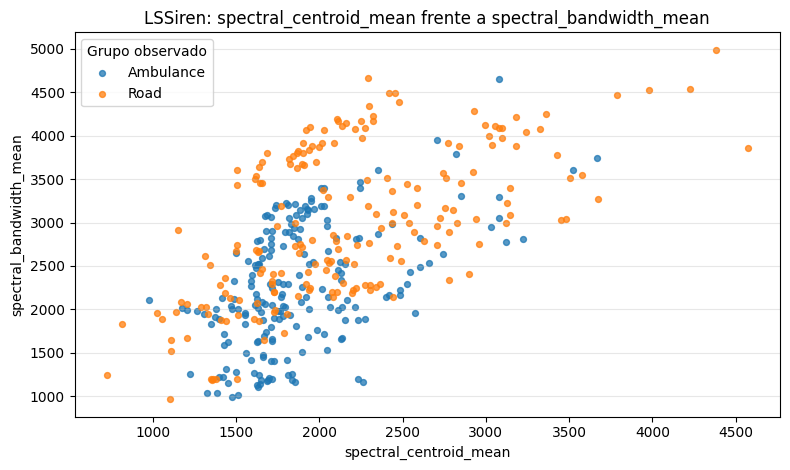

gráfico: /kaggle/working/dataset_eda/plots/scatter_centroid_bandwidth_lssiren.png


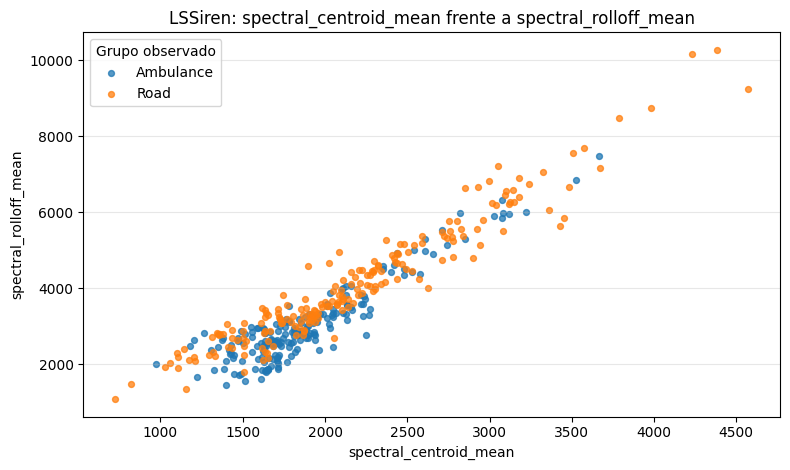

gráfico: /kaggle/working/dataset_eda/plots/scatter_centroid_rolloff_lssiren.png


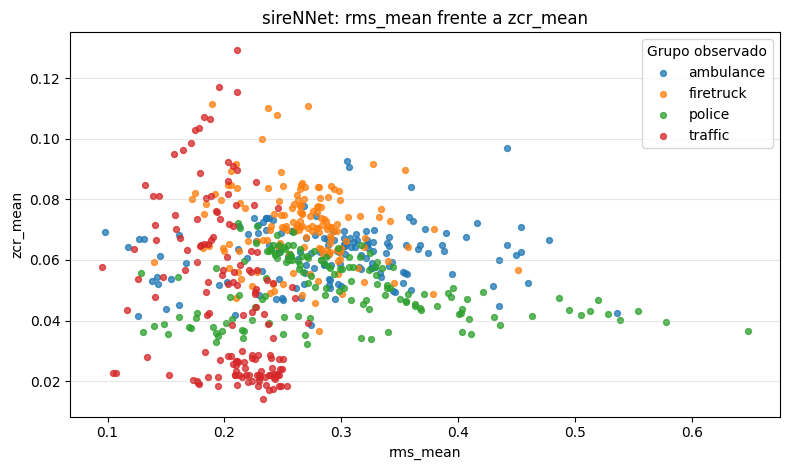

gráfico: /kaggle/working/dataset_eda/plots/scatter_rms_zcr_sirennet.png


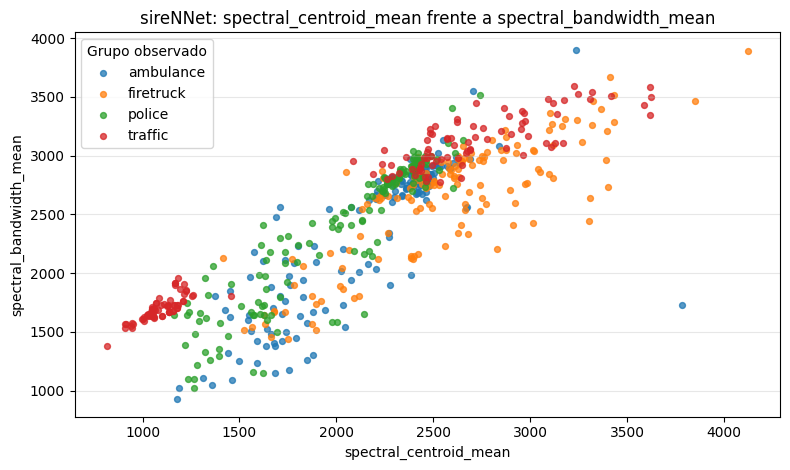

gráfico: /kaggle/working/dataset_eda/plots/scatter_centroid_bandwidth_sirennet.png


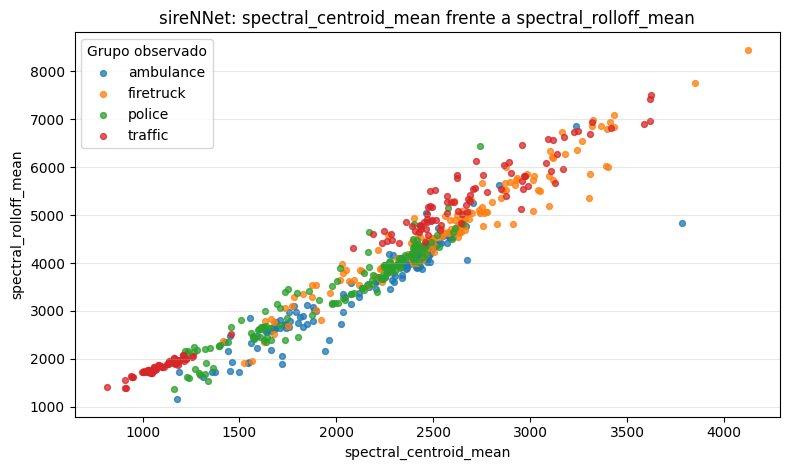

gráfico: /kaggle/working/dataset_eda/plots/scatter_centroid_rolloff_sirennet.png
escrito: /kaggle/working/dataset_eda/feature_correlation_matrix.csv
escrito: /kaggle/working/dataset_eda/feature_correlation_spearman.csv


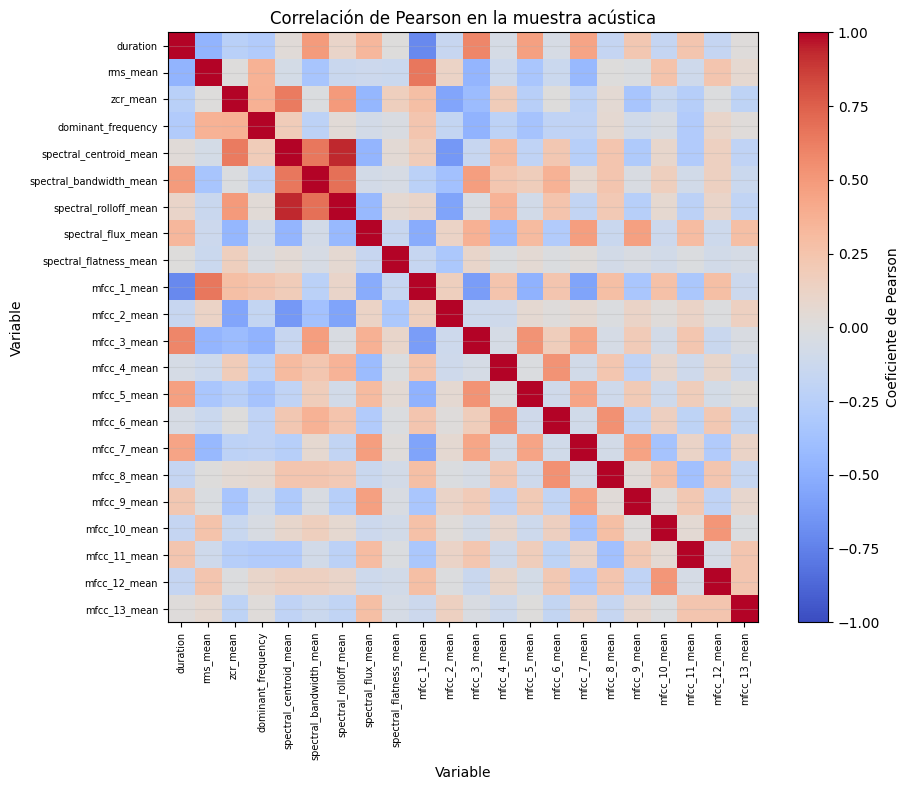

gráfico: /kaggle/working/dataset_eda/plots/correlation_pearson.png
escrito: /kaggle/working/dataset_eda/eda_anomalies.csv
Filas de anomalías exploratorias: 817. No se eliminó ningún archivo.


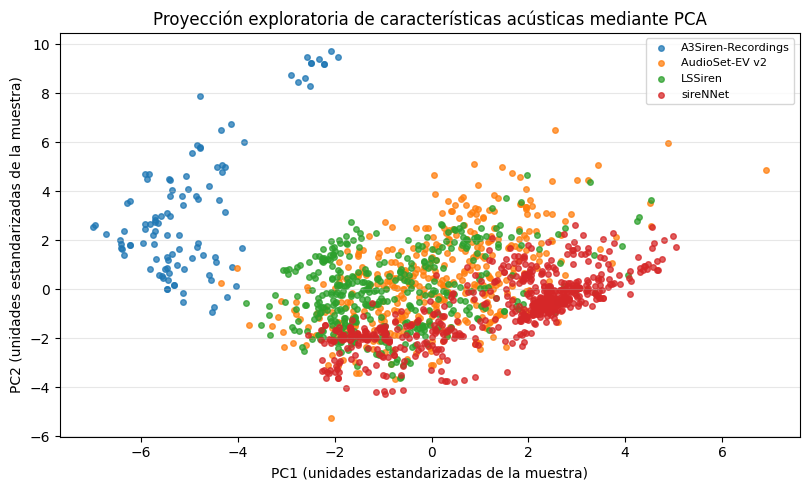

gráfico: /kaggle/working/dataset_eda/plots/pca_exploratory.png
La estandarización se aplicó solo a esta copia de visualización. No es un pipeline de producción.


In [27]:
def section_patterns() -> None:
    features = ensure_features()
    for dataset, group in features.groupby("dataset"):
        slug = group["dataset_id"].iloc[0]
        for left, right, name in (
            ("rms_mean", "zcr_mean", "rms_zcr"),
            ("spectral_centroid_mean", "spectral_bandwidth_mean", "centroid_bandwidth"),
            ("spectral_centroid_mean", "spectral_rolloff_mean", "centroid_rolloff"),
        ):
            fig, ax = plt.subplots(figsize=(8, 4.8))
            for label, subgroup in group.groupby("analysis_group"):
                ax.scatter(pd.to_numeric(subgroup[left], errors="coerce"), pd.to_numeric(subgroup[right], errors="coerce"), s=18, alpha=0.75, label=str(label))
            style_ax(ax, f"{dataset}: {left} frente a {right}", left, right)
            ax.legend(title="Grupo observado")
            save_figure(fig, f"scatter_{name}_{slug}.png")
    pearson, spearman = correlation_matrix(features)
    export_table(pearson.reset_index().rename(columns={"index": "feature"}), "feature_correlation_matrix.csv")
    export_table(spearman.reset_index().rename(columns={"index": "feature"}), "feature_correlation_spearman.csv")
    fig, ax = plt.subplots(figsize=(10, 8))
    image = ax.imshow(pearson.values, cmap="coolwarm", vmin=-1, vmax=1)
    ax.set_xticks(range(len(pearson.columns)))
    ax.set_yticks(range(len(pearson.columns)))
    ax.set_xticklabels(pearson.columns, rotation=90, fontsize=7)
    ax.set_yticklabels(pearson.columns, fontsize=7)
    style_ax(ax, "Correlación de Pearson en la muestra acústica", "Variable", "Variable")
    fig.colorbar(image, ax=ax, label="Coeficiente de Pearson")
    save_figure(fig, "correlation_pearson.png")
    anomalies = iqr_anomalies(features)
    export_table(anomalies, "eda_anomalies.csv")
    print(f"Filas de anomalías exploratorias: {len(anomalies)}. No se eliminó ningún archivo.")
    matrix = features[FEATURE_COLUMNS].apply(pd.to_numeric, errors="coerce")
    usable = matrix.dropna()
    usable = usable.loc[:, usable.std(ddof=0) > 0]
    if len(usable) >= 5 and usable.shape[1] >= 2:
        scaled = StandardScaler().fit_transform(usable)
        projection = PCA(n_components=2, random_state=SEED).fit_transform(scaled)
        projected = features.loc[usable.index, ["dataset", "analysis_group"]].copy()
        projected["pc1"] = projection[:, 0]
        projected["pc2"] = projection[:, 1]
        fig, ax = plt.subplots(figsize=(8.2, 5))
        for dataset, group in projected.groupby("dataset"):
            ax.scatter(group["pc1"], group["pc2"], s=16, alpha=0.75, label=dataset)
        style_ax(ax, "Proyección exploratoria de características acústicas mediante PCA", "PC1 (unidades estandarizadas de la muestra)", "PC2 (unidades estandarizadas de la muestra)")
        ax.legend(fontsize=8)
        save_figure(fig, "pca_exploratory.png")
        print("La estandarización se aplicó solo a esta copia de visualización. No es un pipeline de producción.")

section_patterns()


## 18. Variables que justifican un análisis posterior

La variación intraclase y entre grupos observados se registra para decidir qué revisar en la preparación. No es una puntuación de importancia.


In [28]:
def section_relevance() -> None:
    features = ensure_features()
    relevance = variation_table(features)
    export_table(relevance, "feature_relevance_observations.csv")
    show_df(relevance, n=20)
    print("Relevante significa que justifica un análisis posterior. No significa que entrará al modelo.")

section_relevance()


escrito: /kaggle/working/dataset_eda/feature_relevance_observations.csv
filas: 21 | columnas: 8


,feature,domain,mean_variation,within_class_variation,between_class_variation,datasets_present,observation,potential_relevance
0,rms_mean,Amplitud,0.079693,0.068999,0.042270,A3Siren-Recordings | AudioSet-EV v2 | LSSiren ...,presenta variación descriptiva que justifica r...,revisar en preparación
1,zcr_mean,Temporal,0.025243,0.023865,0.006363,A3Siren-Recordings | AudioSet-EV v2 | LSSiren ...,presenta variación descriptiva que justifica r...,revisar en preparación
2,dominant_frequency,Frecuencial,440.643911,372.728959,354.696854,A3Siren-Recordings | AudioSet-EV v2 | LSSiren ...,presenta variación descriptiva que justifica r...,revisar en preparación
3,spectral_centroid_mean,Frecuencial,854.493500,830.728784,227.409436,A3Siren-Recordings | AudioSet-EV v2 | LSSiren ...,presenta variación descriptiva que justifica r...,revisar en preparación
4,spectral_bandwidth_mean,Frecuencial,963.292813,935.308805,426.956103,A3Siren-Recordings | AudioSet-EV v2 | LSSiren ...,presenta variación descriptiva que justifica r...,revisar en preparación
5,spectral_rolloff_mean,Frecuencial,2416.057161,2368.562720,532.086732,A3Siren-Recordings | AudioSet-EV v2 | LSSiren ...,presenta variación descriptiva que justifica r...,revisar en preparación
6,spectral_flux_mean,Frecuencial,0.017346,0.015426,0.008769,A3Siren-Recordings | AudioSet-EV v2 | LSSiren ...,presenta variación descriptiva que justifica r...,revisar en preparación
7,spectral_flatness_mean,Frecuencial,0.027578,0.024210,0.001046,A3Siren-Recordings | AudioSet-EV v2 | LSSiren ...,presenta variación descriptiva que justifica r...,revisar en preparación
8,mfcc_1_mean,Cepstral,59.085932,57.696969,22.933170,A3Siren-Recordings | AudioSet-EV v2 | LSSiren ...,presenta variación descriptiva que justifica r...,revisar en preparación
9,mfcc_2_mean,Cepstral,25.242491,24.873415,4.918665,A3Siren-Recordings | AudioSet-EV v2 | LSSiren ...,presenta variación descriptiva que justifica r...,revisar en preparación


Relevante significa que justifica un análisis posterior. No significa que entrará al modelo.


## 19. Resumen de hallazgos

Cada hallazgo separa la observación, la evidencia y la interpretación. La confianza es descriptiva, no la de un clasificador.


In [29]:
def section_findings() -> None:
    features = ensure_features()
    inventory = STATE["inventory"]
    findings = []

    def add(dataset, observation, evidence, metric, interpretation, implication, confidence):
        findings.append({
            "finding_id": f"F{len(findings)+1:02d}",
            "dataset": dataset,
            "observation": observation,
            "evidence": evidence,
            "metric_or_plot": metric,
            "interpretation": interpretation,
            "implication_for_chapter_4": implication,
            "confidence": confidence,
        })

    audioset_rates = inventory.loc[inventory["dataset_id"] == "audioset_ev", "sampling_rate_hz"].nunique(dropna=True)
    lssiren_rates = sorted(pd.to_numeric(inventory.loc[inventory["dataset_id"] == "lssiren", "sampling_rate_hz"], errors="coerce").dropna().astype(int).unique())
    add("LSSiren", "LSSiren presenta heterogeneidad de sampling rate.", f"{len(lssiren_rates)} valores observados: {lssiren_rates}.", "sampling_rate_lssiren.png", "Las tasas no describen la misma banda de Nyquist.", "Será necesario evaluar la estrategia de armonización en la preparación.", "HIGH")
    channels = inventory.loc[inventory["dataset_id"] == "lssiren", "channels"].nunique(dropna=True)
    add("LSSiren", "LSSiren presenta archivos mono y estéreo.", f"{int(channels)} valores de canales en la cabecera.", "channels_lssiren.png", "La mezcla en memoria de esta notebook no queda guardada.", "Habrá que decidir el tratamiento de canales en la preparación.", "HIGH")
    add("AudioSet-EV v2", "AudioSet-EV v2 concentra una sola tasa y un solo número de canales en los archivos utilizables.", f"sampling rates distintos = {int(audioset_rates)}.", "sampling_rate_audioset_ev.png", "La homogeneidad técnica no dice nada sobre la homogeneidad acústica de las cadenas de etiquetas.", "La preparación puede tratar la tasa como constante dentro de este corpus, sin generalizarla a los demás.", "HIGH")
    add("A3Siren-Recordings", "A3Siren reparte cada toma en ocho WAV mono.", f"tracks = {inventory.loc[inventory['dataset_id']=='a3siren','track_id'].nunique()}; canales = {inventory.loc[inventory['dataset_id']=='a3siren','relative_path'].map(lambda path: a3_channel(path, Path(path).name)).nunique()}.", "a3siren_track_statistics.csv", "Los ocho canales no son ocho observaciones independientes.", "Cualquier partición futura debe usar el track como unidad.", "HIGH")
    for dataset in features["dataset"].unique():
        group = features[features["dataset"] == dataset]
        if dataset == "A3Siren-Recordings":
            group = group.groupby(["track_id", "analysis_group"], as_index=False)[["rms_mean", "zcr_mean"]].median(numeric_only=True)
            group["dataset_id"] = "a3siren"
        labels = [label for label in group["analysis_group"].dropna().unique()]
        if len(labels) < 2:
            continue
        prefix = "la mediana por track del" if dataset == "A3Siren-Recordings" else "el"
        phrase, confidence = distribution_phrase(group.loc[group["analysis_group"] == labels[0], "rms_mean"], group.loc[group["analysis_group"] == labels[1], "rms_mean"])
        add(dataset, f"En {dataset}, {prefix} RMS de {labels[0]} y {labels[1]} muestra: {phrase}.", "amplitude_energy_statistics.csv", f"rms_{group['dataset_id'].iloc[0]}.png", phrase, "Revisar RMS en la preparación como descriptor descriptivo, no como regla de clasificación.", confidence)
        phrase, confidence = distribution_phrase(group.loc[group["analysis_group"] == labels[0], "zcr_mean"], group.loc[group["analysis_group"] == labels[1], "zcr_mean"])
        add(dataset, f"En {dataset}, {prefix} ZCR de {labels[0]} y {labels[1]} muestra: {phrase}.", "zcr_statistics.csv", f"zcr_{group['dataset_id'].iloc[0]}.png", phrase, "Revisar ZCR junto con la tasa de muestreo antes de compararlo entre corpus.", confidence)
    if not features[features["dataset"] == "sireNNet"].empty:
        siren = features[features["dataset"] == "sireNNet"]
        classes = sorted(siren["analysis_group"].unique())
        notes = []
        for left_index, left in enumerate(classes):
            for right in classes[left_index + 1:]:
                phrase, _confidence = distribution_phrase(siren.loc[siren["analysis_group"] == left, "spectral_centroid_mean"], siren.loc[siren["analysis_group"] == right, "spectral_centroid_mean"])
                notes.append(f"{left} frente a {right}: {phrase}")
        add("sireNNet", "En sireNNet se compararon las cuatro carpetas en el centroide espectral de la muestra.", " | ".join(notes), "sirennet_class_statistics.csv", "En este dataset se observan diferencias descriptivas o solapamiento según el par de carpetas; no se declara separabilidad universal.", "El capítulo de preparación puede conservar las cuatro carpetas como etiquetas de este corpus.", "MEDIUM")
    finding_frame = pd.DataFrame(findings)
    STATE["findings"] = finding_frame
    export_table(finding_frame, "initial_findings.csv")
    export_table(finding_frame[["dataset", "observation", "evidence", "implication_for_chapter_4"]].rename(columns={"observation": "Hallazgo", "evidence": "Evidencia", "implication_for_chapter_4": "Impacto esperado en preparación"}), "tabla_3_7_hallazgos.csv")
    show_df(finding_frame, n=20)

section_findings()


escrito: /kaggle/working/dataset_eda/initial_findings.csv
escrito: /kaggle/working/dataset_eda/tabla_3_7_hallazgos.csv
filas: 13 | columnas: 8


,finding_id,dataset,observation,evidence,metric_or_plot,interpretation,implication_for_chapter_4,confidence
0,F01,LSSiren,LSSiren presenta heterogeneidad de sampling rate.,"5 valores observados: [np.int64(8000), np.int6...",sampling_rate_lssiren.png,Las tasas no describen la misma banda de Nyquist.,Será necesario evaluar la estrategia de armoni...,HIGH
1,F02,LSSiren,LSSiren presenta archivos mono y estéreo.,2 valores de canales en la cabecera.,channels_lssiren.png,La mezcla en memoria de esta notebook no queda...,Habrá que decidir el tratamiento de canales en...,HIGH
2,F03,AudioSet-EV v2,AudioSet-EV v2 concentra una sola tasa y un so...,sampling rates distintos = 1.,sampling_rate_audioset_ev.png,La homogeneidad técnica no dice nada sobre la ...,La preparación puede tratar la tasa como const...,HIGH
3,F04,A3Siren-Recordings,A3Siren reparte cada toma en ocho WAV mono.,tracks = 13; canales = 8.,a3siren_track_statistics.csv,Los ocho canales no son ocho observaciones ind...,Cualquier partición futura debe usar el track ...,HIGH
4,F05,A3Siren-Recordings,"En A3Siren-Recordings, la mediana por track de...",amplitude_energy_statistics.csv,rms_a3siren.png,se observa una diferencia con solapamiento,Revisar RMS en la preparación como descriptor ...,MEDIUM
5,F06,A3Siren-Recordings,"En A3Siren-Recordings, la mediana por track de...",zcr_statistics.csv,zcr_a3siren.png,se observa una diferencia con solapamiento,Revisar ZCR junto con la tasa de muestreo ante...,MEDIUM
6,F07,AudioSet-EV v2,"En AudioSet-EV v2, el RMS de Negative_files y ...",amplitude_energy_statistics.csv,rms_audioset_ev.png,se observa una diferencia con solapamiento,Revisar RMS en la preparación como descriptor ...,MEDIUM
7,F08,AudioSet-EV v2,"En AudioSet-EV v2, el ZCR de Negative_files y ...",zcr_statistics.csv,zcr_audioset_ev.png,se observa una diferencia con solapamiento,Revisar ZCR junto con la tasa de muestreo ante...,MEDIUM
8,F09,LSSiren,"En LSSiren, el RMS de Ambulance y Road muestra...",amplitude_energy_statistics.csv,rms_lssiren.png,las distribuciones se observan parcialmente di...,Revisar RMS en la preparación como descriptor ...,MEDIUM
9,F10,LSSiren,"En LSSiren, el ZCR de Ambulance y Road muestra...",zcr_statistics.csv,zcr_lssiren.png,se observa una diferencia con solapamiento,Revisar ZCR junto con la tasa de muestreo ante...,MEDIUM


## 20. Implicaciones para el Capítulo 4

Cada línea es un hallazgo seguido de una posible acción posterior. Ninguna de esas acciones se ejecuta en esta notebook.


In [30]:
def section_implications() -> None:
    findings = STATE["findings"]
    print("Implicaciones para la Preparación de Datos")
    print("Cada línea es HALLAZGO → POSIBLE ACCIÓN POSTERIOR. Ninguna se ejecuta aquí.")
    for record in findings.itertuples(index=False):
        print(f"- {record.observation} → {record.implication_for_chapter_4}")
    print("- Archivos de duración cero → valorar su exclusión solo en la preparación, sin borrarlos del input.")
    print("- Copias de un mismo hash → mantenerlas del mismo lado si más adelante se construye una partición.")
    print("- Tasas distintas en LSSiren → valorar una armonización de sampling rate en la preparación.")
    print("- Estéreo y mono → valorar el tratamiento de canales en la preparación, sin convertirlos aquí.")
    print("- Duraciones distintas → valorar segmentación o ventaneo en la preparación.")
    print("- A3Siren → cualquier partición futura debe usar el track como unidad.")
    print("- Log-Mel y MFCC → siguen siendo candidatos visuales y descriptivos, no una decisión de modelo.")

section_implications()


Implicaciones para la Preparación de Datos
Cada línea es HALLAZGO → POSIBLE ACCIÓN POSTERIOR. Ninguna se ejecuta aquí.
- LSSiren presenta heterogeneidad de sampling rate. → Será necesario evaluar la estrategia de armonización en la preparación.
- LSSiren presenta archivos mono y estéreo. → Habrá que decidir el tratamiento de canales en la preparación.
- AudioSet-EV v2 concentra una sola tasa y un solo número de canales en los archivos utilizables. → La preparación puede tratar la tasa como constante dentro de este corpus, sin generalizarla a los demás.
- A3Siren reparte cada toma en ocho WAV mono. → Cualquier partición futura debe usar el track como unidad.
- En A3Siren-Recordings, la mediana por track del RMS de Noise y Siren muestra: se observa una diferencia con solapamiento. → Revisar RMS en la preparación como descriptor descriptivo, no como regla de clasificación.
- En A3Siren-Recordings, la mediana por track del ZCR de Noise y Siren muestra: se observa una diferencia con solapam

## 21. Exportación de resultados

Figuras y tablas candidatas para la tesis, más los parámetros de esta corrida.


In [31]:
def section_export() -> None:
    figures = pd.DataFrame([
        {"figure_id": "FIGURA 3.1", "title": "Distribución de muestras por dataset y clase", "file": "plots/thesis/fig_3_1_distribucion_muestras.png", "mark": "CANDIDATO PARA TESIS"},
        {"figure_id": "FIGURA 3.2", "title": "Distribución de duración de las señales acústicas", "file": "plots/thesis/fig_3_2_duracion.png", "mark": "CANDIDATO PARA TESIS"},
        {"figure_id": "FIGURA 3.3", "title": "Heterogeneidad de frecuencias de muestreo entre datasets", "file": "plots/thesis/fig_3_3_sampling_rate.png", "mark": "CANDIDATO PARA TESIS"},
        {"figure_id": "FIGURA 3.4", "title": "Distribución de energía RMS por clase", "file": "plots/thesis/fig_3_4_rms.png", "mark": "CANDIDATO PARA TESIS"},
        {"figure_id": "FIGURA 3.5", "title": "Características espectrales de sirena y ruido", "file": "plots/thesis/fig_3_5_centroid.png", "mark": "CANDIDATO PARA TESIS"},
        {"figure_id": "FIGURA 3.6", "title": "Representaciones tiempo-frecuencia de las señales analizadas", "file": "plots/thesis/fig_3_6_espectrograma.png", "mark": "CANDIDATO PARA TESIS"},
        {"figure_id": "FIGURA 3.7", "title": "Comparación acústica de las clases de sireNNet", "file": "plots/thesis/fig_3_7_sirennet.png", "mark": "CANDIDATO PARA TESIS"},
        {"figure_id": "FIGURA 3.8", "title": "Variabilidad entre canales de A3Siren-Recordings", "file": "plots/thesis/fig_3_8_a3_canales.png", "mark": "CANDIDATO PARA TESIS"},
        {"figure_id": "FIGURA 3.9", "title": "Comparación de características acústicas entre datasets", "file": "plots/thesis/fig_3_9_comparacion_datasets.png", "mark": "CANDIDATO PARA TESIS"},
    ])
    tables = pd.DataFrame([
        {"table_id": "TABLA 3.1", "file": "tabla_3_1_resumen_estructural.csv"},
        {"table_id": "TABLA 3.2", "file": "tabla_3_2_duracion.csv"},
        {"table_id": "TABLA 3.3", "file": "tabla_3_3_temporales.csv"},
        {"table_id": "TABLA 3.4", "file": "tabla_3_4_frecuenciales.csv"},
        {"table_id": "TABLA 3.5", "file": "tabla_3_5_por_clase.csv"},
        {"table_id": "TABLA 3.6", "file": "tabla_3_6_variabilidad_datasets.csv"},
        {"table_id": "TABLA 3.7", "file": "tabla_3_7_hallazgos.csv"},
    ])
    export_table(figures, "thesis_candidate_figures.csv")
    export_table(tables, "thesis_candidate_tables.csv")
    parameters = {
        "seed": SEED,
        "n_fft": N_FFT,
        "hop_length": HOP_LENGTH,
        "win_length": WIN_LENGTH,
        "window": WINDOW,
        "n_mels": N_MELS,
        "n_mfcc": N_MFCC,
        "fmin_hz": FMIN,
        "fmax": "Nyquist de cada archivo",
        "rolloff_percent": ROLLOFF_PERCENT,
        "spectral_flux": "media de la norma L2 de la diferencia entre espectros de magnitud normalizados por la suma del frame",
        "dominant_frequency": "bin de mayor magnitud media del STFT, excluida la componente DC",
        "stereo_policy": "promedio en memoria; el archivo no se modifica",
        "sample_targets": SAMPLE_TARGETS,
    }
    (OUTPUT_ROOT / "data" / "eda_parameters.json").write_text(json.dumps(parameters, ensure_ascii=False, indent=2), encoding="utf-8")
    print(f"escrito: {OUTPUT_ROOT / 'data' / 'eda_parameters.json'}")

section_export()


escrito: /kaggle/working/dataset_eda/thesis_candidate_figures.csv
escrito: /kaggle/working/dataset_eda/thesis_candidate_tables.csv
escrito: /kaggle/working/dataset_eda/data/eda_parameters.json


## 22. Informe final del EDA

El informe separa evidencia, interpretación e implicación. No responde qué modelo funciona ni cuál dataset conviene usar.


In [32]:
def section_report() -> None:
    finding_frame = STATE["findings"]
    report = render_report(finding_frame)
    report_path = OUTPUT_ROOT / "reports" / "final_eda_report.md"
    report_path.write_text(report, encoding="utf-8")
    print(f"escrito: {report_path}")
    sample = STATE["sample"]
    manifest = STATE["manifest"]
    missing = [path for path in manifest["file_path"] if not Path(path).exists()]
    invalid = int((sample["quality_status"] != "OK").sum())
    secondary = sample[(sample["dataset_id"] != "a3siren") & (~sample["is_hash_primary"])]
    a3_without_track = sample[(sample["dataset_id"] == "a3siren") & (sample["track_id"].astype(str) == "")]
    checks = {
        "manifest_exists": (OUTPUT_ROOT / "eda_sample_manifest.csv").exists(),
        "features_exist": (OUTPUT_ROOT / "eda_feature_sample.csv").exists(),
        "report_exists": report_path.exists(),
        "missing_files": missing,
        "invalid_in_sample": invalid,
        "secondary_duplicates_in_sample": int(len(secondary)),
        "a3_without_track_id": int(len(a3_without_track)),
        "seed": SEED,
    }
    print(json.dumps({key: value for key, value in checks.items() if key != "missing_files"}, ensure_ascii=False))
    if missing or invalid or len(secondary) or len(a3_without_track) or not checks["report_exists"]:
        raise AssertionError(f"Validación del EDA incompleta: {checks}")

    def count(dataset, group):
        return int(((sample["dataset"] == dataset) & (sample["analysis_group"] == group)).sum())

    figures_n = len(list((OUTPUT_ROOT / "plots").rglob("*.png")))
    tables_n = len(list(OUTPUT_ROOT.glob("*.csv")))
    print("=============================================")
    print("NOTEBOOK 01 — EDA COMPLETED")
    print("=============================================")
    print("Datasets analyzed:")
    print("4")
    print()
    print("AudioSet-EV:")
    print("Positive samples analyzed:")
    print(count("AudioSet-EV v2", "Positive_files"))
    print("Negative samples analyzed:")
    print(count("AudioSet-EV v2", "Negative_files"))
    print()
    print("LSSiren:")
    print("Ambulance samples analyzed:")
    print(count("LSSiren", "Ambulance"))
    print("Road samples analyzed:")
    print(count("LSSiren", "Road"))
    print()
    print("sireNNet:")
    print("Ambulance:")
    print(count("sireNNet", "ambulance"))
    print("Firetruck:")
    print(count("sireNNet", "firetruck"))
    print("Police:")
    print(count("sireNNet", "police"))
    print("Traffic:")
    print(count("sireNNet", "traffic"))
    print()
    print("A3Siren:")
    print("Tracks:")
    print(int(sample.loc[sample["dataset_id"] == "a3siren", "track_id"].nunique()))
    print("Channels per track:")
    print(int(sample.loc[sample["dataset_id"] == "a3siren", "relative_path"].map(lambda path: a3_channel(path, Path(path).name)).nunique()))
    print()
    print("Acoustic features analyzed:")
    for name in ("RMS", "ZCR", "Dominant Frequency", "Spectral Centroid", "Spectral Bandwidth", "Spectral Roll-off", "Spectral Flux", "Spectral Flatness", "MFCC"):
        print(name)
    print()
    print("Figures generated:")
    print(figures_n)
    print()
    print("Tables generated:")
    print(tables_n)
    print()
    print("Initial findings:")
    print(len(finding_frame))
    print("=============================================")

section_report()


escrito: /kaggle/working/dataset_eda/reports/final_eda_report.md
{"manifest_exists": true, "features_exist": true, "report_exists": true, "invalid_in_sample": 0, "secondary_duplicates_in_sample": 0, "a3_without_track_id": 0, "seed": 42}
NOTEBOOK 01 — EDA COMPLETED
Datasets analyzed:
4

AudioSet-EV:
Positive samples analyzed:
200
Negative samples analyzed:
200

LSSiren:
Ambulance samples analyzed:
200
Road samples analyzed:
200

sireNNet:
Ambulance:
150
Firetruck:
150
Police:
150
Traffic:
150

A3Siren:
Tracks:
13
Channels per track:
8

Acoustic features analyzed:
RMS
ZCR
Dominant Frequency
Spectral Centroid
Spectral Bandwidth
Spectral Roll-off
Spectral Flux
Spectral Flatness
MFCC

Figures generated:
135

Tables generated:
36

Initial findings:
13
